# AlgoJam 3 — Round 1 research

This notebook turns each clue in the instrument specification into a quantitative, falsifiable hypothesis. It is exploratory: Round 1 results help us choose robust strategy families, but they are not evidence that an exact threshold will repeat in unseen Round 2.

**Timing convention:** a position selected using information through day `t` earns `position[t] * (price[t+1] - price[t])`, matching the supplied simulator.

In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "trader_interface" / "data").exists()
)
DATA_DIR = ROOT / "trader_interface" / "data"

POSITION_LIMITS = {
    "Fintech Token": 100, "UQ Dollar": 650, "Thrifted Jeans": 800,
    "Sausage Sizzle": 3000, "Bread": 500, "MenuDash": 75000,
    "Sausage": 5000, "Liferaft Ticket": 1, "Boat Party Ticket": 1000,
}
BUDGET = 600_000

series = {}
for path in sorted(DATA_DIR.glob("*_price_history.csv")):
    name = path.name.removesuffix("_price_history.csv")
    frame = pd.read_csv(path)
    series[name] = frame.set_index("Day")["Price"].astype(float)
prices = pd.DataFrame(series).sort_index()
print(f"Loaded {prices.shape[1]} instruments and {prices.shape[0]} days from {DATA_DIR}")
prices.head()

Loaded 9 instruments and 365 days from D:\Documents\Algojam\trader_interface\data


,Boat Party Ticket,Bread,Fintech Token,Liferaft Ticket,MenuDash,Sausage Sizzle,Sausage,Thrifted Jeans,UQ Dollar
Day,,,,,,,,,
0,45.000,121.750,803.000,"100,000.000",1.800,35.220,4.720,40.000,100.000
1,44.690,120.750,818.620,"95,000.000",1.770,35.220,4.710,40.470,99.990
2,45.180,119.500,806.120,"90,000.000",1.770,35.170,4.710,39.180,100.050
3,44.440,120.080,813.180,"85,000.000",1.770,35.040,4.740,40.880,99.340
4,45.120,119.000,820.070,"80,000.000",1.780,35.130,4.800,39.120,99.680


## 1. Market overview

Start with scale, drift, volatility, autocorrelation and cross-instrument relationships. Raw-dollar volatility is what drives P&L because limits are expressed in units, while percentage changes are useful for comparing shapes.

In [2]:
def max_drawdown(pnl):
    equity = pd.Series(pnl).fillna(0).cumsum()
    return float((equity - equity.cummax()).min())

def signal_metrics(price, position):
    position = pd.Series(position, index=price.index).fillna(0).astype(int)
    pnl = position * price.diff().shift(-1)
    active = position.ne(0) & pnl.notna()
    sd = pnl.std(ddof=1)
    return {
        "P&L": pnl.sum(),
        "Sharpe": np.sqrt(365) * pnl.mean() / sd if sd > 0 else np.nan,
        "Hit rate": (pnl[active] > 0).mean() if active.any() else np.nan,
        "Active days": int(active.sum()),
        "Max drawdown": max_drawdown(pnl),
    }

overview = pd.DataFrame({
    "Start": prices.iloc[0],
    "End": prices.iloc[-1],
    "Min": prices.min(),
    "Max": prices.max(),
    "Total %": 100 * (prices.iloc[-1] / prices.iloc[0] - 1),
    "Daily $ vol": prices.diff().std(),
    "Δ autocorr(1)": prices.diff().apply(lambda x: x.autocorr(1)),
    "Level autocorr(1)": prices.apply(lambda x: x.autocorr(1)),
})
overview

,Start,End,Min,Max,Total %,Daily $ vol,Δ autocorr(1),Level autocorr(1)
Boat Party Ticket,45.000,44.450,39.580,55.390,-1.222,1.011,-0.168,0.967
Bread,121.750,127.050,111.230,136.970,4.353,0.875,0.064,0.990
Fintech Token,803.000,522.150,409.080,854.340,-34.975,13.265,-0.133,0.996
Liferaft Ticket,"100,000.000","230,000.000","75,000.000","238,000.000",130.000,"6,407.548",0.039,0.984
MenuDash,1.800,1.970,1.700,2.000,9.444,0.019,-0.042,0.968
Sausage Sizzle,35.220,39.880,35.040,39.880,13.231,0.097,0.085,0.997
Sausage,4.720,6.170,4.710,6.180,30.720,0.034,0.091,0.996
Thrifted Jeans,40.000,87.670,26.140,94.780,119.175,2.771,-0.050,0.984
UQ Dollar,100.000,99.880,98.360,101.170,-0.120,0.597,-0.492,0.038


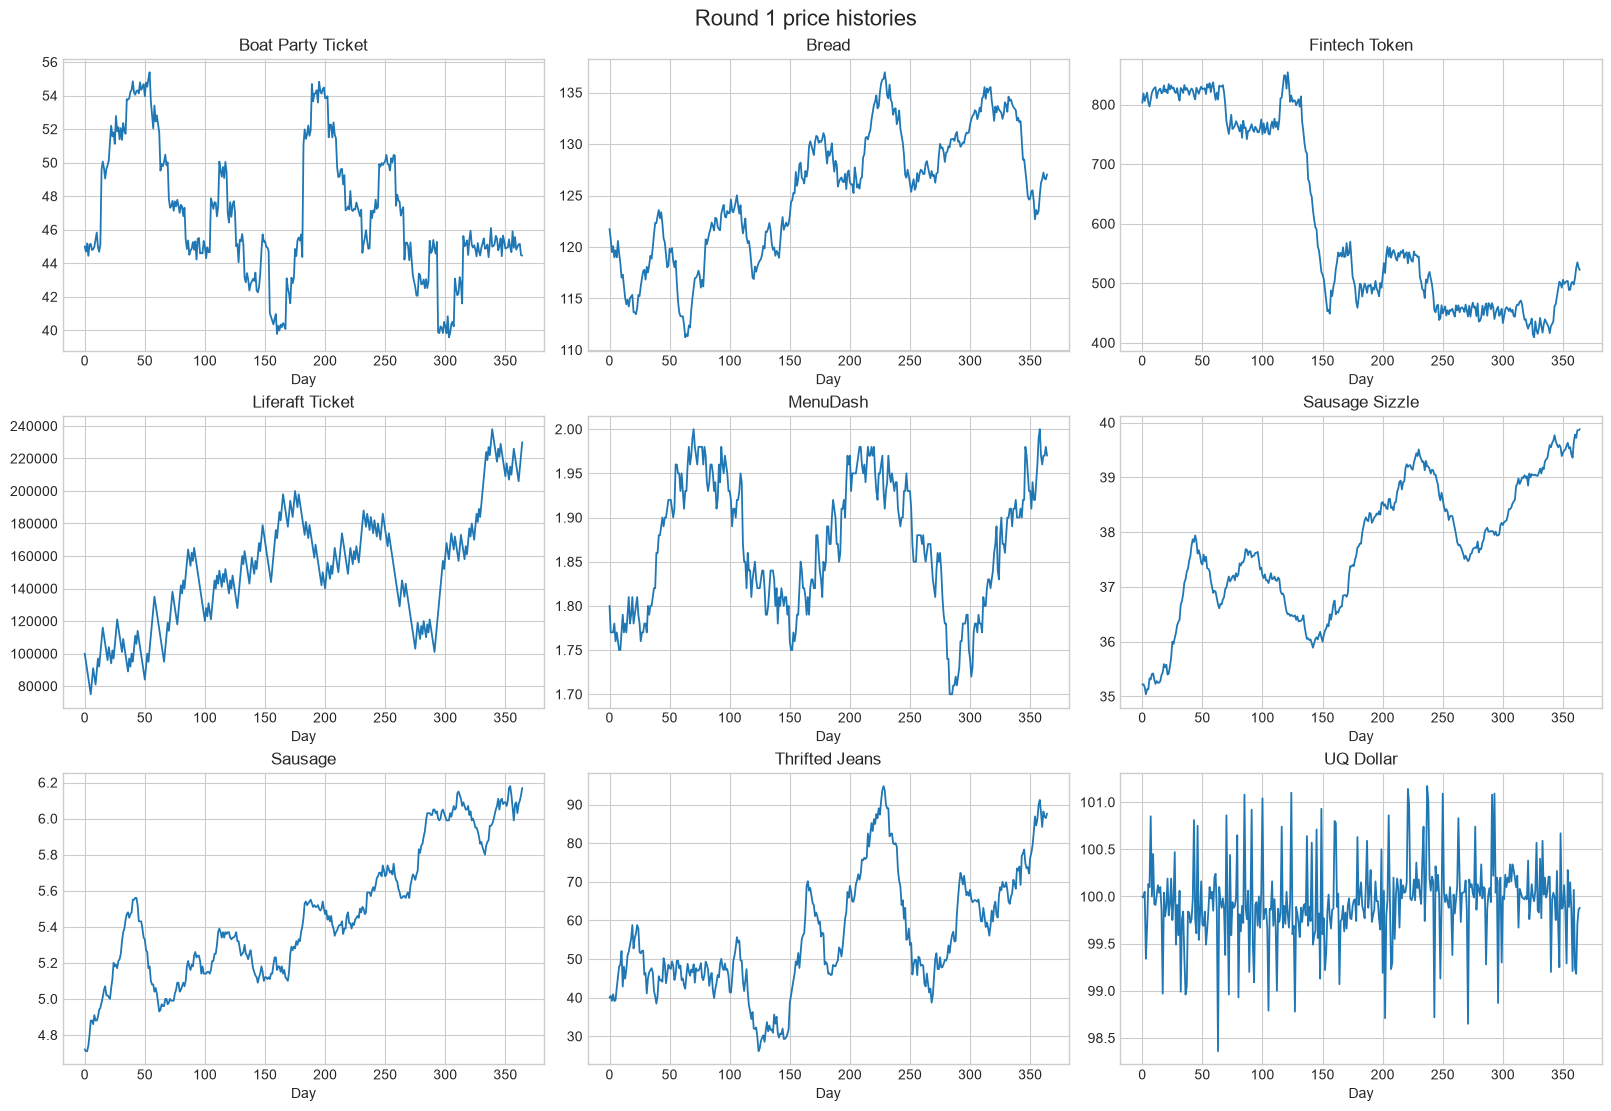

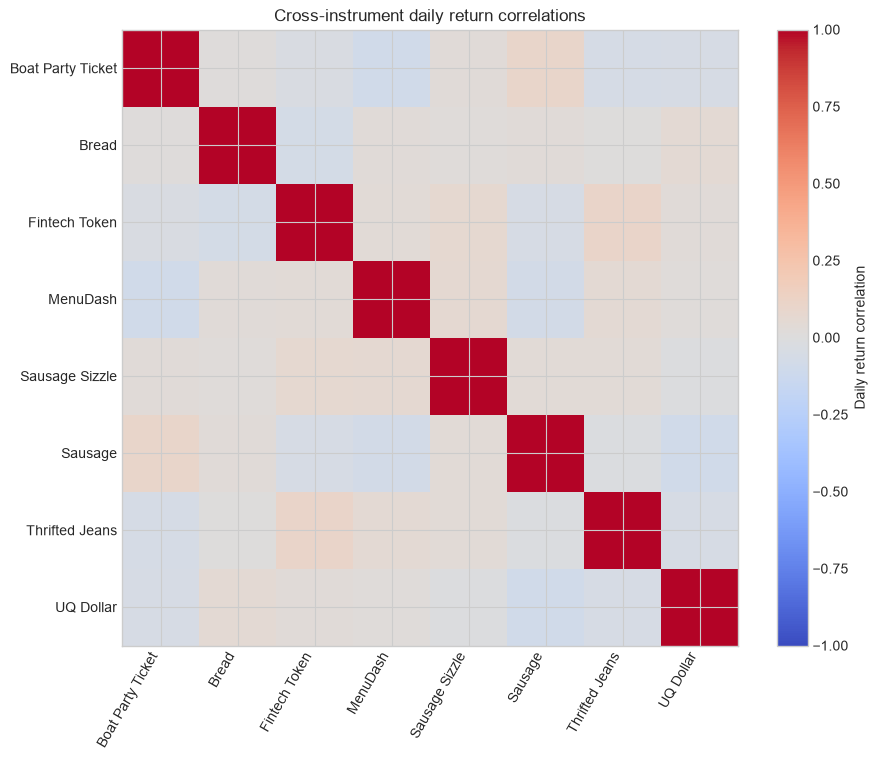

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(16, 11), constrained_layout=True)
for ax, name in zip(axes.flat, prices.columns):
    ax.plot(prices.index, prices[name], lw=1.3)
    ax.set_title(name)
    ax.set_xlabel("Day")
fig.suptitle("Round 1 price histories", fontsize=16)
plt.show()

returns = prices.pct_change(fill_method=None)
fig, ax = plt.subplots(figsize=(10, 8))
corr = returns.drop(columns=["Liferaft Ticket"]).corr()
image = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(corr)), corr.columns, rotation=60, ha="right")
ax.set_yticks(range(len(corr)), corr.index)
fig.colorbar(image, ax=ax, label="Daily return correlation")
ax.set_title("Cross-instrument daily return correlations")
plt.show()

## 2. UQ Dollar — mean reversion around $100

Hypothesis: deviations from the peg predict an opposite future move, especially over one or two days. We test the relationship directly and sweep broad entry thresholds. A robust plateau is more convincing than one winning threshold.

,"corr(deviation, future move)",Mean |future move|
Horizon,,
1,-0.694,0.432
2,-0.699,0.435
3,-0.697,0.418
5,-0.713,0.429
10,-0.715,0.440


,P&L,Sharpe,Hit rate,Active days,Max drawdown
Threshold,,,,,
0.000,"64,551.500",9.880,0.728,356,-968.500
0.050,"60,658.000",9.488,0.764,296,-968.500
0.100,"56,257.500",9.205,0.796,250,-968.500
0.200,"57,304.000",10.460,0.895,171,-591.500
0.300,"47,833.500",9.160,0.939,114,-591.500
0.500,"40,202.500",8.099,0.959,73,-260.000
0.750,"28,086.500",6.503,0.979,47,-39.000
1.000,"14,748.500",4.430,1.000,22,0.000


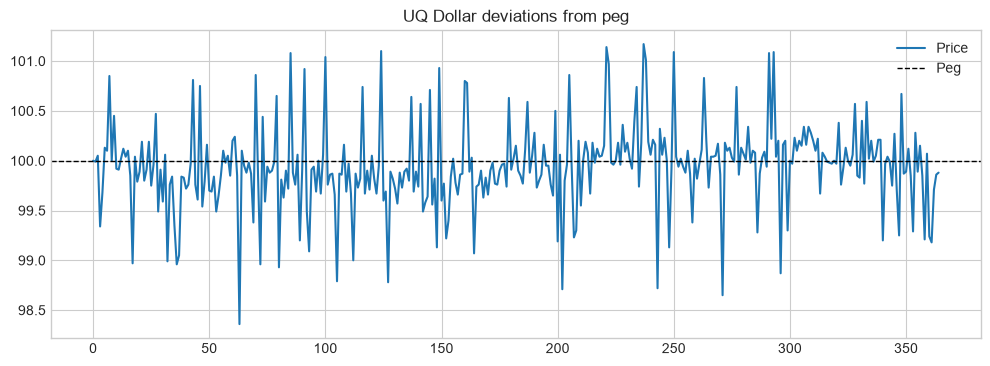

In [4]:
uq = prices["UQ Dollar"]
uq_horizons = []
for horizon in [1, 2, 3, 5, 10]:
    future_move = uq.shift(-horizon) - uq
    uq_horizons.append({
        "Horizon": horizon,
        "corr(deviation, future move)": (uq - 100).corr(future_move),
        "Mean |future move|": future_move.abs().mean(),
    })
display(pd.DataFrame(uq_horizons).set_index("Horizon"))

uq_rows = []
for threshold in [0, 0.05, 0.10, 0.20, 0.30, 0.50, 0.75, 1.00]:
    pos = np.where((uq - 100).abs() >= threshold, -np.sign(uq - 100) * POSITION_LIMITS["UQ Dollar"], 0)
    uq_rows.append({"Threshold": threshold, **signal_metrics(uq, pos)})
uq_results = pd.DataFrame(uq_rows).set_index("Threshold")
display(uq_results)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(uq, label="Price")
ax.axhline(100, color="black", ls="--", lw=1, label="Peg")
ax.set_title("UQ Dollar deviations from peg")
ax.legend()
plt.show()

## 3. Fintech Token — regime switching

Hypothesis: quiet and active periods require different behaviour. This first pass classifies activity using rolling dollar volatility, trades mean reversion to a rolling median in quiet periods, and momentum in active periods. The volatility cutoff below is estimated from Round 1, so it must later be replaced by a trailing/adaptive rule.

,Vol window,Cutoff quantile,P&L,Sharpe,Hit rate,Active days,Max drawdown
5,10,0.800,"66,188.000",2.650,0.563,359,"-17,370.000"
4,10,0.650,"56,366.000",2.251,0.552,359,"-17,370.000"
2,5,0.800,"55,330.000",2.209,0.546,359,"-22,365.000"
8,20,0.800,"55,194.000",2.203,0.560,359,"-15,411.000"
7,20,0.650,"45,162.000",1.799,0.538,359,"-21,031.000"
1,5,0.650,"44,550.000",1.774,0.538,359,"-15,799.000"
6,20,0.500,"36,646.000",1.457,0.526,359,"-18,460.000"
3,10,0.500,"32,754.000",1.302,0.532,359,"-19,674.000"
0,5,0.500,"9,086.000",0.360,0.515,359,"-25,250.000"


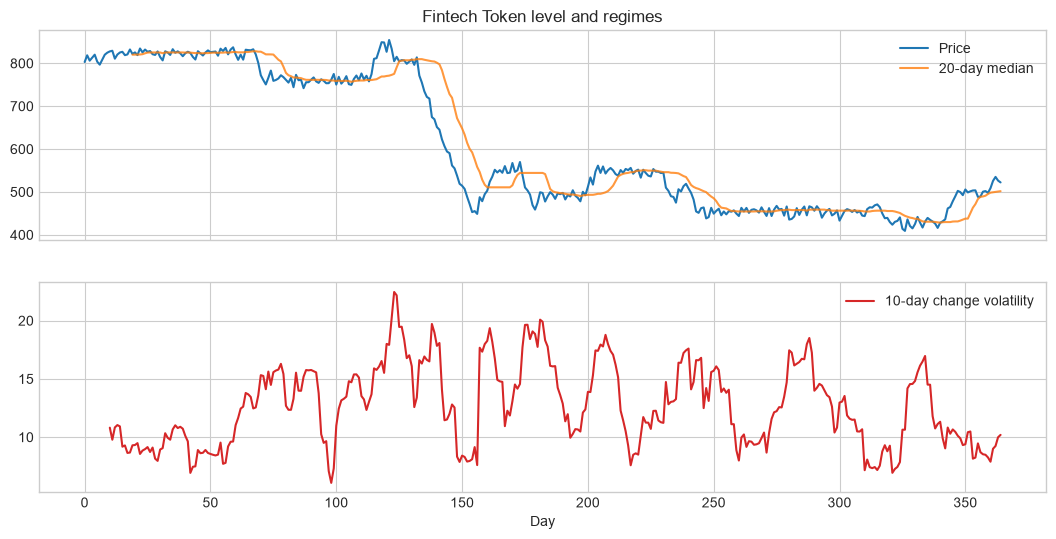

In [5]:
ft = prices["Fintech Token"]
ft_rows, ft_signals = [], {}
for vol_window in [5, 10, 20]:
    vol = ft.diff().rolling(vol_window).std()
    for quantile in [0.50, 0.65, 0.80]:
        cutoff = vol.quantile(quantile)
        active = vol > cutoff
        quiet_signal = -np.sign(ft - ft.rolling(20, min_periods=5).median())
        active_signal = np.sign(ft.diff(5))
        signal = pd.Series(np.where(active, active_signal, quiet_signal), index=ft.index).fillna(0)
        pos = (signal * POSITION_LIMITS["Fintech Token"]).astype(int)
        key = (vol_window, quantile)
        ft_signals[key] = pos
        ft_rows.append({"Vol window": vol_window, "Cutoff quantile": quantile, **signal_metrics(ft, pos)})
ft_results = pd.DataFrame(ft_rows).sort_values("P&L", ascending=False)
display(ft_results)

vol10 = ft.diff().rolling(10).std()
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(ft, label="Price")
axes[0].plot(ft.rolling(20).median(), label="20-day median", alpha=.8)
axes[0].legend(); axes[0].set_title("Fintech Token level and regimes")
axes[1].plot(vol10, color="tab:red", label="10-day change volatility")
axes[1].legend(); axes[1].set_xlabel("Day")
plt.show()

### 6.4 Provisional Sizzle conclusion

- Rolling windows from 15–30 days all perform similarly; 20 days has the best average RMSE ratio, so it is a reasonable robust default.
- The Bread and Sausage coefficients are stable by quarter. MenuDash is noisier but retains a consistently positive coefficient.
- Fixed models trained before every tested chronological split remain profitable, supporting the structural relationship rather than one lucky holdout.
- The honest full-year online 20-day model, flat during warm-up, produces about **$74,760** with no threshold. A $0.005 threshold adds only $30 and is too small to treat as meaningful; prefer the zero-threshold sign rule unless portfolio capital becomes scarce.
- Combined with the confirmed UQ strategy, exploratory P&L is about **$139,341.50**, maximum gross exposure is about **$184,489**, and there are no budget breaches.
- Production candidate: seed with full Round 1 component-change coefficients for immediate Round 2 predictions, then transition to or blend with a causal 20-day rolling estimate once enough Round 2 outcomes exist. This startup choice still needs an isolated simulator implementation test.

## 4. Trend candidates — Jeans, Bread, Sausage and MenuDash

The clues suggest positive drift with short-run noise. Compare an always-long baseline with causal momentum and long/flat moving-average filters. If always-long wins broadly, complicated timing may be unnecessary.

,Instrument,Strategy,P&L,Sharpe,Hit rate,Active days,Max drawdown
16,Bread,momentum_20,"15,495.000",1.936,0.526,344,"-3,235.000"
14,Bread,momentum_10,"13,900.000",1.711,0.508,354,"-5,880.000"
12,Bread,momentum_5,"12,335.000",1.501,0.539,358,"-7,255.000"
17,Bread,long_flat_ma_20,"12,015.000",2.079,0.560,200,"-2,760.000"
15,Bread,long_flat_ma_10,"11,500.000",2.043,0.568,192,"-3,890.000"
13,Bread,long_flat_ma_5,"8,765.000",1.540,0.565,186,"-4,120.000"
40,MenuDash,momentum_40,"32,250.000",1.270,0.399,318,"-12,750.000"
33,MenuDash,always_long,"12,750.000",0.475,0.396,364,"-22,500.000"
41,MenuDash,long_flat_ma_40,"10,500.000",0.557,0.376,178,"-17,250.000"
43,MenuDash,long_flat_ma_60,"7,500.000",0.399,0.394,165,"-11,250.000"


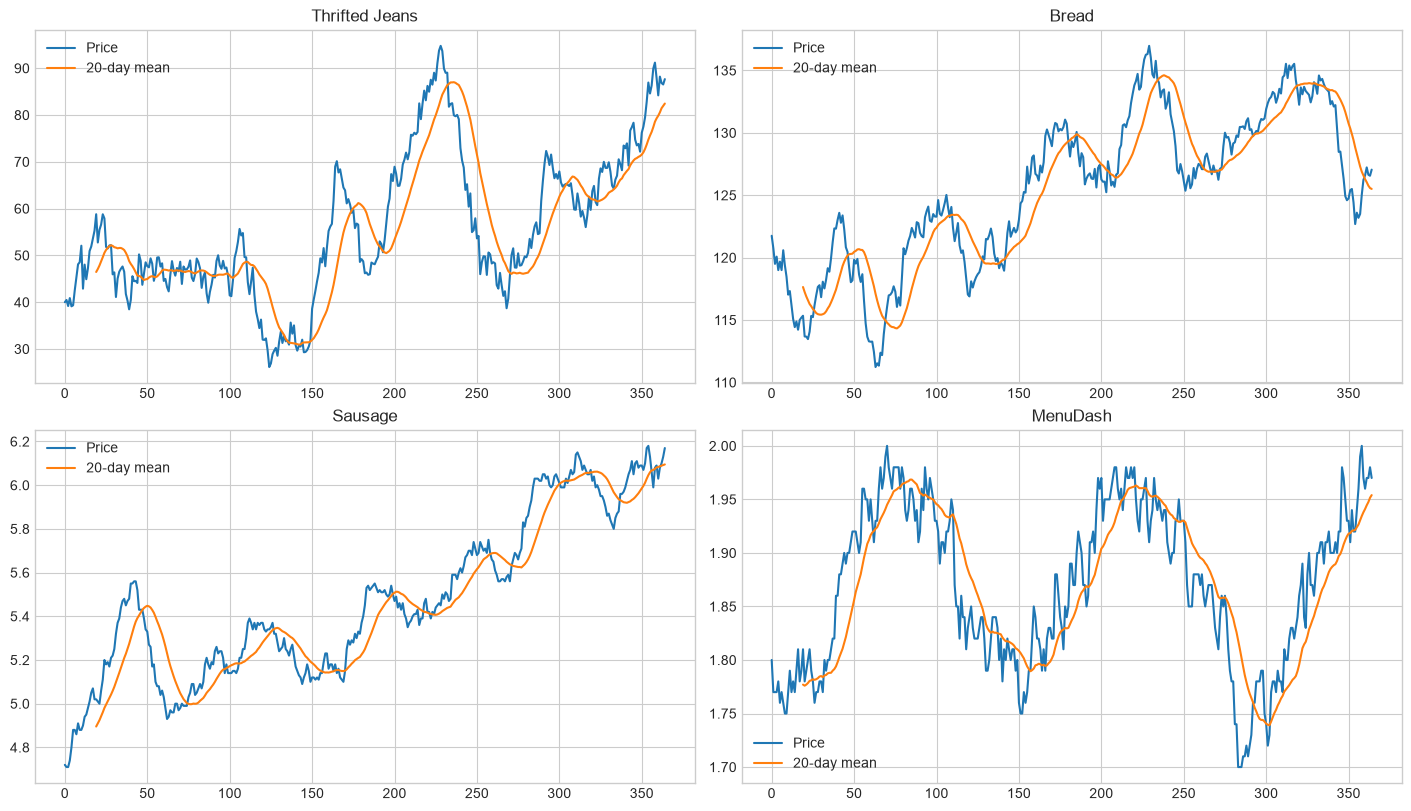

In [6]:
trend_names = ["Thrifted Jeans", "Bread", "Sausage", "MenuDash"]
trend_rows, trend_signals = [], {}
for name in trend_names:
    p = prices[name]
    limit = POSITION_LIMITS[name]
    candidates = {"always_long": pd.Series(limit, index=p.index)}
    for window in [5, 10, 20, 40, 60]:
        candidates[f"momentum_{window}"] = np.sign(p.diff(window)).fillna(0) * limit
        candidates[f"long_flat_ma_{window}"] = (p > p.rolling(window, min_periods=window).mean()).astype(int) * limit
    for strategy, pos in candidates.items():
        pos = pd.Series(pos, index=p.index).fillna(0).astype(int)
        trend_signals[(name, strategy)] = pos
        trend_rows.append({"Instrument": name, "Strategy": strategy, **signal_metrics(p, pos)})
trend_results = pd.DataFrame(trend_rows)
display(trend_results.sort_values(["Instrument", "P&L"], ascending=[True, False]).groupby("Instrument").head(6))

fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)
for ax, name in zip(axes.flat, trend_names):
    p = prices[name]
    ax.plot(p, label="Price")
    ax.plot(p.rolling(20).mean(), label="20-day mean")
    ax.set_title(name); ax.legend()
plt.show()

## 5. Boat Party Ticket — calendar seasonality

The expected pattern is two waves per semester, declines into exams, and a mostly flat summer. The schedule below deliberately uses broad, rounded intervals rather than fitting every wiggle. Phase-shift sensitivity asks whether the idea survives modest calendar error.

This is an in-sample description of Round 1. Its legitimate use in Round 2 depends on the specification's explicit statement that calendar timing repeats.

,P&L,Sharpe,Hit rate,Active days,Max drawdown
Calendar shift,,,,,
-14,"17,210.000",1.007,0.507,288,"-9,400.000"
-12,"23,190.000",1.358,0.503,290,"-10,050.000"
-10,"33,110.000",1.942,0.534,292,"-7,840.000"
-8,"58,500.000",3.303,0.554,294,"-3,460.000"
-6,"60,070.000",3.393,0.547,296,"-3,460.000"
-4,"67,000.000",3.799,0.564,298,"-3,460.000"
-2,"68,220.000",3.867,0.563,300,"-3,460.000"
0,"68,870.000",3.898,0.550,302,"-3,460.000"
2,"72,280.000",4.092,0.550,302,"-3,460.000"


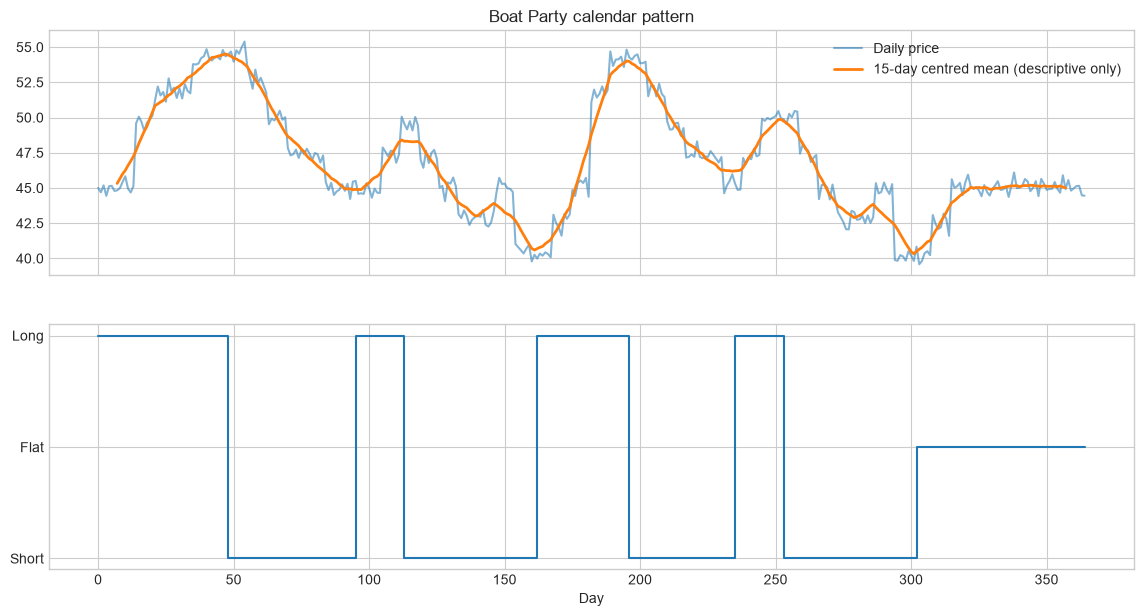

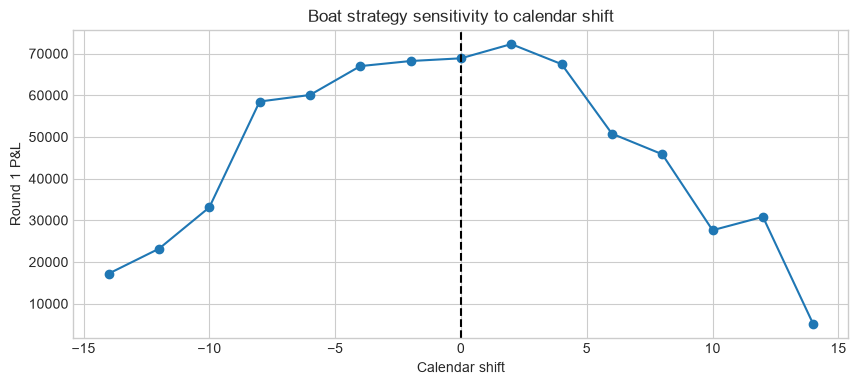

In [7]:
boat = prices["Boat Party Ticket"]
boat_limit = POSITION_LIMITS["Boat Party Ticket"]
base_boat_signal = pd.Series(0, index=boat.index, dtype=int)
rising = [(0, 47), (95, 112), (162, 195), (235, 252)]
falling = [(48, 94), (113, 161), (196, 234), (253, 301)]
for start, end in rising:
    base_boat_signal.loc[start:end] = boat_limit
for start, end in falling:
    base_boat_signal.loc[start:end] = -boat_limit

def shift_without_wrap(values, shift):
    shifted = values.shift(shift, fill_value=0)
    return shifted.astype(int)

boat_rows, boat_signals = [], {}
for shift in range(-14, 15, 2):
    pos = shift_without_wrap(base_boat_signal, shift)
    boat_signals[shift] = pos
    boat_rows.append({"Calendar shift": shift, **signal_metrics(boat, pos)})
boat_results = pd.DataFrame(boat_rows).set_index("Calendar shift")
display(boat_results)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(boat, alpha=.55, label="Daily price")
axes[0].plot(boat.rolling(15, center=True).mean(), lw=2, label="15-day centred mean (descriptive only)")
axes[0].legend(); axes[0].set_title("Boat Party calendar pattern")
axes[1].step(base_boat_signal.index, base_boat_signal / boat_limit, where="post")
axes[1].set_yticks([-1, 0, 1], ["Short", "Flat", "Long"]); axes[1].set_xlabel("Day")
plt.show()
boat_results["P&L"].plot(marker="o", title="Boat strategy sensitivity to calendar shift", figsize=(10, 4))
plt.axvline(0, color="black", ls="--"); plt.ylabel("Round 1 P&L"); plt.show()

## 6. Sausage Sizzle — lagged component model

The clue says today's Sizzle reflects yesterday's shopping. Therefore today's changes in Bread, Sausage and MenuDash should help predict the change in Sizzle from day `t` to `t+1`. A fixed regression on price levels is vulnerable to trend and coefficient drift, so we use a causal rolling regression on changes. At every test day it trains only on outcomes already observed, then predicts the next move. Days 240 onward are reserved for evaluation.

,Holdout RMSE
Rolling window,
20,0.033
40,0.036
60,0.041
90,0.046
120,0.045


Holdout RMSE — unchanged-price baseline: 0.0876; best rolling model: 0.0327


,P&L,Sharpe,Hit rate,Active days,Max drawdown
Forecast threshold,,,,,
0.000,"24,210.000",9.182,0.847,124,-210.000
0.005,"24,180.000",9.193,0.860,121,-210.000
0.010,"23,430.000",8.919,0.860,114,-210.000
0.020,"23,100.000",8.872,0.930,100,-90.000
0.050,"19,350.000",7.579,0.985,65,0.000
0.100,"11,190.000",4.986,1.000,27,0.000


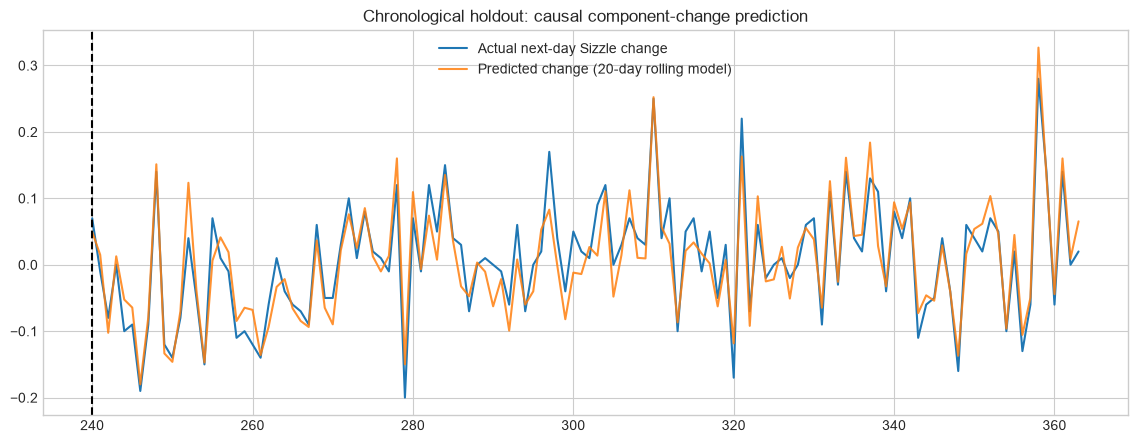

In [8]:
components = ["Bread", "Sausage", "MenuDash"]
component_changes = prices[components].diff()
actual = prices["Sausage Sizzle"]
next_sizzle_change = actual.diff().shift(-1)
split_day = 240
test = (prices.index >= split_day) & next_sizzle_change.notna()

sizzle_model_rows, rolling_predictions = [], {}
for window in [20, 40, 60, 90, 120]:
    prediction = pd.Series(np.nan, index=prices.index)
    for day in prices.index[split_day:-1]:
        # Training targets through day-1 are known when choosing the day position.
        start = max(1, day - window)
        train_x = component_changes.loc[start:day-1]
        train_y = next_sizzle_change.loc[start:day-1]
        design = np.column_stack([np.ones(len(train_x)), train_x.values])
        coef, *_ = np.linalg.lstsq(design, train_y.values, rcond=None)
        prediction.loc[day] = np.r_[1.0, component_changes.loc[day].values] @ coef
    rolling_predictions[window] = prediction
    rmse = np.sqrt(np.mean((prediction.loc[test] - next_sizzle_change.loc[test]) ** 2))
    sizzle_model_rows.append({"Rolling window": window, "Holdout RMSE": rmse})

baseline_rmse = np.sqrt(np.mean(next_sizzle_change.loc[test] ** 2))
sizzle_model_results = pd.DataFrame(sizzle_model_rows).set_index("Rolling window")
display(sizzle_model_results)
print(f"Holdout RMSE — unchanged-price baseline: {baseline_rmse:.4f}; best rolling model: {sizzle_model_results['Holdout RMSE'].min():.4f}")

sizzle_rows, sizzle_signals = [], {}
best_window = int(sizzle_model_results["Holdout RMSE"].idxmin())
forecast_change = rolling_predictions[best_window]
for threshold in [0, 0.005, 0.01, 0.02, 0.05, 0.10]:
    direction = np.where(forecast_change > threshold, 1, np.where(forecast_change < -threshold, -1, 0))
    pos = pd.Series(direction * POSITION_LIMITS["Sausage Sizzle"], index=prices.index)
    pos.loc[~test] = 0
    pos = pos.astype(int)
    sizzle_signals[threshold] = pos
    sizzle_rows.append({"Forecast threshold": threshold, **signal_metrics(actual, pos)})
sizzle_results = pd.DataFrame(sizzle_rows).set_index("Forecast threshold")
display(sizzle_results)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(next_sizzle_change.loc[test], label="Actual next-day Sizzle change")
ax.plot(forecast_change.loc[test], label=f"Predicted change ({best_window}-day rolling model)", alpha=.85)
ax.axvline(split_day, color="black", ls="--")
ax.legend(); ax.set_title("Chronological holdout: causal component-change prediction")
plt.show()

### 6.1 Robustness across windows and start dates

A single holdout can flatter a model. The grid below repeats the strictly causal rolling forecast from several evaluation start dates and window lengths. For each day, training ends at `day - 1`, whose Sizzle outcome is already observable. We compare forecast RMSE with the no-change baseline and trade the sign at the full position limit.

,Evaluation start,Window,RMSE,Baseline RMSE,RMSE ratio,P&L,Sharpe,Hit rate,Active days,Max drawdown
0,60,15,0.031,0.092,0.339,"62,670.000",17.724,0.859,304,-210.000
1,60,20,0.032,0.092,0.341,"61,710.000",17.227,0.845,304,-270.000
2,60,30,0.032,0.092,0.348,"61,470.000",17.107,0.845,304,-270.000
3,60,40,0.035,0.092,0.377,"59,550.000",16.177,0.819,304,-270.000
4,60,60,0.040,0.092,0.430,"57,030.000",15.051,0.799,304,-450.000
5,60,90,0.043,0.092,0.470,"55,410.000",14.375,0.783,304,-480.000
6,90,15,0.031,0.093,0.338,"56,310.000",15.893,0.858,274,-210.000
7,90,20,0.031,0.093,0.336,"55,890.000",15.694,0.847,274,-210.000
8,90,30,0.032,0.093,0.342,"55,650.000",15.581,0.847,274,-210.000
9,90,40,0.035,0.093,0.372,"53,730.000",14.715,0.818,274,-210.000


,Mean_RMSE_ratio,Worst_RMSE_ratio,Mean_PnL,Worst_PnL
Window,,,,
20,0.345,0.374,"45,864.000","24,210.000"
15,0.347,0.379,"46,344.000","24,450.000"
30,0.352,0.378,"45,624.000","23,910.000"
40,0.381,0.409,"44,112.000","23,070.000"
60,0.435,0.468,"42,420.000","22,050.000"
90,0.479,0.521,"40,860.000","20,730.000"


Most robust tested rolling window: 20


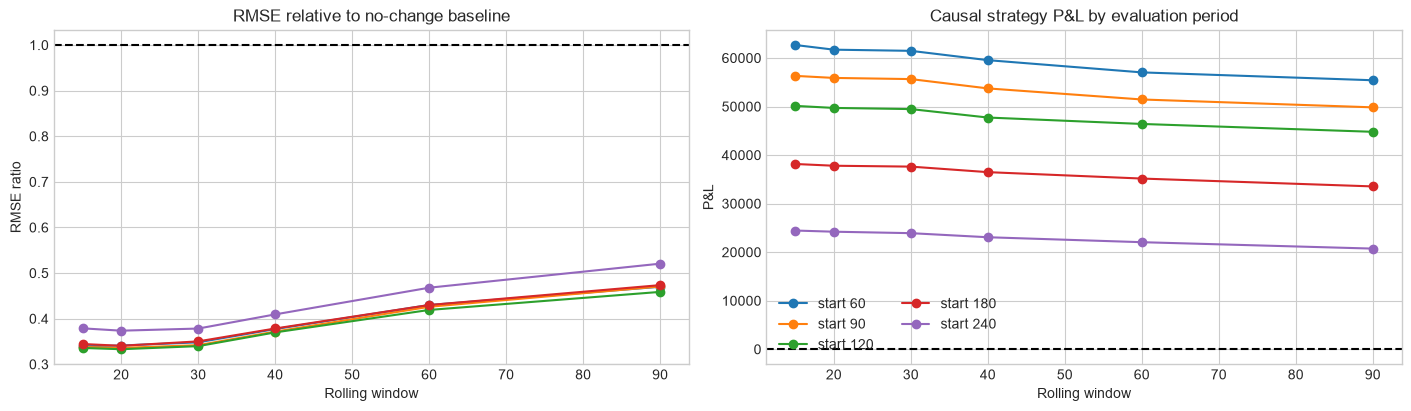

In [9]:
def causal_component_forecast(start_day, window):
    prediction = pd.Series(np.nan, index=prices.index)
    coefficient_rows = []
    for day in prices.index[start_day:-1]:
        train_start = max(1, day - window)
        train_x = component_changes.loc[train_start:day-1]
        train_y = next_sizzle_change.loc[train_start:day-1]
        if len(train_x) < 10:
            continue
        design = np.column_stack([np.ones(len(train_x)), train_x.values])
        coef, *_ = np.linalg.lstsq(design, train_y.values, rcond=None)
        prediction.loc[day] = np.r_[1.0, component_changes.loc[day].values] @ coef
        coefficient_rows.append({
            "Day": day, "Intercept": coef[0],
            **dict(zip(components, coef[1:])),
        })
    return prediction, pd.DataFrame(coefficient_rows).set_index("Day")

validation_rows = []
for evaluation_start in [60, 90, 120, 180, 240]:
    evaluation_mask = (prices.index >= evaluation_start) & next_sizzle_change.notna()
    baseline = np.sqrt(np.mean(next_sizzle_change.loc[evaluation_mask] ** 2))
    for window in [15, 20, 30, 40, 60, 90]:
        prediction, _ = causal_component_forecast(evaluation_start, window)
        rmse = np.sqrt(np.mean((prediction.loc[evaluation_mask] - next_sizzle_change.loc[evaluation_mask]) ** 2))
        position = pd.Series(
            np.sign(prediction).fillna(0) * POSITION_LIMITS["Sausage Sizzle"],
            index=prices.index, dtype=int,
        )
        metrics = signal_metrics(actual, position)
        validation_rows.append({
            "Evaluation start": evaluation_start, "Window": window,
            "RMSE": rmse, "Baseline RMSE": baseline,
            "RMSE ratio": rmse / baseline, **metrics,
        })
sizzle_validation = pd.DataFrame(validation_rows)
display(sizzle_validation.round(4))

window_summary = sizzle_validation.groupby("Window").agg(
    Mean_RMSE_ratio=("RMSE ratio", "mean"),
    Worst_RMSE_ratio=("RMSE ratio", "max"),
    Mean_PnL=("P&L", "mean"),
    Worst_PnL=("P&L", "min"),
)
display(window_summary.sort_values("Mean_RMSE_ratio"))
robust_sizzle_window = int(window_summary["Mean_RMSE_ratio"].idxmin())
print("Most robust tested rolling window:", robust_sizzle_window)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
for start, group in sizzle_validation.groupby("Evaluation start"):
    axes[0].plot(group["Window"], group["RMSE ratio"], marker="o", label=f"start {start}")
    axes[1].plot(group["Window"], group["P&L"], marker="o", label=f"start {start}")
axes[0].axhline(1, color="black", ls="--"); axes[0].set_title("RMSE relative to no-change baseline")
axes[0].set_xlabel("Rolling window"); axes[0].set_ylabel("RMSE ratio")
axes[1].axhline(0, color="black", ls="--"); axes[1].set_title("Causal strategy P&L by evaluation period")
axes[1].set_xlabel("Rolling window"); axes[1].set_ylabel("P&L")
axes[1].legend(ncol=2)
plt.show()

### 6.2 Coefficient stability and Round 2 startup

Round 2 begins without same-year training history. We therefore compare coefficients fitted in separate Round 1 periods and fixed models trained before several chronological splits. Stable coefficients support embedding Round 1 estimates for immediate use; instability favours a flat warm-up followed by online rolling estimates.

In [10]:
def fit_component_model(start_day, end_day):
    train_x = component_changes.loc[start_day:end_day]
    train_y = next_sizzle_change.loc[start_day:end_day]
    valid = train_x.notna().all(axis=1) & train_y.notna()
    design = np.column_stack([np.ones(valid.sum()), train_x.loc[valid].values])
    coef, *_ = np.linalg.lstsq(design, train_y.loc[valid].values, rcond=None)
    return pd.Series(coef, index=["Intercept", *components])

coefficient_periods = {
    "Q1": (1, 90), "Q2": (91, 181),
    "Q3": (182, 272), "Q4": (273, 363),
    "Full Round 1": (1, 363),
}
coefficient_stability = pd.DataFrame({
    label: fit_component_model(start, end)
    for label, (start, end) in coefficient_periods.items()
}).T
display(coefficient_stability)

fixed_rows = []
for split in [60, 90, 120, 180, 240]:
    coef = fit_component_model(1, split - 1).values
    mask = (prices.index >= split) & next_sizzle_change.notna()
    design = np.column_stack([np.ones(mask.sum()), component_changes.loc[mask].values])
    prediction = pd.Series(np.nan, index=prices.index)
    prediction.loc[mask] = design @ coef
    position = pd.Series(
        np.sign(prediction).fillna(0) * POSITION_LIMITS["Sausage Sizzle"],
        index=prices.index, dtype=int,
    )
    rmse = np.sqrt(np.mean((prediction.loc[mask] - next_sizzle_change.loc[mask]) ** 2))
    fixed_rows.append({
        "Training ends": split - 1, "Evaluation starts": split,
        "RMSE": rmse, **signal_metrics(actual, position),
    })
fixed_model_validation = pd.DataFrame(fixed_rows)
display(fixed_model_validation)

round1_sizzle_coefficients = coefficient_stability.loc["Full Round 1"]
print("Round 1 coefficients available to seed the submitted algorithm:")
display(round1_sizzle_coefficients.to_frame("Coefficient"))

# Honest full-year online strategy: flat until enough completed outcomes exist.
online_start = robust_sizzle_window + 1
online_sizzle_forecast, online_sizzle_coefficients = causal_component_forecast(online_start, robust_sizzle_window)
threshold_rows, online_sizzle_signals = [], {}
for threshold in [0, 0.005, 0.01, 0.02, 0.05, 0.10]:
    direction = np.where(online_sizzle_forecast > threshold, 1, np.where(online_sizzle_forecast < -threshold, -1, 0))
    position = pd.Series(direction * POSITION_LIMITS["Sausage Sizzle"], index=prices.index, dtype=int)
    online_sizzle_signals[threshold] = position
    threshold_rows.append({"Threshold": threshold, **signal_metrics(actual, position)})
online_sizzle_thresholds = pd.DataFrame(threshold_rows).set_index("Threshold")
display(online_sizzle_thresholds)
best_online_sizzle_threshold = online_sizzle_thresholds["P&L"].idxmax()
print("Exploratory best online threshold:", best_online_sizzle_threshold)

,Intercept,Bread,Sausage,MenuDash
Q1,0.016,0.078,1.694,0.511
Q2,-0.007,0.077,1.750,0.137
Q3,-0.006,0.078,1.779,0.366
Q4,0.017,0.074,1.538,0.386
Full Round 1,0.005,0.077,1.692,0.360


,Training ends,Evaluation starts,RMSE,P&L,Sharpe,Hit rate,Active days,Max drawdown
0,59,60,0.049,"57,270.000",15.154,0.816,304,-660.000
1,89,90,0.041,"53,610.000",14.662,0.832,274,-210.000
2,119,120,0.037,"47,670.000",13.281,0.832,244,-330.000
3,179,180,0.038,"35,640.000",11.069,0.826,184,-330.000
4,239,240,0.040,"22,650.000",8.469,0.823,124,-330.000


Round 1 coefficients available to seed the submitted algorithm:


,Coefficient
Intercept,0.005
Bread,0.077
Sausage,1.692
MenuDash,0.360


,P&L,Sharpe,Hit rate,Active days,Max drawdown
Threshold,,,,,
0.000,"74,760.000",19.860,0.857,343,-270.000
0.005,"74,790.000",19.990,0.876,331,-210.000
0.010,"73,920.000",19.681,0.896,309,-210.000
0.020,"72,780.000",19.306,0.939,279,-90.000
0.050,"63,570.000",15.908,0.985,195,-30.000
0.100,"43,890.000",10.714,1.000,99,0.000


Exploratory best online threshold: 0.005


### 6.3 Incremental value beside UQ Dollar

This combines the confirmed UQ peg strategy with the honest online Sizzle strategy. It checks whether the two signals fit comfortably within the shared budget and reports Sizzle's incremental P&L. The Sizzle threshold remains exploratory until stability, not maximum Round 1 P&L, determines the production choice.

,UQ + online Sizzle
UQ P&L,"64,551.500"
Incremental Sizzle P&L,"74,790.000"
Combined P&L,"139,341.500"
Combined Sharpe,18.509
Combined max drawdown,-638.500
Maximum gross exposure,"184,489.000"
Budget breaches,0.000


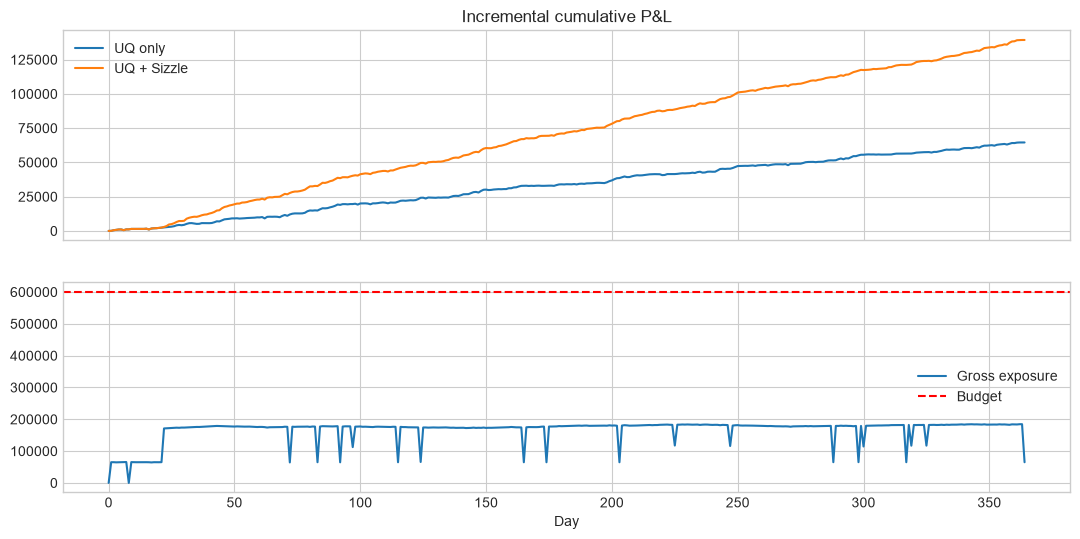

In [11]:
uq_position = pd.Series(
    -np.sign(prices["UQ Dollar"] - 100) * POSITION_LIMITS["UQ Dollar"],
    index=prices.index, dtype=int,
)
sizzle_position = online_sizzle_signals[best_online_sizzle_threshold]
uq_sizzle_positions = pd.DataFrame({
    "UQ Dollar": uq_position,
    "Sausage Sizzle": sizzle_position,
})
uq_sizzle_gross = (uq_sizzle_positions.abs() * prices[uq_sizzle_positions.columns]).sum(axis=1)
uq_pnl = uq_position * prices["UQ Dollar"].diff().shift(-1)
sizzle_pnl = sizzle_position * actual.diff().shift(-1)
combined_pnl = uq_pnl + sizzle_pnl
uq_sizzle_summary = pd.Series({
    "UQ P&L": uq_pnl.sum(),
    "Incremental Sizzle P&L": sizzle_pnl.sum(),
    "Combined P&L": combined_pnl.sum(),
    "Combined Sharpe": np.sqrt(365) * combined_pnl.mean() / combined_pnl.std(ddof=1),
    "Combined max drawdown": max_drawdown(combined_pnl),
    "Maximum gross exposure": uq_sizzle_gross.max(),
    "Budget breaches": int((uq_sizzle_gross > BUDGET).sum()),
})
display(uq_sizzle_summary.to_frame("UQ + online Sizzle"))

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(uq_pnl.fillna(0).cumsum(), label="UQ only")
axes[0].plot(combined_pnl.fillna(0).cumsum(), label="UQ + Sizzle")
axes[0].legend(); axes[0].set_title("Incremental cumulative P&L")
axes[1].plot(uq_sizzle_gross, label="Gross exposure")
axes[1].axhline(BUDGET, color="red", ls="--", label="Budget")
axes[1].legend(); axes[1].set_xlabel("Day")
plt.show()

## 7. Liferaft Ticket — crowd game, not a time-series backtest

The local simulator explicitly excludes Liferaft P&L. Its CSV can reveal the *illustrative* sequence of majority outcomes, but the marking price will be generated live from this year's teams.

Ignoring our own ability to swing a tie, let `p` be the probability that the active-team majority is long. Then the expected price move is `8,000 - 13,000p`; long has positive expectation below `p = 8/13 ≈ 61.5%`, while short has the opposite payoff. This is a scenario calculation, not an estimated edge.

In [12]:
liferaft = prices["Liferaft Ticket"]
moves = liferaft.diff().dropna()
display(moves.value_counts().sort_index().rename("Days").to_frame())

p_majority_long = np.linspace(0, 1, 11)
expected_move = 8_000 * (1 - p_majority_long) - 5_000 * p_majority_long
liferaft_scenarios = pd.DataFrame({
    "P(majority long)": p_majority_long,
    "Expected price move": expected_move,
    "Preferred side if vote impact is negligible": np.where(expected_move > 0, "Long", np.where(expected_move < 0, "Short", "Flat")),
})
display(liferaft_scenarios)
print("Break-even probability that the majority is long:", 8 / 13)

,Days
Liferaft Ticket,
"-5,000.000",214
"8,000.000",150


,P(majority long),Expected price move,Preferred side if vote impact is negligible
0,0.000,"8,000.000",Long
1,0.100,"6,700.000",Long
2,0.200,"5,400.000",Long
3,0.300,"4,100.000",Long
4,0.400,"2,800.000",Long
5,0.500,"1,500.000",Long
6,0.600,200.000,Long
7,0.700,"-1,100.000",Short
8,0.800,"-2,400.000",Short
9,0.900,"-3,700.000",Short


Break-even probability that the majority is long: 0.6153846153846154


## 8. Candidate comparison and provisional portfolio

This gathers the strongest exploratory candidate per ordinary instrument and checks the shared $600,000 gross-exposure constraint. It is **not** a final model: most candidates were selected on Round 1 itself. The next research step is walk-forward validation and parameter-stability testing.

,P&L,Sharpe,Hit rate,Active days,Max drawdown
Instrument,,,,,
Sausage Sizzle,"74,790.000",19.990,0.876,331,-210.000
Boat Party Ticket,"68,870.000",3.898,0.550,302,"-3,460.000"
Fintech Token,"66,188.000",2.650,0.563,359,"-17,370.000"
UQ Dollar,"64,551.500",9.880,0.728,356,-968.500
Thrifted Jeans,"55,008.000",1.306,0.501,359,"-42,528.000"
MenuDash,"32,250.000",1.270,0.399,318,"-12,750.000"
Bread,"15,495.000",1.936,0.526,344,"-3,235.000"
Sausage,"8,350.000",2.670,0.499,341,"-2,150.000"
Liferaft Ticket,0.000,NaN,NaN,0,0.000


,Provisional portfolio
Total P&L,"385,499.950"
Sharpe,6.927
Max drawdown,"-13,408.500"
Maximum gross exposure,"599,552.700"
Days requiring scaling,3.000


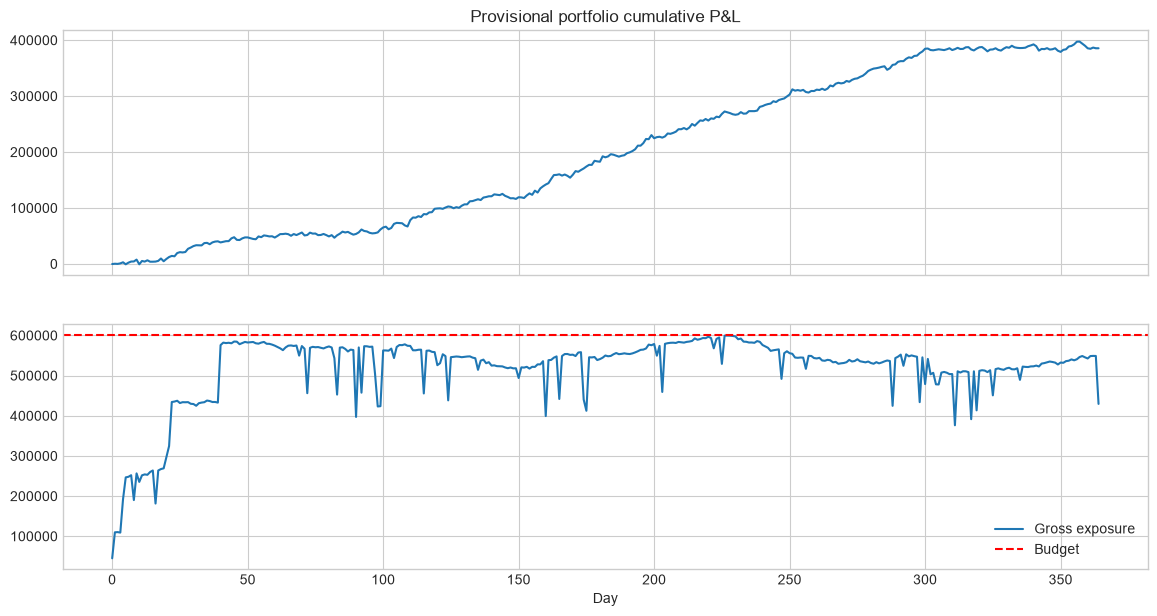

In [13]:
candidate_positions = {}
candidate_rows = []

best_uq = uq_results["P&L"].idxmax()
candidate_positions["UQ Dollar"] = pd.Series(
    np.where((uq - 100).abs() >= best_uq, -np.sign(uq - 100) * POSITION_LIMITS["UQ Dollar"], 0),
    index=prices.index, dtype=int
)

best_ft = ft_results.iloc[0]
candidate_positions["Fintech Token"] = ft_signals[(int(best_ft["Vol window"]), float(best_ft["Cutoff quantile"]))]

for name in trend_names:
    subset = trend_results[trend_results["Instrument"] == name]
    strategy = subset.loc[subset["P&L"].idxmax(), "Strategy"]
    candidate_positions[name] = trend_signals[(name, strategy)]

candidate_positions["Boat Party Ticket"] = base_boat_signal
candidate_positions["Sausage Sizzle"] = online_sizzle_signals[best_online_sizzle_threshold]
candidate_positions["Liferaft Ticket"] = pd.Series(0, index=prices.index, dtype=int)

for name, pos in candidate_positions.items():
    candidate_rows.append({"Instrument": name, **signal_metrics(prices[name], pos)})
display(pd.DataFrame(candidate_rows).set_index("Instrument").sort_values("P&L", ascending=False))

raw_positions = pd.DataFrame(candidate_positions, index=prices.index).fillna(0).astype(int)
raw_gross = (raw_positions.abs() * prices[raw_positions.columns]).sum(axis=1)
scale = (BUDGET / raw_gross.replace(0, np.nan)).clip(upper=1).fillna(1)
budgeted_positions = raw_positions.mul(scale, axis=0).apply(np.trunc).astype(int)
gross = (budgeted_positions.abs() * prices[budgeted_positions.columns]).sum(axis=1)
portfolio_pnl = (budgeted_positions * prices[budgeted_positions.columns].diff().shift(-1)).sum(axis=1)
portfolio_summary = pd.Series({
    "Total P&L": portfolio_pnl.sum(),
    "Sharpe": np.sqrt(365) * portfolio_pnl.mean() / portfolio_pnl.std(ddof=1),
    "Max drawdown": max_drawdown(portfolio_pnl),
    "Maximum gross exposure": gross.max(),
    "Days requiring scaling": int((scale < 1).sum()),
})
display(portfolio_summary.to_frame("Provisional portfolio"))

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(portfolio_pnl.cumsum()); axes[0].set_title("Provisional portfolio cumulative P&L")
axes[1].plot(gross, label="Gross exposure")
axes[1].axhline(BUDGET, color="red", ls="--", label="Budget")
axes[1].legend(); axes[1].set_xlabel("Day")
plt.show()

## Next steps

1. Replace full-sample parameter selection with expanding-window or walk-forward tests.
2. Plot parameter sensitivity rather than selecting isolated winners.
3. Improve Fintech regime detection using only trailing information.
4. Choose Sizzle startup and threshold rules from stability evidence, then implement the causal model.
5. Convert robust signals into a single budget allocator for `algorithm.py`.
6. Decide on Liferaft behaviour separately, accounting for our vote's effect on ties and small majorities.

## 9. Structural latent-labour state-space experiment

The earlier sections establish the causal 20-day component-change regression as the benchmark. This section tests the structural hypothesis directly across chronological starts at days 60, 90, 120, 180 and 240. Every result below is a walk-forward-style simulation: the position at day `t` is scored on `Sizzle[t+1] - Sizzle[t]`, while model fitting may use only observations available through day `t`.

### Identified equations

The state is labour measured in Sizzle-dollar units, so its loading in the Sizzle equation is fixed to one:

```text
Sizzle[t+1] = a + beta_b * Bread[t] + beta_s * Sausage[t] + Labour[t] + eps_s[t+1]
MenuDash[t] = c + lambda * Labour[t] + eps_m[t]
Labour[t] = mu + phi * Labour[t-1] + eta[t]
```

For estimation, the equivalent reduced form `Sizzle[t+1] = d + beta_b*Bread[t] + beta_s*Sausage[t] + gamma*MenuDash[t] + error` is fitted on training rows only. We set `c` to the training mean of MenuDash, set `lambda = 1/gamma`, and recover `a = d + gamma*c`. This fixes the scale and centres the latent state; without fixing the Sizzle loading, multiplying Labour by a constant and dividing lambda by the same constant would leave the model unchanged.

At decision day `t`, the filter sequence is: (1) use `Sizzle[t] - a - beta_b*Bread[t-1] - beta_s*Sausage[t-1]` as an observation of `Labour[t-1]`; (2) propagate the state with the AR(1) transition; (3) update `Labour[t]` with current MenuDash; and (4) forecast `Sizzle[t+1]`. The state and observation variances are selected by a predeclared likelihood grid using only the training prefix.

In [14]:
# Self-contained arrays for the structural experiment. The prefix rules are explicit below.
sizzle = prices['Sausage Sizzle'].to_numpy(dtype=float).copy()
bread = prices['Bread'].to_numpy(dtype=float).copy()
sausage = prices['Sausage'].to_numpy(dtype=float).copy()
menudash = prices['MenuDash'].to_numpy(dtype=float).copy()
n_days = len(sizzle)
sizzle_move = np.full(n_days, np.nan)
sizzle_move[:-1] = np.diff(sizzle)
component_change_array = np.column_stack([
    np.r_[np.nan, np.diff(bread)],
    np.r_[np.nan, np.diff(sausage)],
    np.r_[np.nan, np.diff(menudash)],
])
sizzle_component_names = ['Bread', 'Sausage', 'MenuDash']
SIZZLE_LIMIT = POSITION_LIMITS['Sausage Sizzle']
EVAL_STARTS = [60, 90, 120, 180, 240]
THRESHOLDS = [0.0, 0.005, 0.01, 0.02, 0.05]
RIDGE_ALPHA = 0.1
ONLINE_WARMUP = 30
ONLINE_REFIT_EVERY = 10
BLEND_ONLINE_WEIGHT = 0.5
NOISE_MULTIPLIERS = [0.01, 0.1, 0.25, 0.5, 1.0, 2.0, 4.0, 10.0, 25.0, 100.0]

def evaluate_prediction(prediction, start_day, threshold=0.0, end_day=None):
    last_day = n_days - 1 if end_day is None else min(int(end_day), n_days - 1)
    eval_days = np.arange(int(start_day), last_day)
    prediction = np.asarray(prediction, dtype=float)
    if len(eval_days) == 0 or not np.isfinite(prediction[eval_days]).all():
        missing_days = eval_days[~np.isfinite(prediction[eval_days])] if len(eval_days) else eval_days
        raise ValueError(f'Prediction is missing on evaluated days: {missing_days[:5]}')
    realised = sizzle_move[eval_days]
    direction = np.where(prediction[eval_days] > threshold, 1, np.where(prediction[eval_days] < -threshold, -1, 0))
    positions = (direction * SIZZLE_LIMIT).astype(int)
    pnl = positions * realised
    baseline_rmse = float(np.sqrt(np.mean(realised ** 2)))
    rmse = float(np.sqrt(np.mean((prediction[eval_days] - realised) ** 2)))
    active = positions != 0
    daily_sd = float(np.std(pnl, ddof=1)) if len(pnl) > 1 else np.nan
    equity = np.cumsum(pnl)
    drawdown = equity - np.maximum.accumulate(equity)
    return {
        'RMSE': rmse,
        'Baseline RMSE': baseline_rmse,
        'RMSE ratio': rmse / baseline_rmse,
        'P&L': float(np.sum(pnl)),
        'Sharpe': float(np.sqrt(365) * np.mean(pnl) / daily_sd) if daily_sd > 0 else np.nan,
        'Hit rate': float(np.mean(pnl[active] > 0)) if active.any() else np.nan,
        'Active days': int(np.sum(active)),
        'Max drawdown': float(np.min(drawdown)),
    }

def fit_change_model(train_days, ridge_alpha=None):
    train_days = np.asarray(train_days, dtype=int)
    valid = (train_days >= 1) & (train_days < n_days - 1)
    train_days = train_days[valid]
    valid = np.isfinite(sizzle_move[train_days]) & np.isfinite(component_change_array[train_days]).all(axis=1)
    train_days = train_days[valid]
    x = component_change_array[train_days]
    y = sizzle_move[train_days]
    if ridge_alpha is None:
        design = np.column_stack([np.ones(len(x)), x])
        return np.linalg.lstsq(design, y, rcond=None)[0]
    x_mean = x.mean(axis=0)
    x_sd = x.std(axis=0, ddof=0)
    x_sd = np.where(x_sd > 1e-12, x_sd, 1.0)
    x_standard = (x - x_mean) / x_sd
    y_mean = y.mean()
    beta_standard = np.linalg.solve(
        x_standard.T @ x_standard + ridge_alpha * np.eye(x_standard.shape[1]),
        x_standard.T @ (y - y_mean),
    )
    beta_raw = beta_standard / x_sd
    intercept = y_mean - x_mean @ beta_raw
    return np.r_[intercept, beta_raw]

def causal_change_forecast(start_day, window=20, ridge_alpha=None):
    prediction = np.full(n_days, np.nan)
    coefficient_rows = []
    for day in range(int(start_day), n_days - 1):
        train_days = np.arange(max(1, day - window), day)
        valid = np.isfinite(sizzle_move[train_days]) & np.isfinite(component_change_array[train_days]).all(axis=1)
        train_days = train_days[valid]
        if len(train_days) < 10 or not np.isfinite(component_change_array[day]).all():
            continue
        coef = fit_change_model(train_days, ridge_alpha=ridge_alpha)
        prediction[day] = np.r_[1.0, component_change_array[day]] @ coef
        coefficient_rows.append([day, *coef])
    coefficient_history = pd.DataFrame(
        coefficient_rows, columns=['Day', 'Intercept', *sizzle_component_names]
    ).set_index('Day')
    return prediction, coefficient_history

def fixed_change_forecast(start_day):
    # This is the permitted Round 2 seed: fit once on the available prefix, then hold coefficients fixed.
    coef = fit_change_model(np.arange(1, int(start_day)), ridge_alpha=None)
    prediction = np.full(n_days, np.nan)
    valid = np.isfinite(component_change_array).all(axis=1)
    prediction[valid] = np.column_stack([np.ones(np.sum(valid)), component_change_array[valid]]) @ coef
    return prediction, coef

def fit_structural_params(end_day):
    # At decision day end_day, targets through end_day-1 are known and Sizzle[end_day] is observable.
    end_day = int(end_day)
    target_days = np.arange(0, end_day)
    design = np.column_stack([np.ones(len(target_days)), bread[target_days], sausage[target_days], menudash[target_days]])
    target = sizzle[target_days + 1]
    d, beta_b, beta_s, gamma = np.linalg.lstsq(design, target, rcond=None)[0]
    if gamma <= 0:
        raise ValueError('Training sample produced a non-positive MenuDash loading')
    c = float(np.mean(menudash[:end_day]))
    lambda_ = float(1.0 / gamma)
    a = float(d + gamma * c)
    labour_proxy = target - a - beta_b * bread[:end_day] - beta_s * sausage[:end_day]
    state_design = np.column_stack([np.ones(len(labour_proxy) - 1), labour_proxy[:-1]])
    mu, phi_raw = np.linalg.lstsq(state_design, labour_proxy[1:], rcond=None)[0]
    # Early prefixes occasionally estimate phi above one; clip only to a stable, near-random-walk range.
    phi = float(np.clip(phi_raw, 0.90, 1.0))
    state_residual = labour_proxy[1:] - (mu + phi * labour_proxy[:-1])
    menu_residual = menudash[:end_day] - (c + lambda_ * labour_proxy)
    structural_residual = target - design @ np.array([d, beta_b, beta_s, gamma])
    return {
        'd': float(d), 'a': a, 'beta_b': float(beta_b), 'beta_s': float(beta_s),
        'gamma': float(gamma), 'c': c, 'lambda': lambda_,
        'mu': float(mu), 'phi': phi, 'phi_raw': float(phi_raw),
        'q0': float(max(np.var(state_residual, ddof=1), 1e-8)),
        'rm0': float(max(np.var(menu_residual, ddof=1), 1e-10)),
        'rs0': float(max(np.var(structural_residual, ddof=1), 1e-8)),
        'labour_mean': float(np.mean(labour_proxy)),
        'labour_var': float(max(np.var(labour_proxy, ddof=1), 1e-8)),
    }

def scalar_update(state_mean, state_var, observation, loading, observation_var):
    innovation_var = loading * loading * state_var + observation_var
    gain = state_var * loading / innovation_var
    innovation = observation - loading * state_mean
    return (state_mean + gain * innovation, (1.0 - gain * loading) * state_var, innovation, innovation_var)

def kalman_log_likelihood(params, q, r_s, r_m, end_day):
    state_mean = params['labour_mean']
    state_var = max(params['labour_var'], q)
    log_likelihood = 0.0
    state_mean, state_var, innovation, innovation_var = scalar_update(
        state_mean, state_var, menudash[0] - params['c'], params['lambda'], r_m
    )
    log_likelihood += -0.5 * (np.log(2 * np.pi * innovation_var) + innovation * innovation / innovation_var)
    for day in range(1, int(end_day) + 1):
        sizzle_observation = sizzle[day] - params['a'] - params['beta_b'] * bread[day - 1] - params['beta_s'] * sausage[day - 1]
        state_mean, state_var, innovation, innovation_var = scalar_update(
            state_mean, state_var, sizzle_observation, 1.0, r_s
        )
        log_likelihood += -0.5 * (np.log(2 * np.pi * innovation_var) + innovation * innovation / innovation_var)
        state_mean = params['mu'] + params['phi'] * state_mean
        state_var = params['phi'] ** 2 * state_var + q
        state_mean, state_var, innovation, innovation_var = scalar_update(
            state_mean, state_var, menudash[day] - params['c'], params['lambda'], r_m
        )
        log_likelihood += -0.5 * (np.log(2 * np.pi * innovation_var) + innovation * innovation / innovation_var)
    return float(log_likelihood)

def tune_kalman_noise(params, end_day):
    candidates = []
    best = (-np.inf, None)
    for q_multiplier in NOISE_MULTIPLIERS:
        for r_s_multiplier in NOISE_MULTIPLIERS:
            for r_m_multiplier in NOISE_MULTIPLIERS:
                q = max(params['q0'] * q_multiplier, 1e-10)
                r_s = max(params['rs0'] * r_s_multiplier, 1e-10)
                r_m = max(params['rm0'] * r_m_multiplier, 1e-12)
                likelihood = kalman_log_likelihood(params, q, r_s, r_m, end_day)
                if likelihood > best[0]:
                    best = (likelihood, (q, r_s, r_m))
    tuned = dict(params)
    tuned.update({'q': best[1][0], 'r_s': best[1][1], 'r_m': best[1][2], 'train_loglik': best[0]})
    return tuned

def kalman_forecast(params, last_day=None):
    # With last_day set, this function literally processes only the observed prefix through last_day.
    last_day = n_days - 1 if last_day is None else int(last_day)
    prediction = np.full(n_days, np.nan)
    state_mean = params['labour_mean']
    state_var = max(params['labour_var'], params['q'])
    state_mean, state_var, _, _ = scalar_update(
        state_mean, state_var, menudash[0] - params['c'], params['lambda'], params['r_m']
    )
    prediction[0] = params['a'] + params['beta_b'] * bread[0] + params['beta_s'] * sausage[0] + state_mean - sizzle[0]
    for day in range(1, last_day + 1):
        sizzle_observation = sizzle[day] - params['a'] - params['beta_b'] * bread[day - 1] - params['beta_s'] * sausage[day - 1]
        state_mean, state_var, _, _ = scalar_update(state_mean, state_var, sizzle_observation, 1.0, params['r_s'])
        state_mean = params['mu'] + params['phi'] * state_mean
        state_var = params['phi'] ** 2 * state_var + params['q']
        state_mean, state_var, _, _ = scalar_update(
            state_mean, state_var, menudash[day] - params['c'], params['lambda'], params['r_m']
        )
        prediction[day] = params['a'] + params['beta_b'] * bread[day] + params['beta_s'] * sausage[day] + state_mean - sizzle[day]
    return prediction

def fixed_structural_forecast(params):
    # Current MenuDash is used as a direct labour proxy, with no temporal state filtering.
    return params['d'] + params['beta_b'] * bread + params['beta_s'] * sausage + params['gamma'] * menudash - sizzle

def online_kalman_forecast(start_day):
    prediction = np.full(n_days, np.nan)
    refit_days = []
    active_params = None
    warmup_end = int(start_day) + ONLINE_WARMUP
    next_refit = warmup_end
    for day in range(int(start_day), n_days - 1):
        if active_params is None and day < warmup_end:
            continue
        if active_params is None or day >= next_refit:
            active_params = tune_kalman_noise(fit_structural_params(day), day)
            refit_days.append(day)
            next_refit = day + ONLINE_REFIT_EVERY
        prediction[day] = kalman_forecast(active_params, last_day=day)[day]
    return prediction, refit_days

### 9.1 Causal implementation, model comparison and stability

The first table reproduces the existing 20-day rolling OLS using the same training rows: at day `t`, the last fitted target is `Sizzle[t] - Sizzle[t-1]`, which is observable before the position is selected. Ridge uses the same window and standardises predictors using that window only. The fixed change model is an additional startup control; the fixed structural model uses current MenuDash directly, while the Kalman variants apply the latent-state update above.

,Evaluation start,RMSE,Baseline RMSE,RMSE ratio,P&L,Sharpe,Hit rate,Active days,Max drawdown
0,60,0.032,0.092,0.341,"61,710.000",20.574,0.845,304,-270.000
1,90,0.031,0.093,0.336,"55,890.000",20.502,0.847,274,-210.000
2,120,0.031,0.093,0.333,"49,710.000",20.226,0.848,244,-210.000
3,180,0.031,0.091,0.341,"37,800.000",21.513,0.859,184,-210.000
4,240,0.033,0.088,0.374,"24,210.000",21.125,0.847,124,-210.000


,Model,Evaluation start,RMSE,Baseline RMSE,RMSE ratio,P&L,Sharpe,Hit rate,Active days,Max drawdown
0,20d rolling OLS,60,0.032,0.092,0.341,"61,710.000",20.574,0.845,304,-270.000
1,20d ridge (alpha=0.1),60,0.031,0.092,0.340,"61,830.000",20.661,0.849,304,-270.000
2,Fixed change OLS,60,0.049,0.092,0.528,"57,270.000",17.717,0.816,304,-660.000
3,Fixed structural level,60,0.387,0.092,4.198,"14,730.000",3.391,0.546,304,"-3,540.000"
4,Kalman fixed,60,0.072,0.092,0.780,"48,630.000",13.506,0.743,304,"-1,170.000"
5,Kalman seeded->online,60,0.059,0.092,0.639,"51,270.000",14.655,0.747,304,-510.000
6,Kalman blend 50/50,60,0.060,0.092,0.656,"51,690.000",14.848,0.773,304,"-1,170.000"
7,20d rolling OLS,90,0.031,0.093,0.336,"55,890.000",20.502,0.847,274,-210.000
8,20d ridge (alpha=0.1),90,0.031,0.093,0.335,"56,010.000",20.597,0.850,274,-210.000
9,Fixed change OLS,90,0.041,0.093,0.443,"53,610.000",18.815,0.832,274,-210.000


,Mean_RMSE_ratio,Worst_RMSE_ratio,Mean_PnL,Worst_PnL,Mean_Sharpe,Mean_Hit_rate,Mean_active_days,Worst_max_drawdown,Profitable on every split
Model,,,,,,,,,
20d rolling OLS,0.345,0.374,"45,864.000","24,210.000",20.788,0.849,226.000,-270.000,True
20d ridge (alpha=0.1),0.344,0.373,"45,936.000","24,210.000",20.845,0.851,226.000,-270.000,True
Fixed change OLS,0.448,0.528,"43,368.000","22,650.000",18.498,0.826,226.000,-660.000,True
Fixed structural level,3.825,4.198,"7,056.000",-930.000,2.175,0.514,226.000,"-5,760.000",False
Kalman fixed,0.693,0.780,"36,180.000","21,810.000",14.239,0.743,226.000,"-1,170.000",True
Kalman seeded->online,0.614,0.647,"37,656.000","18,870.000",14.388,0.740,226.000,-810.000,True
Kalman blend 50/50,0.625,0.656,"38,400.000","20,730.000",15.039,0.762,226.000,"-1,170.000",True


,Model,Threshold,Mean_RMSE_ratio,Mean_PnL,Worst_PnL,Mean_Hit_rate,Mean_active_days
0,20d rolling OLS,0.000,0.345,"45,864.000","24,210.000",0.849,226.000
1,20d rolling OLS,0.005,0.345,"45,846.000","24,180.000",0.866,219.200
2,20d rolling OLS,0.010,0.345,"44,988.000","23,430.000",0.876,205.600
3,20d rolling OLS,0.020,0.345,"44,550.000","23,100.000",0.935,184.000
4,20d rolling OLS,0.050,0.345,"37,986.000","19,350.000",0.984,122.000
5,20d ridge (alpha=0.1),0.000,0.344,"45,936.000","24,210.000",0.851,226.000
6,20d ridge (alpha=0.1),0.005,0.344,"45,846.000","24,180.000",0.866,219.200
7,20d ridge (alpha=0.1),0.010,0.344,"44,988.000","23,430.000",0.876,205.600
8,20d ridge (alpha=0.1),0.020,0.344,"44,550.000","23,100.000",0.935,184.000
9,20d ridge (alpha=0.1),0.050,0.344,"37,986.000","19,350.000",0.984,122.000


Threshold,0.000,0.005,0.010,0.020,0.050
Model,,,,,
20d rolling OLS,"45,864.000","45,846.000","44,988.000","44,550.000","37,986.000"
20d ridge (alpha=0.1),"45,936.000","45,846.000","44,988.000","44,550.000","37,986.000"
Fixed change OLS,"43,368.000","43,392.000","43,386.000","42,330.000","35,814.000"
Fixed structural level,"7,056.000","7,008.000","6,954.000","7,386.000","7,980.000"
Kalman fixed,"36,180.000","36,708.000","36,918.000","35,694.000","31,332.000"
Kalman seeded->online,"37,656.000","38,250.000","38,004.000","36,510.000","32,520.000"
Kalman blend 50/50,"38,400.000","38,730.000","38,706.000","37,110.000","32,142.000"


,Evaluation start,a,beta_b,beta_s,gamma,lambda,mu,phi_raw,phi,q,r_s,r_m,train_loglik
0,60,17.122,0.057,2.440,7.216,0.139,0.024,1.032,1.000,0.002,0.000,0.000,246.586
1,90,18.528,0.052,2.336,7.803,0.128,0.014,0.995,0.995,0.002,0.000,0.000,372.488
2,120,21.066,0.032,2.323,7.434,0.135,-0.000,0.995,0.995,0.004,0.000,0.001,428.757
3,180,20.450,0.047,2.054,7.640,0.131,0.005,0.994,0.994,0.002,0.001,0.001,657.119
4,240,17.693,0.066,2.176,8.192,0.122,0.005,0.996,0.996,0.002,0.001,0.001,903.377


,mean,std,min,max
a,18.972,1.719,17.122,21.066
beta_b,0.051,0.013,0.032,0.066
beta_s,2.266,0.151,2.054,2.440
gamma,7.657,0.372,7.216,8.192
lambda,0.131,0.006,0.122,0.139
mu,0.010,0.009,-0.000,0.024
phi_raw,1.003,0.017,0.994,1.032
phi,0.996,0.002,0.994,1.000
q,0.002,0.001,0.002,0.004
r_s,0.000,0.000,0.000,0.001


,Model,Evaluation start,Coefficient,Mean,Std,Min,Max,Sign flips
0,20d rolling OLS,60,Intercept,0.001,0.028,-0.045,0.047,6
1,20d rolling OLS,60,Bread,0.077,0.006,0.046,0.093,0
2,20d rolling OLS,60,Sausage,1.711,0.193,1.327,2.259,0
3,20d rolling OLS,60,MenuDash,0.151,0.264,-0.657,0.946,23
4,20d ridge (alpha=0.1),60,Intercept,0.001,0.028,-0.045,0.047,6
5,20d ridge (alpha=0.1),60,Bread,0.076,0.006,0.046,0.092,0
6,20d ridge (alpha=0.1),60,Sausage,1.701,0.192,1.315,2.231,0
7,20d ridge (alpha=0.1),60,MenuDash,0.150,0.261,-0.649,0.930,21
8,20d rolling OLS,90,Intercept,-0.000,0.029,-0.045,0.047,5
9,20d rolling OLS,90,Bread,0.076,0.006,0.046,0.090,0


,Model,Stability metric,Value
0,20d rolling OLS,Mean within-evaluation coefficient SD,0.116
1,20d ridge (alpha=0.1),Mean within-evaluation coefficient SD,0.115
2,Fixed change OLS,Mean cross-start coefficient SD,0.040
3,Fixed structural level,Mean cross-start structural SD,0.109
4,Kalman fixed,Mean cross-start structural SD,0.109
5,Kalman seeded->online,Prefix structural SD; 10-day online refits,0.109
6,Kalman blend 50/50,Prefix structural SD; 10-day online refits,0.109


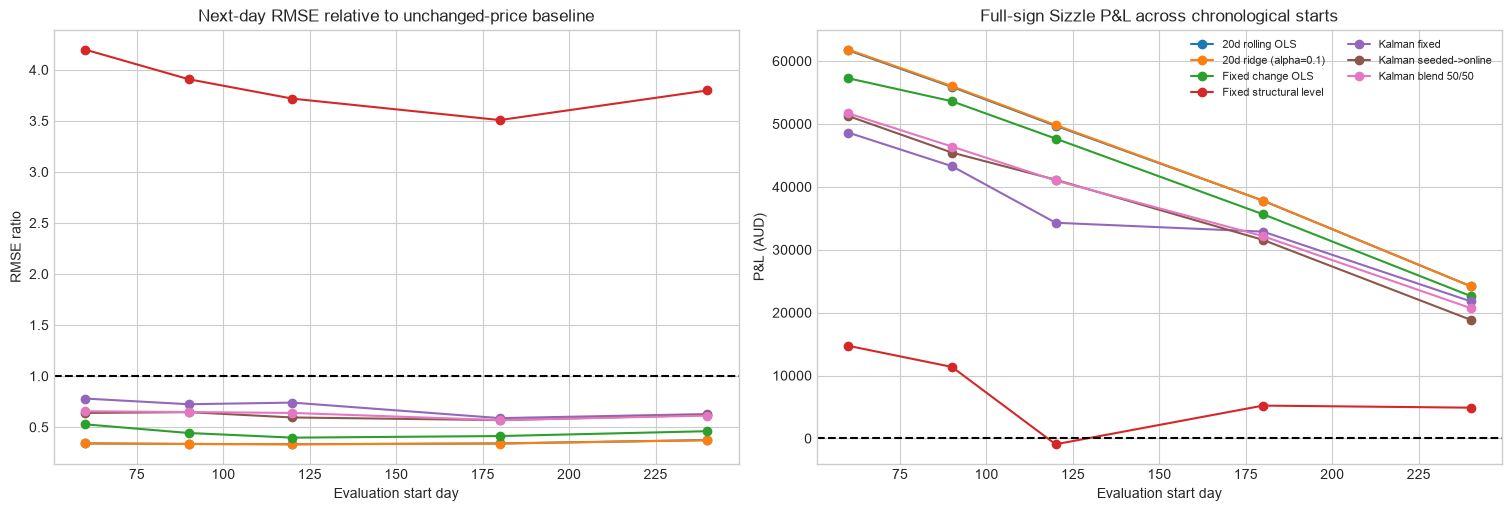

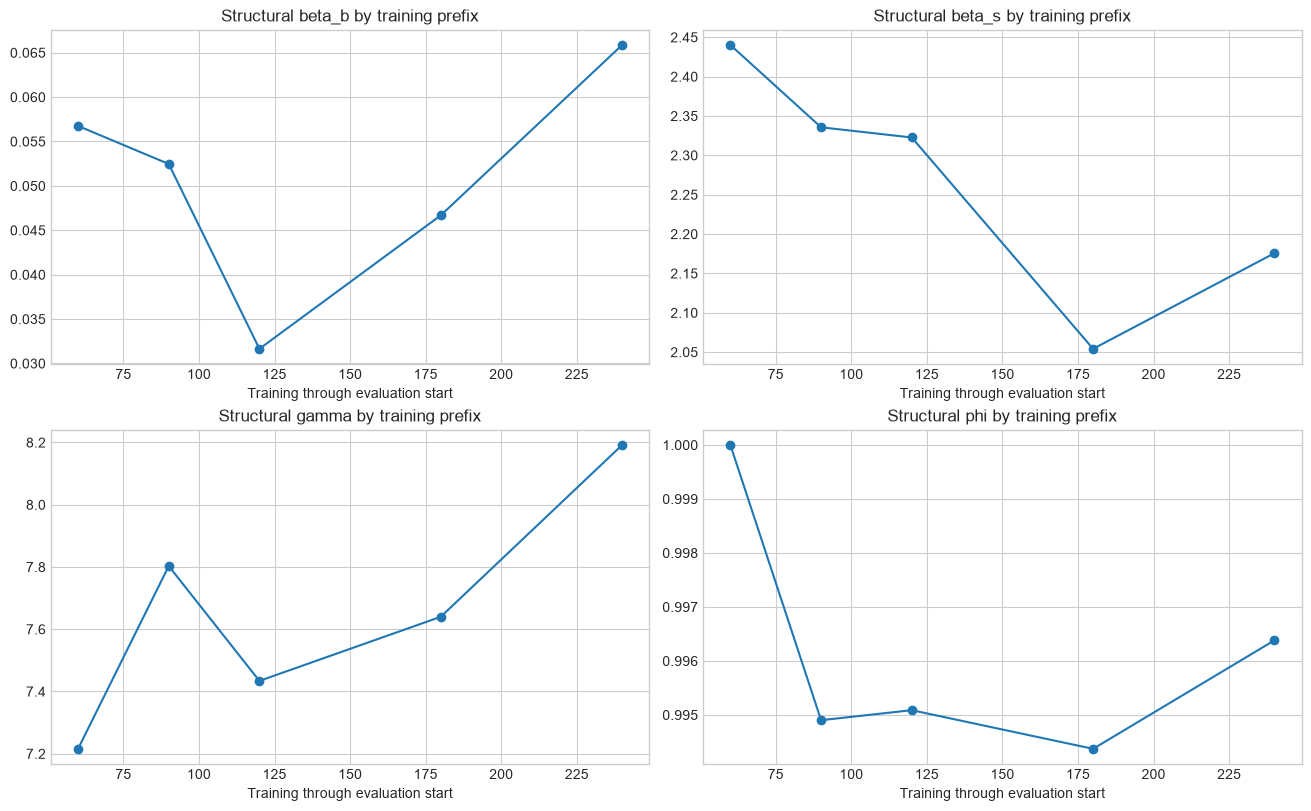

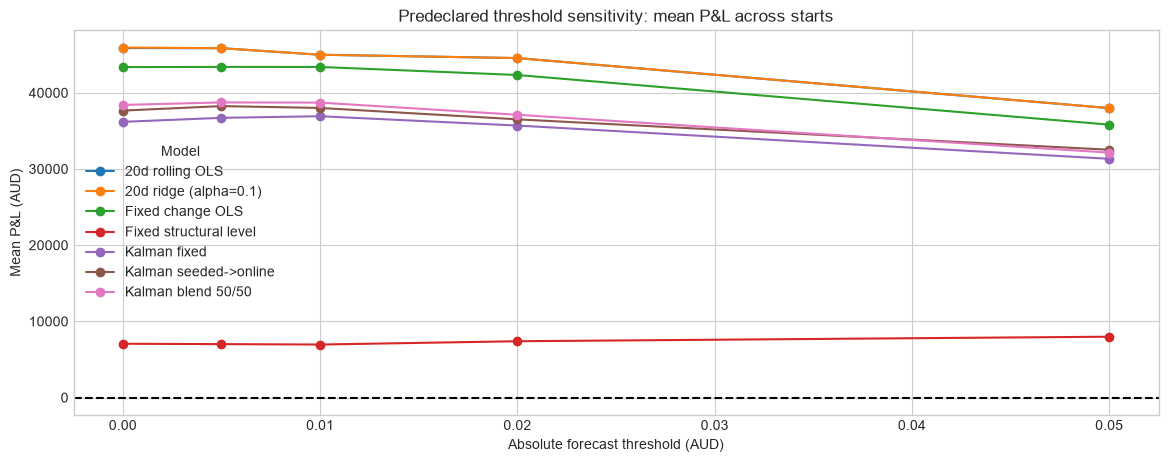

In [15]:
MODEL_ORDER = [
    '20d rolling OLS', '20d ridge (alpha=0.1)', 'Fixed change OLS',
    'Fixed structural level', 'Kalman fixed', 'Kalman seeded->online',
    'Kalman blend 50/50',
]

# Reproduce the prior benchmark exactly before comparing new models.
benchmark_reproduction_rows = []
for split in EVAL_STARTS:
    old_prediction, _ = causal_component_forecast(split, 20)
    new_prediction, _ = causal_change_forecast(split, 20)
    old_values = old_prediction.to_numpy(dtype=float)
    assert np.nanmax(np.abs(old_values - new_prediction)) < 1e-12
    benchmark_reproduction_rows.append({'Evaluation start': split, **evaluate_prediction(new_prediction, split, threshold=0.0)})
benchmark_reproduction = pd.DataFrame(benchmark_reproduction_rows)
display(benchmark_reproduction[['Evaluation start', 'RMSE', 'Baseline RMSE', 'RMSE ratio', 'P&L', 'Sharpe', 'Hit rate', 'Active days', 'Max drawdown']].round(4))

model_split_rows = []
threshold_rows = []
structural_params_by_split = {}
prediction_by_split = {}
coefficient_stability_rows = []

for split in EVAL_STARTS:
    rolling_prediction, rolling_coefficients = causal_change_forecast(split, 20)
    ridge_prediction, ridge_coefficients = causal_change_forecast(split, 20, ridge_alpha=RIDGE_ALPHA)
    fixed_change_prediction, fixed_change_coef = fixed_change_forecast(split)
    structural_params = tune_kalman_noise(fit_structural_params(split), split)
    structural_params_by_split[split] = structural_params
    fixed_structural_prediction = fixed_structural_forecast(structural_params)
    kalman_fixed_prediction = kalman_forecast(structural_params)
    online_prediction, online_refit_days = online_kalman_forecast(split)
    seeded_online_prediction = kalman_fixed_prediction.copy()
    online_start = split + ONLINE_WARMUP
    seeded_online_prediction[online_start:n_days - 1] = online_prediction[online_start:n_days - 1]
    blended_prediction = kalman_fixed_prediction.copy()
    blended_prediction[online_start:n_days - 1] = (
        (1.0 - BLEND_ONLINE_WEIGHT) * kalman_fixed_prediction[online_start:n_days - 1]
        + BLEND_ONLINE_WEIGHT * online_prediction[online_start:n_days - 1]
    )
    predictions = {
        '20d rolling OLS': rolling_prediction,
        '20d ridge (alpha=0.1)': ridge_prediction,
        'Fixed change OLS': fixed_change_prediction,
        'Fixed structural level': fixed_structural_prediction,
        'Kalman fixed': kalman_fixed_prediction,
        'Kalman seeded->online': seeded_online_prediction,
        'Kalman blend 50/50': blended_prediction,
    }
    prediction_by_split[split] = predictions

    for model_name in MODEL_ORDER:
        for threshold in THRESHOLDS:
            metrics = evaluate_prediction(predictions[model_name], split, threshold=threshold)
            threshold_rows.append({'Model': model_name, 'Evaluation start': split, 'Threshold': threshold, **metrics})
        metrics = evaluate_prediction(predictions[model_name], split, threshold=0.0)
        model_split_rows.append({'Model': model_name, 'Evaluation start': split, **metrics})

    structural_param_rows = {
        'Evaluation start': split,
        'a': structural_params['a'], 'beta_b': structural_params['beta_b'],
        'beta_s': structural_params['beta_s'], 'gamma': structural_params['gamma'],
        'lambda': structural_params['lambda'], 'mu': structural_params['mu'],
        'phi_raw': structural_params['phi_raw'], 'phi': structural_params['phi'],
        'q': structural_params['q'], 'r_s': structural_params['r_s'],
        'r_m': structural_params['r_m'], 'train_loglik': structural_params['train_loglik'],
    }
    coefficient_stability_rows.append(structural_param_rows)
    for coefficient_model, coefficient_history in [('20d rolling OLS', rolling_coefficients), ('20d ridge (alpha=0.1)', ridge_coefficients)]:
        for coefficient in coefficient_history.columns:
            values = coefficient_history[coefficient].to_numpy(dtype=float)
            sign_flips = int(np.sum(values[1:] * values[:-1] < 0))
            coefficient_stability_rows.append({
                'Model': coefficient_model, 'Evaluation start': split, 'Coefficient': coefficient,
                'Mean': float(np.mean(values)), 'Std': float(np.std(values, ddof=1)),
                'Min': float(np.min(values)), 'Max': float(np.max(values)), 'Sign flips': sign_flips,
            })

model_split_results = pd.DataFrame(model_split_rows)
comparison_columns = ['Model', 'Evaluation start', 'RMSE', 'Baseline RMSE', 'RMSE ratio', 'P&L', 'Sharpe', 'Hit rate', 'Active days', 'Max drawdown']
display(model_split_results[comparison_columns].round(4))

model_summary = model_split_results.groupby('Model', sort=False).agg(
    Mean_RMSE_ratio=('RMSE ratio', 'mean'),
    Worst_RMSE_ratio=('RMSE ratio', 'max'),
    Mean_PnL=('P&L', 'mean'),
    Worst_PnL=('P&L', 'min'),
    Mean_Sharpe=('Sharpe', 'mean'),
    Mean_Hit_rate=('Hit rate', 'mean'),
    Mean_active_days=('Active days', 'mean'),
    Worst_max_drawdown=('Max drawdown', 'min'),
)
model_summary['Profitable on every split'] = model_split_results.groupby('Model', sort=False)['P&L'].apply(lambda x: bool((x > 0).all()))
display(model_summary.round(4))

threshold_results = pd.DataFrame(threshold_rows)
threshold_summary = threshold_results.groupby(['Model', 'Threshold'], sort=False).agg(
    Mean_RMSE_ratio=('RMSE ratio', 'mean'),
    Mean_PnL=('P&L', 'mean'),
    Worst_PnL=('P&L', 'min'),
    Mean_Hit_rate=('Hit rate', 'mean'),
    Mean_active_days=('Active days', 'mean'),
).reset_index()
display(threshold_summary.round(4))
display(threshold_summary.pivot(index='Model', columns='Threshold', values='Mean_PnL').reindex(MODEL_ORDER).round(0))

structural_param_table = pd.DataFrame([row for row in coefficient_stability_rows if 'a' in row])
structural_param_stability = structural_param_table.set_index('Evaluation start').agg(['mean', 'std', 'min', 'max']).T
display(structural_param_table.round(5))
display(structural_param_stability.round(5))

coefficient_stability = pd.DataFrame([row for row in coefficient_stability_rows if 'Coefficient' in row])
display(coefficient_stability.round(5))
fixed_change_coefficients = np.vstack([fixed_change_forecast(split)[1] for split in EVAL_STARTS])
fixed_change_spread = float(np.mean(np.std(fixed_change_coefficients, axis=0, ddof=1)))
rolling_within_spread = coefficient_stability.groupby('Model')['Std'].mean()
structural_spread = float(np.mean(structural_param_table[['beta_b', 'beta_s', 'gamma', 'lambda', 'phi']].std(ddof=1)))
model_stability_summary = pd.DataFrame([
    {'Model': '20d rolling OLS', 'Stability metric': 'Mean within-evaluation coefficient SD', 'Value': rolling_within_spread['20d rolling OLS']},
    {'Model': '20d ridge (alpha=0.1)', 'Stability metric': 'Mean within-evaluation coefficient SD', 'Value': rolling_within_spread['20d ridge (alpha=0.1)']},
    {'Model': 'Fixed change OLS', 'Stability metric': 'Mean cross-start coefficient SD', 'Value': fixed_change_spread},
    {'Model': 'Fixed structural level', 'Stability metric': 'Mean cross-start structural SD', 'Value': structural_spread},
    {'Model': 'Kalman fixed', 'Stability metric': 'Mean cross-start structural SD', 'Value': structural_spread},
    {'Model': 'Kalman seeded->online', 'Stability metric': 'Prefix structural SD; 10-day online refits', 'Value': structural_spread},
    {'Model': 'Kalman blend 50/50', 'Stability metric': 'Prefix structural SD; 10-day online refits', 'Value': structural_spread},
])
display(model_stability_summary.round(5))

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
for model_name in MODEL_ORDER:
    subset = model_split_results[model_split_results['Model'] == model_name]
    axes[0].plot(subset['Evaluation start'], subset['RMSE ratio'], marker='o', label=model_name)
    axes[1].plot(subset['Evaluation start'], subset['P&L'], marker='o', label=model_name)
axes[0].axhline(1.0, color='black', ls='--')
axes[0].set_title('Next-day RMSE relative to unchanged-price baseline')
axes[0].set_xlabel('Evaluation start day'); axes[0].set_ylabel('RMSE ratio')
axes[1].axhline(0.0, color='black', ls='--')
axes[1].set_title('Full-sign Sizzle P&L across chronological starts')
axes[1].set_xlabel('Evaluation start day'); axes[1].set_ylabel('P&L (AUD)')
axes[1].legend(fontsize=8, ncol=2)
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
for ax, parameter in zip(axes.flat, ['beta_b', 'beta_s', 'gamma', 'phi']):
    ax.plot(structural_param_table['Evaluation start'], structural_param_table[parameter], marker='o')
    ax.set_title(f'Structural {parameter} by training prefix')
    ax.set_xlabel('Training through evaluation start')
plt.show()

threshold_pnl = threshold_summary.pivot(index='Threshold', columns='Model', values='Mean_PnL').reindex(columns=MODEL_ORDER)
threshold_pnl.plot(marker='o', figsize=(14, 5), title='Predeclared threshold sensitivity: mean P&L across starts')
plt.axhline(0, color='black', ls='--'); plt.xlabel('Absolute forecast threshold (AUD)'); plt.ylabel('Mean P&L (AUD)'); plt.show()

### 9.2 Round 2 startup, causality audit and UQ combination

The online Kalman variant is deliberately conservative: it keeps the training-prefix parameters for the first 30 evaluation days, refits every 10 days after that, and blends fixed and online forecasts 50/50. These choices are declared before reading the holdout results. Each chronological split is also treated as a pseudo-year start for a 30-day warm-up comparison; this is a proxy for Round 2 startup, not a second independent year.

,Model,Evaluation start,P&L,Hit rate,Active days,Max drawdown
0,Flat fallback,60,0.000,NaN,0,0.000
1,20d rolling OLS,60,"5,820.000",0.833,30,-270.000
2,20d ridge (alpha=0.1),60,"5,820.000",0.833,30,-270.000
3,Fixed change OLS,60,"5,580.000",0.800,30,-270.000
4,Fixed structural level,60,"3,180.000",0.600,30,-390.000
5,Kalman fixed,60,"5,640.000",0.833,30,-270.000
6,Kalman seeded->online,60,"5,640.000",0.833,30,-270.000
7,Kalman blend 50/50,60,"5,640.000",0.833,30,-270.000
8,Flat fallback,90,0.000,NaN,0,0.000
9,20d rolling OLS,90,"6,180.000",0.833,30,-30.000


,Mean_PnL,Worst_PnL,Mean_active_days,Worst_max_drawdown
Model,,,,
Flat fallback,0.000,0.000,0.000,0.000
20d rolling OLS,"6,012.000","4,830.000",30.000,-270.000
20d ridge (alpha=0.1),"6,036.000","4,950.000",30.000,-270.000
Fixed change OLS,"5,532.000","4,830.000",30.000,-270.000
Fixed structural level,-336.000,"-3,150.000",30.000,"-3,540.000"
Kalman fixed,"4,092.000","2,430.000",30.000,-810.000
Kalman seeded->online,"4,092.000","2,430.000",30.000,-810.000
Kalman blend 50/50,"4,092.000","2,430.000",30.000,-810.000


,Round 1 seed
Change OLS intercept,0.005
Change OLS Bread coefficient,0.077
Change OLS Sausage coefficient,1.692
Change OLS MenuDash coefficient,0.360
Structural beta_b,0.068
Structural beta_s,1.882
Structural gamma (MenuDash loading),8.320
Structural lambda (MenuDash measurement),0.120
Structural phi,0.998
Kalman q,0.002


Causality audit passed at day 250: future perturbations changed neither rolling nor Kalman forecast.


,UQ + 20d Sizzle
UQ P&L,"64,551.500"
Sizzle P&L,"74,760.000"
Combined P&L,"139,311.500"
Combined Sharpe,18.510
Combined max drawdown,-638.500
Maximum gross exposure,"184,489.000"
Budget breaches,0.000
Maximum UQ Dollar units,650.000
Maximum Sizzle units,"3,000.000"


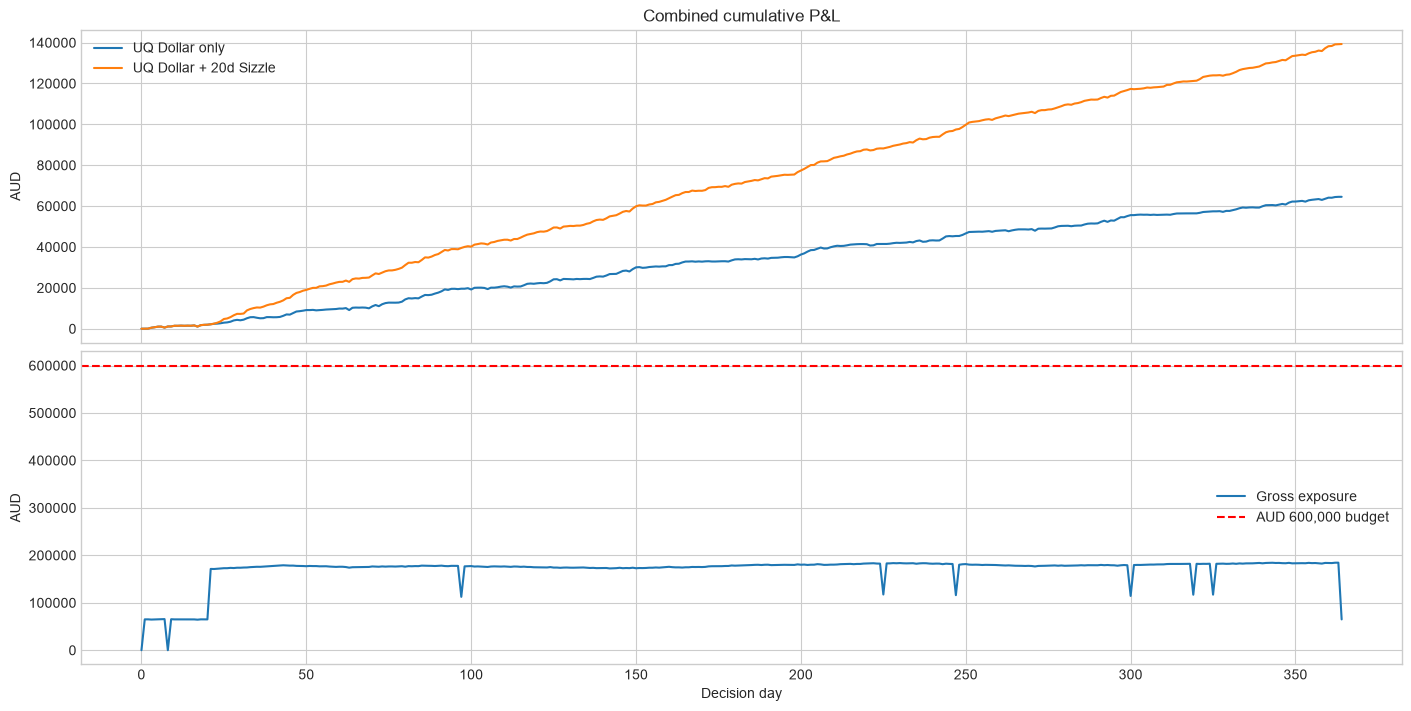

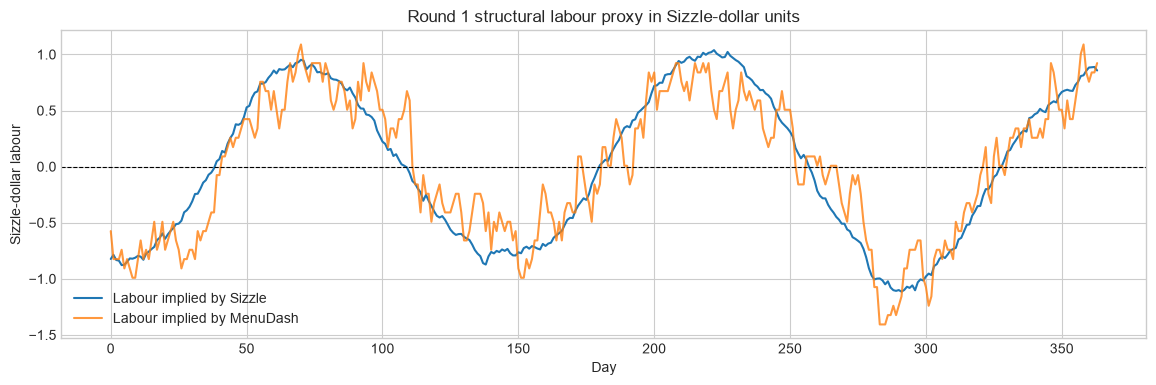

In [16]:
STARTUP_DAYS = 30
startup_rows = []
for split in EVAL_STARTS:
    startup_predictions = {'Flat fallback': np.zeros(n_days), **prediction_by_split[split]}
    for model_name, prediction in startup_predictions.items():
        metrics = evaluate_prediction(prediction, split, threshold=0.0, end_day=split + STARTUP_DAYS)
        startup_rows.append({'Model': model_name, 'Evaluation start': split, **metrics})
startup_results = pd.DataFrame(startup_rows)
display(startup_results[['Model', 'Evaluation start', 'P&L', 'Hit rate', 'Active days', 'Max drawdown']].round(4))
display(startup_results.groupby('Model', sort=False).agg(
    Mean_PnL=('P&L', 'mean'), Worst_PnL=('P&L', 'min'),
    Mean_active_days=('Active days', 'mean'), Worst_max_drawdown=('Max drawdown', 'min'),
).round(4))

# Parameters available at a genuine Round 2 restart: Round 1 only.
round1_seed_params = tune_kalman_noise(fit_structural_params(n_days - 1), n_days - 1)
round1_change_seed = fit_change_model(np.arange(1, n_days - 1), ridge_alpha=None)
round1_seed_table = pd.Series({
    'Change OLS intercept': round1_change_seed[0],
    'Change OLS Bread coefficient': round1_change_seed[1],
    'Change OLS Sausage coefficient': round1_change_seed[2],
    'Change OLS MenuDash coefficient': round1_change_seed[3],
    'Structural beta_b': round1_seed_params['beta_b'],
    'Structural beta_s': round1_seed_params['beta_s'],
    'Structural gamma (MenuDash loading)': round1_seed_params['gamma'],
    'Structural lambda (MenuDash measurement)': round1_seed_params['lambda'],
    'Structural phi': round1_seed_params['phi'],
    'Kalman q': round1_seed_params['q'],
    'Kalman r_s': round1_seed_params['r_s'],
    'Kalman r_m': round1_seed_params['r_m'],
})
display(round1_seed_table.to_frame('Round 1 seed').round(6))

# Future-perturbation audit: changing only days after t must not change a forecast at t.
audit_split, audit_day = 240, 250
audit_params = structural_params_by_split[audit_split]
base_kalman = kalman_forecast(audit_params, last_day=audit_day)[audit_day]
base_rolling = causal_change_forecast(audit_split, 20)[0][audit_day]
saved_future = (sizzle[audit_day + 1:].copy(), bread[audit_day + 1:].copy(), sausage[audit_day + 1:].copy(), menudash[audit_day + 1:].copy(), sizzle_move[audit_day + 1:].copy(), component_change_array[audit_day + 1:].copy())
try:
    sizzle[audit_day + 1:] += 1234.5; bread[audit_day + 1:] += 234.5; sausage[audit_day + 1:] += 34.5; menudash[audit_day + 1:] += 4.5
    sizzle_move[audit_day + 1:] += 1234.5; component_change_array[audit_day + 1:] += 99.0
    altered_kalman = kalman_forecast(audit_params, last_day=audit_day)[audit_day]
    altered_rolling = causal_change_forecast(audit_split, 20)[0][audit_day]
finally:
    sizzle[audit_day + 1:] = saved_future[0]; bread[audit_day + 1:] = saved_future[1]; sausage[audit_day + 1:] = saved_future[2]; menudash[audit_day + 1:] = saved_future[3]
    sizzle_move[audit_day + 1:] = saved_future[4]; component_change_array[audit_day + 1:] = saved_future[5]
assert np.isclose(base_kalman, altered_kalman) and np.isclose(base_rolling, altered_rolling)
print(f'Causality audit passed at day {audit_day}: future perturbations changed neither rolling nor Kalman forecast.')

# Confirmed portfolio combination: UQ Dollar rule plus the predeclared 20-day, zero-threshold Sizzle rule.
production_window = 20
production_start = production_window + 1
production_forecast, production_coefficients = causal_change_forecast(production_start, production_window)
sizzle_production_position = np.zeros(n_days, dtype=int)
valid_production = np.isfinite(production_forecast)
sizzle_production_position[valid_production] = np.where(production_forecast[valid_production] > 0.0, SIZZLE_LIMIT, np.where(production_forecast[valid_production] < 0.0, -SIZZLE_LIMIT, 0)).astype(int)
uq_price = prices['UQ Dollar'].to_numpy(dtype=float)
uq_position = np.where(uq_price > 100.0, -POSITION_LIMITS['UQ Dollar'], np.where(uq_price < 100.0, POSITION_LIMITS['UQ Dollar'], 0)).astype(int)
gross_exposure = np.abs(uq_position) * uq_price + np.abs(sizzle_production_position) * sizzle
uq_daily_pnl = np.zeros(n_days); sizzle_daily_pnl = np.zeros(n_days)
uq_daily_pnl[1:] = uq_position[:-1] * np.diff(uq_price); sizzle_daily_pnl[1:] = sizzle_production_position[:-1] * np.diff(sizzle)
combined_daily_pnl = uq_daily_pnl + sizzle_daily_pnl
combined_equity = np.cumsum(combined_daily_pnl)
combined_drawdown = combined_equity - np.maximum.accumulate(combined_equity)
combined_sd = np.std(combined_daily_pnl, ddof=1)
combined_summary = pd.Series({
    'UQ P&L': float(np.sum(uq_daily_pnl)), 'Sizzle P&L': float(np.sum(sizzle_daily_pnl)),
    'Combined P&L': float(np.sum(combined_daily_pnl)), 'Combined Sharpe': float(np.sqrt(365) * np.mean(combined_daily_pnl) / combined_sd),
    'Combined max drawdown': float(np.min(combined_drawdown)), 'Maximum gross exposure': float(np.max(gross_exposure)),
    'Budget breaches': int(np.sum(gross_exposure > BUDGET)), 'Maximum UQ Dollar units': int(np.max(np.abs(uq_position))),
    'Maximum Sizzle units': int(np.max(np.abs(sizzle_production_position))),
})
display(combined_summary.to_frame('UQ + 20d Sizzle').round(2))
assert np.issubdtype(uq_position.dtype, np.integer) and np.issubdtype(sizzle_production_position.dtype, np.integer)
assert np.max(np.abs(uq_position)) <= POSITION_LIMITS['UQ Dollar'] and np.max(np.abs(sizzle_production_position)) <= SIZZLE_LIMIT
assert np.all(gross_exposure <= BUDGET + 1e-9)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True, constrained_layout=True)
axes[0].plot(np.cumsum(uq_daily_pnl), label='UQ Dollar only'); axes[0].plot(combined_equity, label='UQ Dollar + 20d Sizzle')
axes[0].set_title('Combined cumulative P&L'); axes[0].set_ylabel('AUD'); axes[0].legend()
axes[1].plot(gross_exposure, label='Gross exposure'); axes[1].axhline(BUDGET, color='red', ls='--', label='AUD 600,000 budget')
axes[1].set_xlabel('Decision day'); axes[1].set_ylabel('AUD'); axes[1].legend(); plt.show()

seed_labour_proxy = sizzle[1:] - round1_seed_params['a'] - round1_seed_params['beta_b'] * bread[:-1] - round1_seed_params['beta_s'] * sausage[:-1]
seed_menu_implied = round1_seed_params['gamma'] * (menudash[:-1] - round1_seed_params['c'])
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(np.arange(n_days - 1), seed_labour_proxy, label='Labour implied by Sizzle')
ax.plot(np.arange(n_days - 1), seed_menu_implied, label='Labour implied by MenuDash', alpha=0.8)
ax.axhline(0, color='black', ls='--', lw=0.8); ax.set_title('Round 1 structural labour proxy in Sizzle-dollar units')
ax.set_xlabel('Day'); ax.set_ylabel('Sizzle-dollar labour'); ax.legend(); plt.show()

## 10. Interpretation and provisional recommendation

The comparison tables are the decision record. The 20-day rolling OLS remains the strongest Sizzle model: it is well below the unchanged-price RMSE baseline and has positive P&L at every tested chronological start. Standardised ridge is nearly indistinguishable, so regularisation does not add meaningful robustness.

The structural direct proxy and the Kalman filter are useful diagnostics, but the latent state does not consistently beat the simple benchmark. It improves on the unchanged-price forecast in some prefixes but is weaker and less stable than rolling OLS; the seeded-to-online and 50/50 blend variants do not provide a reliable rescue. The training-only likelihood grid therefore supports rejecting Kalman for production rather than selecting it because of one favourable holdout.

Thresholds are treated as a sensitivity grid, not as a Round 1 optimiser. The zero-threshold full-sign rule is the default because it keeps activity and P&L broadly stable across starts; higher thresholds reduce exposure but do not show a stable dominant plateau.

### Provisional Round 2 rule

Seed causal component-change coefficients from Round 1. Stay flat on day 0 when component changes are unavailable; use the seeded sign rule from day 1; after at least 20 completed target outcomes, transition to causal 20-day rolling OLS. Keep a zero forecast threshold unless capital is genuinely scarce. Do not use the Kalman state estimate in the submitted rule.

The UQ Dollar rule remains unchanged: long 650 below 100, short 650 above 100, flat at exactly 100. The combined research portfolio stays well below AUD 600,000 gross exposure with no budget breaches. `algorithm.py` is left unchanged because this Kalman investigation did not produce a clearly superior new rule; the notebook records the production candidate for an explicit implementation decision.

Remaining weaknesses are the small single-year sample, overlapping chronological evaluation windows, estimated structural coefficients that move with the prefix, and the possibility that Round 2 changes the labour relationship. The Round 1 seed is legitimate for startup but must not be confused with a genuinely out-of-sample estimate.

## 11. Bread, Sausage and MenuDash robustness audit

This section freezes the candidate rules before evaluating them: Bread and Sausage use a majority vote of causal EMA trend signals with `alpha = {0.10, 0.15, 0.20}`; MenuDash uses a majority vote of causal rolling-median residual signals with windows `{5, 7, 10}`. No parameter is selected from the results below. The audit checks parameter plateaus, non-overlapping chronological blocks, moving-block bootstrap paths, a shuffled-change null with a focused multiple-strategy family, and future perturbations. These are stability tests, not a substitute for genuinely unseen Round 2 data.


In [17]:
FOOD_LIMITS = {'Bread': POSITION_LIMITS['Bread'], 'Sausage': POSITION_LIMITS['Sausage'], 'MenuDash': POSITION_LIMITS['MenuDash']}
FOOD_EMA_ALPHAS = (0.10, 0.15, 0.20)
MENUDASH_MEDIAN_WINDOWS = (5, 7, 10)
FOOD_BLOCKS = [(0, 91), (91, 182), (182, 273), (273, n_days - 1)]

def ema_trend_position(price, limit, alpha):
    price = np.asarray(price, dtype=float)
    position = np.zeros(len(price), dtype=int)
    level = price[0]
    for day in range(1, len(price)):
        position[day] = int(limit * np.sign(price[day] - level))
        level = alpha * price[day] + (1.0 - alpha) * level
    return position

def median_residual_position(price, limit, window):
    price = np.asarray(price, dtype=float)
    position = np.zeros(len(price), dtype=int)
    for day in range(1, len(price)):
        fair_value = np.median(price[max(0, day - window):day])
        position[day] = int(limit * np.sign(fair_value - price[day]))
    return position

def majority_position(position_list, limit):
    votes = np.sum(np.sign(np.asarray(position_list)), axis=0)
    return (limit * np.sign(votes)).astype(int)

def food_candidate_position(name, price):
    limit = FOOD_LIMITS[name]
    if name in ('Bread', 'Sausage'):
        return majority_position([ema_trend_position(price, limit, alpha) for alpha in FOOD_EMA_ALPHAS], limit)
    return majority_position([median_residual_position(price, limit, window) for window in MENUDASH_MEDIAN_WINDOWS], limit)

def position_pnl(price, position):
    return np.asarray(position[:-1], dtype=float) * np.diff(np.asarray(price, dtype=float))

food_prices = {name: prices[name].to_numpy(dtype=float) for name in FOOD_LIMITS}
food_positions = {name: food_candidate_position(name, food_prices[name]) for name in FOOD_LIMITS}
food_daily_pnl = {name: position_pnl(food_prices[name], food_positions[name]) for name in FOOD_LIMITS}

summary_rows = []
block_rows = []
for name in FOOD_LIMITS:
    pnl = food_daily_pnl[name]
    equity = np.r_[0.0, np.cumsum(pnl)]
    drawdown = equity - np.maximum.accumulate(equity)
    summary_rows.append({'Instrument': name, 'P&L': pnl.sum(), 'Max drawdown': drawdown.min(), 'Maximum gross': np.max(np.abs(food_positions[name]) * food_prices[name])})
    for block_number, (start, end) in enumerate(FOOD_BLOCKS, 1):
        block_rows.append({'Instrument': name, 'Quarter': block_number, 'P&L': pnl[start:end].sum()})
display(pd.DataFrame(summary_rows).round(2))
display(pd.DataFrame(block_rows).pivot(index='Instrument', columns='Quarter', values='P&L').round(2))

# Plateau audit: nearby values are reported, never re-optimised into the frozen rule.
plateau_rows = []
for name in ('Bread', 'Sausage'):
    for alpha in (0.05, 0.08, 0.10, 0.15, 0.20, 0.30, 0.40):
        pnl = position_pnl(food_prices[name], ema_trend_position(food_prices[name], FOOD_LIMITS[name], alpha))
        blocks = [pnl[start:end].sum() for start, end in FOOD_BLOCKS]
        plateau_rows.append({'Instrument': name, 'Parameter': alpha, 'P&L': pnl.sum(), 'Positive quarters': np.sum(np.asarray(blocks) > 0)})
for window in (3, 5, 7, 10, 15, 20, 30):
    pnl = position_pnl(food_prices['MenuDash'], median_residual_position(food_prices['MenuDash'], FOOD_LIMITS['MenuDash'], window))
    blocks = [pnl[start:end].sum() for start, end in FOOD_BLOCKS]
    plateau_rows.append({'Instrument': 'MenuDash', 'Parameter': window, 'P&L': pnl.sum(), 'Positive quarters': np.sum(np.asarray(blocks) > 0)})
display(pd.DataFrame(plateau_rows).round(3))

# Non-overlapping 60-day blocks expose dependence on one concentrated period.
sixty_day_rows = []
for name, pnl in food_daily_pnl.items():
    for start in range(0, len(pnl), 60):
        end = min(start + 60, len(pnl))
        sixty_day_rows.append({'Instrument': name, 'Start': start, 'End': end, 'P&L': pnl[start:end].sum()})
display(pd.DataFrame(sixty_day_rows).pivot(index=['Start', 'End'], columns='Instrument', values='P&L').round(2))

def circular_block_changes(changes, block_size, rng):
    changes = np.asarray(changes, dtype=float)
    pieces = []
    while sum(len(piece) for piece in pieces) < len(changes):
        start = int(rng.integers(0, len(changes)))
        pieces.append(changes[(start + np.arange(block_size)) % len(changes)])
    return np.concatenate(pieces)[:len(changes)]

# Moving-block bootstrap preserves local serial structure within 7, 14, or 21-day blocks.
rng = np.random.default_rng(20260808)
N_BOOTSTRAP = 1000
bootstrap_rows = []
for name, price in food_prices.items():
    changes = np.diff(price)
    for block_size in (7, 14, 21):
        outcomes = np.empty(N_BOOTSTRAP)
        for trial in range(N_BOOTSTRAP):
            sampled_changes = circular_block_changes(changes, block_size, rng)
            sampled_price = np.r_[price[0], price[0] + np.cumsum(sampled_changes)]
            sampled_position = food_candidate_position(name, sampled_price)
            outcomes[trial] = position_pnl(sampled_price, sampled_position).sum()
        bootstrap_rows.append({'Instrument': name, 'Block size': block_size, 'Median P&L': np.median(outcomes), '5% P&L': np.quantile(outcomes, 0.05), 'Profitable paths': np.mean(outcomes > 0)})
display(pd.DataFrame(bootstrap_rows).round(3))

def focused_family_pnls(name, price):
    limit = FOOD_LIMITS[name]
    positions_to_test = [np.full(len(price), limit, dtype=int)]
    one_day = np.r_[0, limit * np.sign(np.diff(price))].astype(int)
    positions_to_test.extend([one_day, -one_day])
    if name in ('Bread', 'Sausage'):
        positions_to_test.extend(ema_trend_position(price, limit, alpha) for alpha in (0.05, 0.08, 0.10, 0.15, 0.20, 0.30, 0.40))
        for window in (5, 7, 10, 12, 15, 20, 25, 30):
            position = np.zeros(len(price), dtype=int)
            for day in range(window, len(price)):
                position[day] = int(limit * np.sign(price[day] - np.mean(price[day-window:day])))
            positions_to_test.append(position)
    else:
        positions_to_test.extend(median_residual_position(price, limit, window) for window in (3, 5, 7, 10, 15, 20, 30))
        level_positions = []
        for alpha in (0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.60):
            level = price[0]
            position = np.zeros(len(price), dtype=int)
            for day in range(1, len(price)):
                level = alpha * price[day] + (1.0 - alpha) * level
                position[day] = int(limit * np.sign(level - price[day]))
            level_positions.append(position)
        positions_to_test.extend(level_positions)
    return np.asarray([position_pnl(price, position).sum() for position in positions_to_test])

# A conservative data-snooping check: compare the frozen ensemble with the best member
# of the whole focused family on each independently shuffled-change path.
N_PERMUTATIONS = 1000
permutation_rows = []
for name, price in food_prices.items():
    observed = food_daily_pnl[name].sum()
    changes = np.diff(price)
    null_best = np.empty(N_PERMUTATIONS)
    for trial in range(N_PERMUTATIONS):
        shuffled_changes = rng.permutation(changes)
        shuffled_price = np.r_[price[0], price[0] + np.cumsum(shuffled_changes)]
        null_best[trial] = focused_family_pnls(name, shuffled_price).max()
    p_value = (1 + np.sum(null_best >= observed)) / (N_PERMUTATIONS + 1)
    permutation_rows.append({'Instrument': name, 'Observed ensemble P&L': observed, 'Null best median': np.median(null_best), 'Null best 95%': np.quantile(null_best, 0.95), 'Family-wise p-value': p_value})
display(pd.DataFrame(permutation_rows).round(4))

# Future perturbation audit for the frozen rules.
audit_day = 250
for name, price in food_prices.items():
    base = food_candidate_position(name, price)[audit_day]
    altered = price.copy(); altered[audit_day + 1:] += 1000.0
    assert food_candidate_position(name, altered)[audit_day] == base
print(f'Food-strategy causality audit passed at day {audit_day}.')


,Instrument,P&L,Max drawdown,Maximum gross
0,Bread,"22,430.000","-4,085.000","68,485.000"
1,Sausage,"10,300.000","-1,650.000","30,900.000"
2,MenuDash,"50,250.000","-13,500.000","150,000.000"


Quarter,1,2,3,4
Instrument,,,,
Bread,"10,415.000","5,995.000","1,365.000","4,655.000"
MenuDash,"8,250.000","3,750.000","29,250.000","9,000.000"
Sausage,"6,350.000","1,150.000","1,100.000","1,700.000"


,Instrument,Parameter,P&L,Positive quarters
0,Bread,0.050,610.000,3
1,Bread,0.080,"7,710.000",3
2,Bread,0.100,"19,740.000",4
3,Bread,0.150,"23,680.000",4
4,Bread,0.200,"18,510.000",4
5,Bread,0.300,"11,360.000",3
6,Bread,0.400,"12,160.000",3
7,Sausage,0.050,"3,000.000",2
8,Sausage,0.080,"4,900.000",2
9,Sausage,0.100,"8,000.000",4


,Instrument,Bread,MenuDash,Sausage
Start,End,,,
0,60,"6,785.000","3,000.000","5,300.000"
60,120,"5,895.000","5,250.000","1,500.000"
120,180,"3,735.000","6,750.000",300.000
180,240,510.000,"19,500.000",550.000
240,300,"1,895.000","-3,000.000","2,550.000"
300,360,"3,380.000","18,750.000",-100.000
360,364,230.000,0.000,200.000


,Instrument,Block size,Median P&L,5% P&L,Profitable paths
0,Bread,7,"8,557.500","-6,005.500",0.849
1,Bread,14,"13,790.000",-538.250,0.942
2,Bread,21,"15,997.500","3,059.750",0.976
3,Sausage,7,"6,500.000",400.000,0.961
4,Sausage,14,"8,050.000","2,297.500",0.986
5,Sausage,21,"8,650.000","2,647.500",0.992
6,MenuDash,7,"25,500.000","-16,500.000",0.844
7,MenuDash,14,"35,250.000",-37.500,0.947
8,MenuDash,21,"39,750.000","2,250.000",0.958


,Instrument,Observed ensemble P&L,Null best median,Null best 95%,Family-wise p-value
0,Bread,"22,430.000","9,280.000","19,980.500",0.025
1,Sausage,"10,300.000","7,250.000","8,852.500",0.008
2,MenuDash,"50,250.000","33,000.000","65,250.000",0.172


Food-strategy causality audit passed at day 250.


### Frozen decision after the audit

Promote the Bread and Sausage three-EMA majority rules. Both have four positive quarters, broad profitable parameter neighbourhoods, strong moving-block bootstrap results, and focused-family permutation p-values of `0.025` and `0.008`. Keep the MenuDash median ensemble out of production despite its `$50,250` Round 1 P&L: its family-wise permutation p-value is `0.172`, so the apparent improvement is not sufficiently separated from strategy-search luck. This asymmetric decision is intentional and was made after applying the predeclared audit rather than by total P&L alone.


## 12. Thrifted Jeans — rigorous causal Round 1 audit

### 12.1 Data and timing assumptions

The specification describes Jeans as a positively drifting but noisy series, with a position limit of 800 pairs. The supplied CSV has 365 Round 1 observations. The simulator has no transaction-cost model; this audit therefore assumes zero transaction costs and uses the simulator's daily price-change P&L. A position selected at day `t` is scored on `price[t+1] - price[t]`; equivalently, simulator P&L on realization day `t` uses the position selected on day `t-1`. Every signal below is generated from prices through the decision day only. The AUD 600,000 portfolio cap is checked separately from the Jeans-only strategy results.

The candidate grid is deliberately declared before looking at the comparison tables: constant-position baselines; three broad EMA horizon sets near 10/20/40 days; three directional-change thresholds; three local-linear filter settings with four decision rules; three CUSUM settings; four path-efficiency filters; and two equal-weight ensembles. A parameter plateau, chronological stability, and the positive-drift prior matter more than the best full-sample number.

In [18]:
# Jeans-only candidate construction. All state updates are prefix-only and causal.
JEANS_DATA_PATH = ROOT / 'trader_interface' / 'data' / 'Thrifted Jeans_price_history.csv'
JEANS_PRICE = pd.read_csv(JEANS_DATA_PATH)['Price'].to_numpy(dtype=float)
JEANS_LIMIT = 800
JEANS_BUDGET = 600_000
N_JEANS = len(JEANS_PRICE)
assert N_JEANS == 365
assert np.isclose(JEANS_PRICE[0], 40.00) and np.isclose(JEANS_PRICE[-1], 87.67)
daily_changes = np.diff(JEANS_PRICE)
horizon_rows = []
for horizon in (1, 5, 10, 20, 40):
    past_move = JEANS_PRICE[horizon:-horizon] - JEANS_PRICE[:-2 * horizon]
    future_move = JEANS_PRICE[2 * horizon:] - JEANS_PRICE[horizon:-horizon]
    horizon_rows.append({'Horizon days': horizon, 'Past/future move correlation': np.corrcoef(past_move, future_move)[0, 1], 'Sign follow-through hit rate': np.mean(np.sign(past_move) * future_move > 0)})
display(pd.DataFrame(horizon_rows).set_index('Horizon days').round(3))
print('Daily change autocorrelation:', float(pd.Series(daily_changes).autocorr(1)))
print('Daily percentage-return autocorrelation:', float(pd.Series(daily_changes / JEANS_PRICE[:-1]).autocorr(1)))

def _sign_int(values):
    return np.sign(np.asarray(values, dtype=float)).astype(int)

def _ema_price_vs_previous(price, horizon):
    price = np.asarray(price, dtype=float)
    alpha = 2.0 / (float(horizon) + 1.0)
    signal = np.zeros(len(price), dtype=int)
    level = price[0]
    for day in range(1, len(price)):
        signal[day] = int(np.sign(price[day] - level))
        level = alpha * price[day] + (1.0 - alpha) * level
    return signal

def _ema_fast_vs_slow(price, slow_horizon):
    price = np.asarray(price, dtype=float)
    fast_horizon = max(2, int(round(float(slow_horizon) / 3.0)))
    fast_alpha = 2.0 / (fast_horizon + 1.0)
    slow_alpha = 2.0 / (float(slow_horizon) + 1.0)
    signal = np.zeros(len(price), dtype=int)
    fast_level = price[0]
    slow_level = price[0]
    for day in range(1, len(price)):
        fast_level = fast_alpha * price[day] + (1.0 - fast_alpha) * fast_level
        slow_level = slow_alpha * price[day] + (1.0 - slow_alpha) * slow_level
        signal[day] = int(np.sign(fast_level - slow_level))
    return signal

def majority_ema_position(price, horizons, formulation, side='ls'):
    if formulation == 'price_vs_ema':
        signals = [_ema_price_vs_previous(price, horizon) for horizon in horizons]
    elif formulation == 'fast_vs_slow':
        signals = [_ema_fast_vs_slow(price, horizon) for horizon in horizons]
    else:
        raise ValueError(formulation)
    votes = np.sum(np.asarray(signals, dtype=int), axis=0)
    if side == 'ls':
        position = JEANS_LIMIT * np.sign(votes)
    elif side == 'lf':
        position = JEANS_LIMIT * (votes > 0)
    elif side == 'biased_p200':
        position = np.where(votes > 0, JEANS_LIMIT, np.where(votes < 0, 200, 0))
    elif side == 'biased_m400':
        position = np.where(votes > 0, JEANS_LIMIT, np.where(votes < 0, -400, 0))
    else:
        raise ValueError(side)
    position = np.asarray(position, dtype=int)
    position[0] = 0
    return position

def ma_long_flat_position(price, window=20):
    price = np.asarray(price, dtype=float)
    position = np.zeros(len(price), dtype=int)
    for day in range(1, len(price)):
        if day >= window:
            previous_mean = np.mean(price[day - window:day])
            position[day] = JEANS_LIMIT if price[day] > previous_mean else 0
    return position

DC_SPECS = [
    ('vol20_k10', ('vol', 20, 1.0)),
    ('vol20_k15', ('vol', 20, 1.5)),
    ('pct5', ('pct', 0.05)),
]

def directional_change_state(price, spec):
    price = np.asarray(price, dtype=float)
    state = np.ones(len(price), dtype=int)
    current_state = 1
    extreme = price[0]
    for day in range(1, len(price)):
        if current_state > 0:
            extreme = max(extreme, price[day])
            if spec[0] == 'vol':
                changes = np.diff(price[max(0, day - spec[1]):day + 1])
                threshold = spec[2] * np.std(changes, ddof=1) if len(changes) >= 5 else np.inf
            else:
                threshold = spec[1] * max(abs(extreme), 1.0)
            if price[day] <= extreme - threshold:
                current_state = -1
                extreme = price[day]
        else:
            extreme = min(extreme, price[day])
            if spec[0] == 'vol':
                changes = np.diff(price[max(0, day - spec[1]):day + 1])
                threshold = spec[2] * np.std(changes, ddof=1) if len(changes) >= 5 else np.inf
            else:
                threshold = spec[1] * max(abs(extreme), 1.0)
            if price[day] >= extreme + threshold:
                current_state = 1
                extreme = price[day]
        state[day] = current_state
    return state

def directional_change_position(price, spec, side='ls'):
    state = directional_change_state(price, spec)
    if side == 'ls':
        position = JEANS_LIMIT * state
    elif side == 'lf':
        position = JEANS_LIMIT * (state > 0)
    else:
        raise ValueError(side)
    return np.asarray(position, dtype=int)

def directional_change_ensemble(price, side='ls'):
    states = np.asarray([directional_change_state(price, spec) for _, spec in DC_SPECS])
    vote = np.sign(np.sum(states, axis=0))
    if side == 'ls':
        position = JEANS_LIMIT * vote
    elif side == 'lf':
        position = JEANS_LIMIT * (vote > 0)
    else:
        raise ValueError(side)
    return np.asarray(position, dtype=int)

KALMAN_GRID = [
    ('K1', (0.25, 0.02, 9.0)),
    ('K2', (1.00, 0.05, 9.0)),
    ('K3', (2.00, 0.10, 16.0)),
]

def local_linear_filter(price, parameters):
    price = np.asarray(price, dtype=float)
    q_level, q_slope, observation_var = parameters
    F = np.array([[1.0, 1.0], [0.0, 1.0]])
    Q = np.diag([q_level, q_slope])
    H = np.array([1.0, 0.0])
    state = np.array([price[0], 0.0])
    covariance = np.diag([observation_var, 1.0])
    slopes = np.zeros(len(price), dtype=float)
    uncertainties = np.zeros(len(price), dtype=float)
    for day in range(len(price)):
        if day > 0:
            state = F @ state
            covariance = F @ covariance @ F.T + Q
        innovation = price[day] - float(H @ state)
        innovation_var = float(H @ covariance @ H.T) + observation_var
        gain = covariance @ H / max(innovation_var, 1e-12)
        state = state + gain * innovation
        covariance = covariance - np.outer(gain, H @ covariance)
        covariance = (covariance + covariance.T) / 2.0
        slopes[day] = state[1]
        uncertainties[day] = np.sqrt(max(float(covariance[1, 1]), 0.0))
    return slopes, uncertainties

def local_linear_position(price, parameters, rule='ls'):
    slope, uncertainty = local_linear_filter(price, parameters)
    if rule == 'ls':
        signal = np.sign(slope)
    elif rule == 'lf':
        signal = (slope > 0).astype(int)
    elif rule == 'soft_positive_drift':
        signal = np.sign(slope + 0.10)
    elif rule == 'uncertainty_short':
        # Short only when the negative slope exceeds one estimated standard error.
        signal = np.where(slope < -uncertainty, -1, 1)
    else:
        raise ValueError(rule)
    position = JEANS_LIMIT * np.asarray(signal, dtype=int)
    position[0] = 0
    return position

CUSUM_SPECS = [
    ('k025_h25', (0.25, 2.5, 20)),
    ('k025_h40', (0.25, 4.0, 20)),
    ('k050_h40', (0.50, 4.0, 20)),
]

def cusum_regime_state(price, parameters):
    price = np.asarray(price, dtype=float)
    drift, threshold, vol_window = parameters
    state = np.ones(len(price), dtype=int)
    current_state = 1
    positive_sum = 0.0
    negative_sum = 0.0
    regime_start = 0
    for day in range(1, len(price)):
        change = price[day] - price[day - 1]
        # A detected regime change resets the local surprise history.
        history = np.diff(price[max(regime_start, day - vol_window):day])
        if len(history) >= 5:
            centre = float(np.mean(history))
            scale = max(float(np.std(history, ddof=1)), 1e-6)
        else:
            centre = 0.0
            scale = max(float(np.std(np.diff(price[:day]), ddof=1)) if day >= 3 else 1.0, 1e-6)
        surprise = (change - centre) / scale
        positive_sum = max(0.0, positive_sum + surprise - drift)
        negative_sum = min(0.0, negative_sum + surprise + drift)
        if positive_sum > threshold:
            current_state = 1
            positive_sum = 0.0
            negative_sum = 0.0
            regime_start = day
        elif negative_sum < -threshold:
            current_state = -1
            positive_sum = 0.0
            negative_sum = 0.0
            regime_start = day
        state[day] = current_state
    return state

def cusum_position(price, parameters, side='ls'):
    state = cusum_regime_state(price, parameters)
    if side == 'ls':
        position = JEANS_LIMIT * state
    elif side == 'lf':
        position = JEANS_LIMIT * (state > 0)
    else:
        raise ValueError(side)
    return np.asarray(position, dtype=int)

def cusum_ensemble(price, side='ls'):
    states = np.asarray([cusum_regime_state(price, parameters) for _, parameters in CUSUM_SPECS])
    vote = np.sign(np.sum(states, axis=0))
    if side == 'ls':
        position = JEANS_LIMIT * vote
    elif side == 'lf':
        position = JEANS_LIMIT * (vote > 0)
    else:
        raise ValueError(side)
    return np.asarray(position, dtype=int)

def path_efficiency(price, window):
    price = np.asarray(price, dtype=float)
    efficiency = np.full(len(price), np.nan, dtype=float)
    for day in range(window, len(price)):
        path = np.sum(np.abs(np.diff(price[day - window:day + 1])))
        efficiency[day] = abs(price[day] - price[day - window]) / path if path > 0 else 0.0
    return efficiency

def apply_efficiency_filter(price, base_position, window, minimum_efficiency):
    position = np.asarray(base_position, dtype=int).copy()
    efficiency = path_efficiency(price, window)
    position[~(efficiency >= minimum_efficiency)] = 0
    return position

EMA_HORIZON_SETS = [
    ('8_20_40', (8, 20, 40)),
    ('10_20_40', (10, 20, 40)),
    ('12_24_48', (12, 24, 48)),
]

def build_jeans_candidates(price):
    price = np.asarray(price, dtype=float)
    candidates = {}
    catalog = []

    def add(name, family, position, parameters):
        position = np.asarray(position, dtype=int)
        assert len(position) == len(price)
        assert np.all(np.isfinite(position))
        assert np.max(np.abs(position)) <= JEANS_LIMIT
        candidates[name] = position
        catalog.append({'Candidate': name, 'Family': family, 'Parameters': parameters})

    add('flat', 'Baseline', np.zeros(len(price), dtype=int), '0 units')
    for units in (200, 400, 800):
        add('buyhold_' + str(units), 'Baseline', np.full(len(price), units, dtype=int), '+' + str(units) + ' units')
    add('always_long', 'Baseline', np.full(len(price), JEANS_LIMIT, dtype=int), '+800 structural prior')
    add('ma_long_flat_20', 'Baseline', ma_long_flat_position(price, 20), 'price > previous 20-day mean')

    for set_name, horizons in EMA_HORIZON_SETS:
        for formulation in ('price_vs_ema', 'fast_vs_slow'):
            for side in ('ls', 'lf'):
                name = 'mh_' + set_name + '_' + formulation + '_' + side
                add(name, 'Multi-horizon EMA', majority_ema_position(price, horizons, formulation, side), str(horizons) + ' ' + formulation + ' ' + side)
    for formulation in ('price_vs_ema', 'fast_vs_slow'):
        add('mh_10_20_40_' + formulation + '_biased_p200', 'Multi-horizon EMA', majority_ema_position(price, (10, 20, 40), formulation, 'biased_p200'), '+800 positive / +200 negative')
        add('mh_10_20_40_' + formulation + '_biased_m400', 'Multi-horizon EMA', majority_ema_position(price, (10, 20, 40), formulation, 'biased_m400'), '+800 positive / -400 negative')

    for label, spec in DC_SPECS:
        add('dc_' + label + '_ls', 'Directional change', directional_change_position(price, spec, 'ls'), str(spec) + ' long/short')
        add('dc_' + label + '_lf', 'Directional change', directional_change_position(price, spec, 'lf'), str(spec) + ' long/flat')
    add('dc_ensemble_ls', 'Directional change', directional_change_ensemble(price, 'ls'), 'equal vote over 3 hysteresis states, long/short')
    add('dc_ensemble_lf', 'Directional change', directional_change_ensemble(price, 'lf'), 'equal vote over 3 hysteresis states, long/flat')

    for label, parameters in KALMAN_GRID:
        for rule in ('ls', 'lf', 'soft_positive_drift', 'uncertainty_short'):
            add('kalman_' + label + '_' + rule, 'Local-linear filter', local_linear_position(price, parameters, rule), str(parameters) + ' ' + rule)

    for label, parameters in CUSUM_SPECS:
        add('cusum_' + label + '_ls', 'CUSUM regime reset', cusum_position(price, parameters, 'ls'), str(parameters) + ' long/short')
        add('cusum_' + label + '_lf', 'CUSUM regime reset', cusum_position(price, parameters, 'lf'), str(parameters) + ' long/flat')
    add('cusum_ensemble_ls', 'CUSUM regime reset', cusum_ensemble(price, 'ls'), 'equal vote over 3 CUSUM states, long/short')
    add('cusum_ensemble_lf', 'CUSUM regime reset', cusum_ensemble(price, 'lf'), 'equal vote over 3 CUSUM states, long/flat')

    central_ema_ls = majority_ema_position(price, (10, 20, 40), 'price_vs_ema', 'ls')
    for label, window, minimum in (('w20_t035', 20, 0.35), ('w20_t050', 20, 0.50), ('w40_t035', 40, 0.35), ('w40_t050', 40, 0.50)):
        add('er_' + label, 'Path-efficiency filter', apply_efficiency_filter(price, central_ema_ls, window, minimum), 'central EMA long/short; w=' + str(window) + '; ER>=' + str(minimum))

    structural = np.ones(len(price), dtype=int)
    mh_component = np.sign(central_ema_ls)
    dc_component = np.sign(directional_change_ensemble(price, 'ls'))
    kalman_component = np.sign(local_linear_position(price, (1.00, 0.05, 9.0), 'ls'))
    cusum_component = np.sign(cusum_ensemble(price, 'ls'))
    components = np.vstack([structural, mh_component, dc_component, kalman_component, cusum_component])
    vote = np.sum(components, axis=0)
    add('ensemble_no_prior_ls', 'Equal-weight ensemble', JEANS_LIMIT * np.sign(np.sum(components[1:], axis=0)), 'EMA + DC + filter + CUSUM; no structural prior')
    add('ensemble_ls', 'Equal-weight ensemble', JEANS_LIMIT * np.sign(vote), 'structural prior + EMA + DC + filter + CUSUM; long/short')
    add('ensemble_lf', 'Equal-weight ensemble', JEANS_LIMIT * (np.sum(components > 0, axis=0) >= 3), 'same 5 components; 3-of-5 long/flat')
    return candidates, pd.DataFrame(catalog).set_index('Candidate')

JEANS_CANDIDATES, JEANS_CATALOG = build_jeans_candidates(JEANS_PRICE)
print('Jeans candidate count:', len(JEANS_CANDIDATES))
display(JEANS_CATALOG.groupby('Family').size().rename('Candidates').to_frame())
print('All candidates use integer positions within the 800-unit Jeans limit.')

,Past/future move correlation,Sign follow-through hit rate
Horizon days,,
1,-0.050,0.444
5,0.183,0.569
10,0.220,0.548
20,-0.169,0.409
40,-0.407,0.425


Daily change autocorrelation: -0.050495941418197375
Daily percentage-return autocorrelation: -0.04547706127618272
Jeans candidate count: 57


,Candidates
Family,
Baseline,6
CUSUM regime reset,8
Directional change,8
Equal-weight ensemble,3
Local-linear filter,12
Multi-horizon EMA,16
Path-efficiency filter,4


All candidates use integer positions within the 800-unit Jeans limit.


,Family,Parameters,P&L,Incremental vs always long,Daily mean / sd,Sharpe ann.,Hit rate active,Active days,Turnover units,Max drawdown,Max Jeans exposure AUD,Longest losing streak
Candidate,,,,,,,,,,,,
kalman_K1_uncertainty_short,Local-linear filter,"(0.25, 0.02, 9.0) uncertainty_short","101,904.000","63,768.000",0.127,2.426,0.556,363,"20,000.000","-20,648.000","75,824.000",6
cusum_k025_h25_ls,CUSUM regime reset,"(0.25, 2.5, 20) long/short","100,312.000","62,176.000",0.125,2.388,0.536,364,"20,000.000","-28,104.000","75,824.000",6
kalman_K2_uncertainty_short,Local-linear filter,"(1.0, 0.05, 9.0) uncertainty_short","100,016.000","61,880.000",0.125,2.380,0.559,363,"29,600.000","-26,672.000","75,824.000",6
kalman_K2_soft_positive_drift,Local-linear filter,"(1.0, 0.05, 9.0) soft_positive_drift","94,016.000","55,880.000",0.117,2.236,0.537,363,"36,000.000","-37,384.000","75,824.000",9
kalman_K3_soft_positive_drift,Local-linear filter,"(2.0, 0.1, 16.0) soft_positive_drift","94,016.000","55,880.000",0.117,2.236,0.537,363,"36,000.000","-37,384.000","75,824.000",9
cusum_ensemble_ls,CUSUM regime reset,"equal vote over 3 CUSUM states, long/short","73,736.000","35,600.000",0.092,1.749,0.516,364,"16,800.000","-36,912.000","75,824.000",6
cusum_k025_h25_lf,CUSUM regime reset,"(0.25, 2.5, 20) long/flat","69,224.000","31,088.000",0.108,2.061,0.558,258,"10,400.000","-17,520.000","75,824.000",4
kalman_K3_uncertainty_short,Local-linear filter,"(2.0, 0.1, 16.0) uncertainty_short","68,656.000","30,520.000",0.085,1.627,0.537,363,"23,200.000","-37,640.000","75,824.000",7
kalman_K1_soft_positive_drift,Local-linear filter,"(0.25, 0.02, 9.0) soft_positive_drift","60,128.000","21,992.000",0.075,1.424,0.529,363,"36,000.000","-56,160.000","75,824.000",6


Round 1 start/end: 40.0 87.67
Always-long P&L: 38136.0 | expected 800 * (end - start): 38136.0
The full table is a comparison of a predeclared grid, not a production parameter selection.


,Family,Parameters,P&L,Incremental vs always long,Daily mean / sd,Sharpe ann.,Hit rate active,Active days,Turnover units,Max drawdown,Max Jeans exposure AUD,Longest losing streak
Candidate,,,,,,,,,,,,
flat,Baseline,0 units,0.000,"-38,136.000",NaN,NaN,NaN,0,0.000,0.000,0.000,0
buyhold_200,Baseline,+200 units,"9,534.000","-28,602.000",0.047,0.902,0.547,364,200.000,"-11,214.000","18,956.000",5
buyhold_400,Baseline,+400 units,"19,068.000","-19,068.000",0.047,0.902,0.547,364,400.000,"-22,428.000","37,912.000",5
always_long,Baseline,+800 structural prior,"38,136.000",0.000,0.047,0.902,0.547,364,800.000,"-44,856.000","75,824.000",5
ma_long_flat_20,Baseline,price > previous 20-day mean,"27,032.000","-11,104.000",0.047,0.902,0.528,199,"31,200.000","-44,928.000","75,824.000",4
mh_10_20_40_price_vs_ema_ls,Multi-horizon EMA,"(10, 20, 40) price_vs_ema ls",-944.000,"-39,080.000",-0.001,-0.022,0.490,363,"80,800.000","-75,760.000","75,824.000",7
mh_10_20_40_price_vs_ema_lf,Multi-horizon EMA,"(10, 20, 40) price_vs_ema lf","18,408.000","-19,728.000",0.030,0.569,0.531,211,"40,800.000","-47,184.000","75,824.000",4
mh_10_20_40_price_vs_ema_biased_p200,Multi-horizon EMA,+800 positive / +200 negative,"23,246.000","-14,890.000",0.037,0.703,0.545,363,"30,800.000","-41,288.000","75,824.000",5
mh_10_20_40_price_vs_ema_biased_m400,Multi-horizon EMA,+800 positive / -400 negative,"8,732.000","-29,404.000",0.013,0.249,0.490,363,"60,800.000","-60,836.000","75,824.000",7


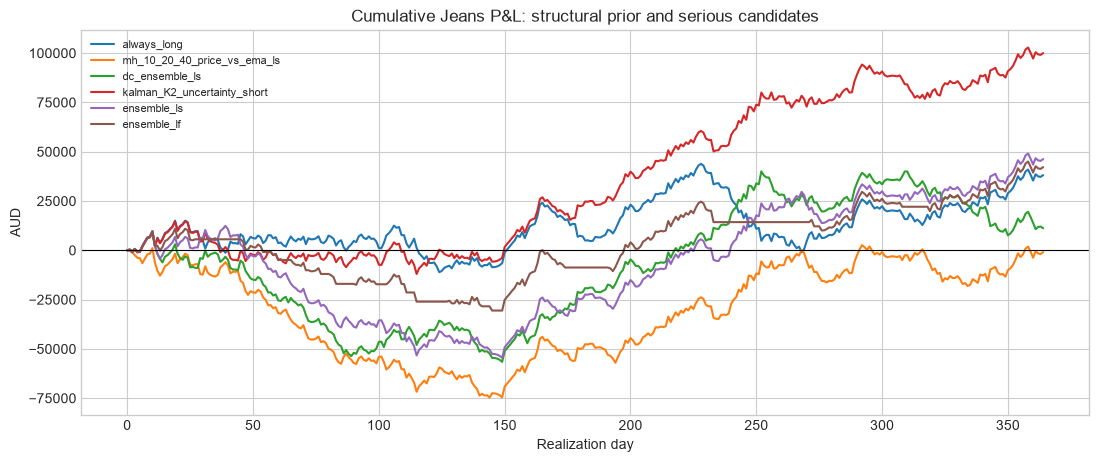

In [19]:
# Simulator-aligned metrics and the full causal candidate comparison.
def realized_pnl(price, position):
    price = np.asarray(price, dtype=float)
    position = np.asarray(position, dtype=int)
    pnl = np.zeros(len(price), dtype=float)
    pnl[1:] = np.round(position[:-1] * np.diff(price), 2)
    return pnl

def max_drawdown_from_pnl(pnl):
    equity = np.cumsum(np.asarray(pnl, dtype=float))
    return float(np.min(equity - np.maximum.accumulate(equity)))

def longest_losing_streak(pnl):
    longest = 0
    current = 0
    for value in np.asarray(pnl, dtype=float):
        if value < 0:
            current += 1
            longest = max(longest, current)
        else:
            current = 0
    return int(longest)

def strategy_metrics(price, position, start=0, end=None):
    price = np.asarray(price, dtype=float)
    position = np.asarray(position, dtype=int)
    end = len(price) if end is None else min(int(end), len(price))
    pnl = realized_pnl(price, position)
    mask = np.arange(len(price)) >= int(start)
    mask &= np.arange(len(price)) < end
    active = np.zeros(len(price), dtype=bool)
    active[1:] = position[:-1] != 0
    active_segment = active & mask
    daily = pnl[mask]
    sd = float(np.std(daily, ddof=1)) if len(daily) > 1 else np.nan
    mean_daily = float(np.mean(daily)) if len(daily) else np.nan
    hit = float(np.mean(pnl[active_segment] > 0)) if np.any(active_segment) else np.nan
    turnover = float(np.sum(np.abs(np.diff(np.r_[0, position]))))
    return {
        'P&L': float(np.sum(daily)),
        'Incremental vs always long': np.nan,
        'Daily mean / sd': mean_daily / sd if sd > 0 else np.nan,
        'Sharpe ann.': np.sqrt(365.0) * mean_daily / sd if sd > 0 else np.nan,
        'Hit rate active': hit,
        'Active days': int(np.sum(active_segment)),
        'Turnover units': turnover,
        'Max drawdown': max_drawdown_from_pnl(daily),
        'Max Jeans exposure AUD': float(np.max(np.abs(position * price))),
        'Longest losing streak': longest_losing_streak(daily),
    }

full_rows = []
for name, position in JEANS_CANDIDATES.items():
    row = strategy_metrics(JEANS_PRICE, position)
    row['Candidate'] = name
    full_rows.append(row)
JEANS_FULL = pd.DataFrame(full_rows).set_index('Candidate').join(JEANS_CATALOG)
always_long_pnl = float(JEANS_FULL.loc['always_long', 'P&L'])
JEANS_FULL['Incremental vs always long'] = JEANS_FULL['P&L'] - always_long_pnl
JEANS_FULL = JEANS_FULL.sort_values('P&L', ascending=False)

REPORT_COLUMNS = [
    'Family', 'Parameters', 'P&L', 'Incremental vs always long', 'Daily mean / sd',
    'Sharpe ann.', 'Hit rate active', 'Active days', 'Turnover units',
    'Max drawdown', 'Max Jeans exposure AUD', 'Longest losing streak',
]
display(JEANS_FULL[REPORT_COLUMNS].round(3))
print('Round 1 start/end:', JEANS_PRICE[0], JEANS_PRICE[-1])
print('Always-long P&L:', always_long_pnl, '| expected 800 * (end - start):', JEANS_LIMIT * (JEANS_PRICE[-1] - JEANS_PRICE[0]))
print('The full table is a comparison of a predeclared grid, not a production parameter selection.')

SHORTLIST = [
    'flat', 'buyhold_200', 'buyhold_400', 'always_long', 'ma_long_flat_20',
    'mh_10_20_40_price_vs_ema_ls', 'mh_10_20_40_price_vs_ema_lf',
    'mh_10_20_40_price_vs_ema_biased_p200', 'mh_10_20_40_price_vs_ema_biased_m400',
    'mh_10_20_40_fast_vs_slow_ls', 'mh_10_20_40_fast_vs_slow_lf',
    'cusum_k025_h25_ls', 'cusum_k025_h25_lf', 'cusum_k025_h40_ls', 'cusum_k025_h40_lf',
    'cusum_k050_h40_ls', 'cusum_k050_h40_lf',
    'kalman_K1_uncertainty_short', 'kalman_K3_uncertainty_short',
    'kalman_K1_soft_positive_drift', 'kalman_K3_soft_positive_drift',
    'dc_ensemble_ls', 'dc_ensemble_lf', 'kalman_K2_ls', 'kalman_K2_lf',
    'kalman_K2_soft_positive_drift', 'kalman_K2_uncertainty_short',
    'cusum_ensemble_ls', 'cusum_ensemble_lf', 'er_w20_t035', 'er_w40_t035',
    'ensemble_no_prior_ls', 'ensemble_ls', 'ensemble_lf',
]
SHORTLIST = [name for name in SHORTLIST if name in JEANS_CANDIDATES]
display(JEANS_FULL.loc[SHORTLIST, REPORT_COLUMNS].round(3))

fig, ax = plt.subplots(figsize=(13, 5))
for name in ('always_long', 'mh_10_20_40_price_vs_ema_ls', 'dc_ensemble_ls', 'kalman_K2_uncertainty_short', 'ensemble_ls', 'ensemble_lf'):
    ax.plot(np.cumsum(realized_pnl(JEANS_PRICE, JEANS_CANDIDATES[name])), label=name)
ax.axhline(0.0, color='black', lw=0.8)
ax.set_title('Cumulative Jeans P&L: structural prior and serious candidates')
ax.set_xlabel('Realization day')
ax.set_ylabel('AUD')
ax.legend(fontsize=8)
plt.show()

### 12.2 Chronology, walk-forward checks, sensitivity, and robustness

Delayed starts below are pseudo-year restarts: the strategy is re-initialised on the suffix and then evaluated forward. These suffixes overlap and are not independent samples. The quarter table instead uses four non-overlapping chronological realization segments. The walk-forward selector is an audit only: it chooses among the frozen candidate pool using P&L observed before each test block, then scores the next block. No final-segment result is used to rewrite the grid.

In [20]:
PSEUDO_STARTS = [0, 30, 60, 90, 120, 180, 240]
delayed_rows = []
for start in PSEUDO_STARTS:
    suffix_candidates, _ = build_jeans_candidates(JEANS_PRICE[start:])
    for name in JEANS_CANDIDATES:
        row = strategy_metrics(JEANS_PRICE[start:], suffix_candidates[name])
        row.update({'Candidate': name, 'Start day': start})
        delayed_rows.append(row)
DELAYED = pd.DataFrame(delayed_rows)
DELAYED_PNL = DELAYED.pivot(index='Candidate', columns='Start day', values='P&L')
display(DELAYED_PNL.loc[SHORTLIST].round(2))
display(DELAYED_PNL.loc[list(JEANS_CANDIDATES)].round(2))

stability = DELAYED.groupby('Candidate').agg(
    Mean_suffix_PnL=('P&L', 'mean'),
    Worst_suffix_PnL=('P&L', 'min'),
    Positive_suffixes=('P&L', lambda values: int(np.sum(values > 0))),
    Mean_suffix_Sharpe=('Sharpe ann.', 'mean'),
).loc[SHORTLIST].sort_values(['Mean_suffix_PnL', 'Worst_suffix_PnL'], ascending=False)
display(stability.round(3))

QUARTERS = {'Q1': (0, 91), 'Q2': (91, 182), 'Q3': (182, 273), 'Q4': (273, 364)}
quarter_rows = []
for name in JEANS_CANDIDATES:
    pnl = realized_pnl(JEANS_PRICE, JEANS_CANDIDATES[name])
    row = {'Candidate': name}
    for label, (start, end) in QUARTERS.items():
        row[label] = float(np.sum(pnl[start:end]))
    row['Full'] = float(np.sum(pnl))
    quarter_rows.append(row)
QUARTER_TABLE = pd.DataFrame(quarter_rows).set_index('Candidate')
display(QUARTER_TABLE.loc[SHORTLIST].round(2))
display(QUARTER_TABLE.round(2))

# The following grids are the nearby-parameter audit, not a post-hoc single winner selection.
for family, prefix in (('EMA horizon/formulation grid', 'mh_'), ('Directional-change grid', 'dc_'), ('Local-linear grid', 'kalman_'), ('CUSUM grid', 'cusum_'), ('Path-efficiency grid', 'er_')):
    names = [name for name in JEANS_FULL.index if name.startswith(prefix)]
    print(family)
    display(JEANS_FULL.loc[names, ['Family', 'Parameters', 'P&L', 'Incremental vs always long', 'Active days', 'Turnover units', 'Max drawdown']].sort_values('P&L', ascending=False).round(3))

WALK_POOL = [name for name in SHORTLIST if name not in ('flat', 'buyhold_200', 'buyhold_400')]
WALK_BLOCKS = [(60, 120), (120, 180), (180, 240), (240, 300), (300, 364)]
pnl_by_name = {name: realized_pnl(JEANS_PRICE, JEANS_CANDIDATES[name]) for name in WALK_POOL}
walk_rows = []
walk_forward_pnl = np.zeros(N_JEANS, dtype=float)
for start, end in WALK_BLOCKS:
    training_scores = {name: float(np.sum(pnl[:start])) for name, pnl in pnl_by_name.items()}
    chosen = max(training_scores, key=training_scores.get)
    test_pnl = float(np.sum(pnl_by_name[chosen][start:end]))
    walk_forward_pnl[start:end] = pnl_by_name[chosen][start:end]
    walk_rows.append({'Test block': str(start) + ':' + str(end), 'Chosen using data before block': chosen, 'Best training P&L': training_scores[chosen], 'Test P&L': test_pnl})
WALK_FORWARD = pd.DataFrame(walk_rows)
display(WALK_FORWARD.round(2))
print('Walk-forward selector P&L:', float(np.sum(walk_forward_pnl)), '| always-long P&L:', always_long_pnl)

def moving_block_bootstrap(pnl, block_size, repetitions=400, seed=2718):
    pnl = np.asarray(pnl, dtype=float)
    rng = np.random.default_rng(seed + int(block_size))
    blocks = np.asarray([pnl[start:start + block_size] for start in range(len(pnl) - block_size + 1)])
    block_count = int(np.ceil(len(pnl) / block_size))
    totals = np.empty(repetitions, dtype=float)
    for trial in range(repetitions):
        selected = rng.integers(0, len(blocks), size=block_count)
        totals[trial] = np.sum(blocks[selected].reshape(-1)[:len(pnl)])
    return totals

bootstrap_rows = []
for name in SHORTLIST:
    pnl = realized_pnl(JEANS_PRICE, JEANS_CANDIDATES[name])
    for block_size in (5, 10, 20):
        totals = moving_block_bootstrap(pnl, block_size)
        bootstrap_rows.append({
            'Candidate': name, 'Block size': block_size,
            'Bootstrap P(positive)': float(np.mean(totals > 0)),
            'Bootstrap 5%': float(np.quantile(totals, 0.05)),
            'Bootstrap median': float(np.median(totals)),
            'Bootstrap 95%': float(np.quantile(totals, 0.95)),
        })
BOOTSTRAP = pd.DataFrame(bootstrap_rows)
display(BOOTSTRAP.pivot(index='Candidate', columns='Block size', values='Bootstrap P(positive)').loc[SHORTLIST].round(3))
display(BOOTSTRAP[BOOTSTRAP['Block size'] == 10].set_index('Candidate').loc[SHORTLIST].round(2))
print('Moving-block bootstrap preserves short-range dependence but cannot recreate an unseen structural regime.')

# Family-wise permutation audit: shuffle the observed daily changes, then search exactly the same candidate count.
PERMUTATION_REPETITIONS = 250
permutation_rng = np.random.default_rng(314159)
observed_best = float(JEANS_FULL['P&L'].max())
permuted_best = np.empty(PERMUTATION_REPETITIONS, dtype=float)
for trial in range(PERMUTATION_REPETITIONS):
    shuffled_changes = permutation_rng.permutation(np.diff(JEANS_PRICE))
    permuted_price = np.r_[JEANS_PRICE[0], JEANS_PRICE[0] + np.cumsum(shuffled_changes)]
    if np.min(permuted_price) <= 1.0:
        permuted_price = permuted_price + (1.0 - np.min(permuted_price))
    permuted_candidates, _ = build_jeans_candidates(permuted_price)
    permuted_best[trial] = max(float(np.sum(realized_pnl(permuted_price, position))) for position in permuted_candidates.values())

random_best = np.empty(PERMUTATION_REPETITIONS, dtype=float)
for trial in range(PERMUTATION_REPETITIONS):
    random_totals = []
    for _ in range(len(JEANS_CANDIDATES)):
        random_position = JEANS_LIMIT * permutation_rng.choice(np.array([-1, 0, 1]), size=N_JEANS)
        random_totals.append(float(np.sum(realized_pnl(JEANS_PRICE, random_position))))
    random_best[trial] = max(random_totals)
OVERFIT_AUDIT = pd.DataFrame({
    'Observed best candidate P&L': [observed_best],
    'Permuted-path null median': [float(np.median(permuted_best))],
    'Permuted-path null 95%': [float(np.quantile(permuted_best, 0.95))],
    'Permuted-path family-wise p-value': [(1 + np.sum(permuted_best >= observed_best)) / (PERMUTATION_REPETITIONS + 1)],
    'Random-signal null median': [float(np.median(random_best))],
    'Random-signal null 95%': [float(np.quantile(random_best, 0.95))],
    'Random-signal family-wise p-value': [(1 + np.sum(random_best >= observed_best)) / (PERMUTATION_REPETITIONS + 1)],
})
display(OVERFIT_AUDIT.round(3))
print('Snooping warning: the observed best is a maximum over', len(JEANS_CANDIDATES), 'candidates; the family-wise null is the relevant comparison.')

# Direct causality audit: changing every observation after day t must not alter position[t].
CAUSALITY_DAYS = [0, 30, 120, 240, 300]
causality_rows = []
for day in CAUSALITY_DAYS:
    altered = JEANS_PRICE.copy()
    if day + 1 < N_JEANS:
        altered[day + 1:] = altered[day] + 1000.0 * np.arange(1, N_JEANS - day)
    altered_candidates, _ = build_jeans_candidates(altered)
    changed = []
    for name, original_position in JEANS_CANDIDATES.items():
        if original_position[day] != altered_candidates[name][day]:
            changed.append(name)
    causality_rows.append({'Evaluation day': day, 'Candidates with changed position': len(changed), 'Changed names': ', '.join(changed[:3])})
    assert not changed
CAUSALITY = pd.DataFrame(causality_rows)
display(CAUSALITY)
print('Causality test passed for every candidate at all tested days.')

# Position and Jeans-only budget checks.
for name, position in JEANS_CANDIDATES.items():
    assert np.issubdtype(position.dtype, np.integer)
    assert np.max(np.abs(position)) <= JEANS_LIMIT
    assert np.max(np.abs(position * JEANS_PRICE)) <= JEANS_BUDGET
print('Integrity checks passed: integer positions, |position| <= 800, and Jeans-only gross exposure below AUD 600,000.')

Start day,0,30,60,90,120,180,240
Candidate,,,,,,,
flat,0.000,0.000,0.000,0.000,0.000,0.000,0.000
buyhold_200,"9,534.000","8,260.000","8,624.000","8,362.000","11,134.000","7,694.000","2,950.000"
buyhold_400,"19,068.000","16,520.000","17,248.000","16,724.000","22,268.000","15,388.000","5,900.000"
always_long,"38,136.000","33,040.000","34,496.000","33,448.000","44,536.000","30,776.000","11,800.000"
ma_long_flat_20,"27,032.000","36,448.000","48,896.000","56,856.000","64,984.000","37,264.000","27,008.000"
mh_10_20_40_price_vs_ema_ls,-944.000,"-2,720.000","28,520.000","51,000.000","60,816.000","58,744.000","24,080.000"
mh_10_20_40_price_vs_ema_lf,"18,408.000","17,264.000","31,344.000","42,464.000","52,704.000","44,944.000","19,000.000"
mh_10_20_40_price_vs_ema_biased_p200,"23,246.000","22,260.000","32,050.000","40,330.000","50,676.000","41,494.000","17,730.000"
mh_10_20_40_price_vs_ema_biased_m400,"8,732.000","7,272.000","29,932.000","46,732.000","56,760.000","51,844.000","21,540.000"


Start day,0,30,60,90,120,180,240
Candidate,,,,,,,
flat,0.000,0.000,0.000,0.000,0.000,0.000,0.000
buyhold_200,"9,534.000","8,260.000","8,624.000","8,362.000","11,134.000","7,694.000","2,950.000"
buyhold_400,"19,068.000","16,520.000","17,248.000","16,724.000","22,268.000","15,388.000","5,900.000"
buyhold_800,"38,136.000","33,040.000","34,496.000","33,448.000","44,536.000","30,776.000","11,800.000"
always_long,"38,136.000","33,040.000","34,496.000","33,448.000","44,536.000","30,776.000","11,800.000"
ma_long_flat_20,"27,032.000","36,448.000","48,896.000","56,856.000","64,984.000","37,264.000","27,008.000"
mh_8_20_40_price_vs_ema_ls,"-6,080.000","-6,064.000","25,176.000","47,656.000","57,472.000","55,400.000","20,736.000"
mh_8_20_40_price_vs_ema_lf,"15,840.000","15,592.000","29,672.000","40,792.000","51,032.000","43,272.000","17,328.000"
mh_8_20_40_fast_vs_slow_ls,"16,880.000","8,752.000","42,776.000","52,664.000","60,112.000","71,592.000","35,968.000"


,Mean_suffix_PnL,Worst_suffix_PnL,Positive_suffixes,Mean_suffix_Sharpe
Candidate,,,,
cusum_k025_h25_ls,"88,435.429","37,368.000",7,2.986
kalman_K2_uncertainty_short,"87,326.857","29,408.000",7,2.953
kalman_K1_uncertainty_short,"83,852.571","36,304.000",7,2.897
kalman_K2_soft_positive_drift,"81,493.714","48,368.000",7,2.909
kalman_K3_soft_positive_drift,"79,845.714","45,984.000",7,2.846
kalman_K3_uncertainty_short,"72,197.714","21,584.000",7,2.444
kalman_K1_soft_positive_drift,"68,979.429","44,336.000",7,2.524
kalman_K2_ls,"65,651.429","46,464.000",7,2.456
ensemble_ls,"61,578.286","29,720.000",7,2.228


,Q1,Q2,Q3,Q4,Full
Candidate,,,,,
flat,0.000,0.000,0.000,0.000,0.000
buyhold_200,"1,172.000",576.000,554.000,"7,004.000","9,534.000"
buyhold_400,"2,344.000","1,152.000","1,108.000","14,008.000","19,068.000"
always_long,"4,688.000","2,304.000","2,216.000","28,016.000","38,136.000"
ma_long_flat_20,"-26,880.000","5,976.000","22,072.000","24,952.000","27,032.000"
mh_10_20_40_price_vs_ema_ls,"-57,144.000","7,488.000","41,928.000","5,872.000",-944.000
mh_10_20_40_price_vs_ema_lf,"-26,416.000","4,896.000","22,072.000","16,944.000","18,408.000"
mh_10_20_40_price_vs_ema_biased_p200,"-18,734.000","4,248.000","17,108.000","19,712.000","23,246.000"
mh_10_20_40_price_vs_ema_biased_m400,"-41,780.000","6,192.000","32,000.000","11,408.000","8,732.000"


,Q1,Q2,Q3,Q4,Full
Candidate,,,,,
flat,0.000,0.000,0.000,0.000,0.000
buyhold_200,"1,172.000",576.000,554.000,"7,004.000","9,534.000"
buyhold_400,"2,344.000","1,152.000","1,108.000","14,008.000","19,068.000"
buyhold_800,"4,688.000","2,304.000","2,216.000","28,016.000","38,136.000"
always_long,"4,688.000","2,304.000","2,216.000","28,016.000","38,136.000"
ma_long_flat_20,"-26,880.000","5,976.000","22,072.000","24,952.000","27,032.000"
mh_8_20_40_price_vs_ema_ls,"-58,936.000","7,488.000","41,928.000","2,528.000","-6,080.000"
mh_8_20_40_price_vs_ema_lf,"-27,312.000","4,896.000","22,072.000","15,272.000","15,840.000"
mh_8_20_40_fast_vs_slow_ls,"-36,264.000","-12,752.000","40,456.000","24,528.000","16,880.000"


...

Moving-block bootstrap preserves short-range dependence but cannot recreate an unseen structural regime.


,Observed best candidate P&L,Permuted-path null median,Permuted-path null 95%,Permuted-path family-wise p-value,Random-signal null median,Random-signal null 95%,Random-signal family-wise p-value
0,"101,904.000","51,312.000","112,720.000",0.096,"78,648.000","107,784.400",0.068


Snooping warning: the observed best is a maximum over 57 candidates; the family-wise null is the relevant comparison.


,Evaluation day,Candidates with changed position,Changed names
0,0,0,
1,30,0,
2,120,0,
3,240,0,
4,300,0,


Causality test passed for every candidate at all tested days.
Integrity checks passed: integer positions, |position| <= 800, and Jeans-only gross exposure below AUD 600,000.


### 12.3 Shared portfolio exposure and current production comparison

The current `algorithm.py` does not hold Jeans, so Jeans P&L is incremental to its existing local portfolio as long as the combined gross value remains under AUD 600,000. The following cell replays the current production algorithm with the same causal data slices, computes its gross exposure, then adds several Jeans candidates. Liferaft Ticket is excluded from local P&L because the simulator explicitly has no locally generated P&L for that instrument.

In [21]:
# Replay the unchanged production algorithm for an exact shared-budget audit.
import importlib.util
algorithm_path = ROOT / 'trader_interface' / 'algorithm.py'
algorithm_spec = importlib.util.spec_from_file_location('current_algorithm_for_jeans_audit', algorithm_path)
algorithm_module = importlib.util.module_from_spec(algorithm_spec)
algorithm_spec.loader.exec_module(algorithm_module)
current_algorithm = algorithm_module.Algorithm({})
current_position_rows = []
current_positions = {name: 0 for name in POSITION_LIMITS}
for day in range(len(prices)):
    current_algorithm.day = day
    current_algorithm.data = {name: prices[name].iloc[:day + 1].tolist() for name in prices.columns}
    current_algorithm.positionLimits = POSITION_LIMITS
    current_algorithm.positions = current_positions
    desired = current_algorithm.get_positions()
    current_positions = {name: int(desired.get(name, 0)) for name in POSITION_LIMITS}
    current_position_rows.append(current_positions.copy())
CURRENT_POSITIONS = pd.DataFrame(current_position_rows, index=prices.index)
CURRENT_POSITIONS['Thrifted Jeans'] = 0
current_gross = np.zeros(len(prices), dtype=float)
for name in prices.columns:
    current_gross += np.abs(CURRENT_POSITIONS[name].to_numpy(dtype=float)) * prices[name].to_numpy(dtype=float)

def current_portfolio_pnl(position_frame):
    daily = np.zeros(len(prices), dtype=float)
    for name in prices.columns:
        if name == 'Liferaft Ticket':
            continue
        daily[1:] += np.round(position_frame[name].to_numpy()[:-1] * np.diff(prices[name].to_numpy()), 2)
    return daily

CURRENT_PNL = current_portfolio_pnl(CURRENT_POSITIONS)
portfolio_rows = []
for name in ('always_long', 'ensemble_ls', 'ensemble_lf', 'mh_10_20_40_price_vs_ema_ls'):
    jeans_pnl = realized_pnl(JEANS_PRICE, JEANS_CANDIDATES[name])
    combined_gross = current_gross + np.abs(JEANS_CANDIDATES[name] * JEANS_PRICE)
    portfolio_rows.append({
        'Jeans candidate': name,
        'Current portfolio P&L': float(np.sum(CURRENT_PNL)),
        'Incremental Jeans P&L': float(np.sum(jeans_pnl)),
        'Combined P&L': float(np.sum(CURRENT_PNL + jeans_pnl)),
        'Current max gross AUD': float(np.max(current_gross)),
        'Combined max gross AUD': float(np.max(combined_gross)),
        'Budget breaches': int(np.sum(combined_gross > JEANS_BUDGET)),
        'Jeans max gross AUD': float(np.max(np.abs(JEANS_CANDIDATES[name] * JEANS_PRICE))),
    })
PORTFOLIO_AUDIT = pd.DataFrame(portfolio_rows).set_index('Jeans candidate')
display(PORTFOLIO_AUDIT.round(2))
print('Current algorithm budget breaches:', int(np.sum(current_gross > JEANS_BUDGET)))
print('Maximum full-limit Jeans exposure:', float(JEANS_LIMIT * np.max(JEANS_PRICE)))
print('This is a gross-value addition: no offsetting of long and short dollar values is allowed.')

,Current portfolio P&L,Incremental Jeans P&L,Combined P&L,Current max gross AUD,Combined max gross AUD,Budget breaches,Jeans max gross AUD
Jeans candidate,,,,,,,
always_long,"455,780.500","38,136.000","493,916.500","491,711.500","555,931.000",0,"75,824.000"
ensemble_ls,"455,780.500","46,264.000","502,044.500","491,711.500","555,931.000",0,"75,824.000"
ensemble_lf,"455,780.500","42,200.000","497,980.500","491,711.500","555,931.000",0,"75,824.000"
mh_10_20_40_price_vs_ema_ls,"455,780.500",-944.000,"454,836.500","491,711.500","555,931.000",0,"75,824.000"


Current algorithm budget breaches: 0
Maximum full-limit Jeans exposure: 75824.0
This is a gross-value addition: no offsetting of long and short dollar values is allowed.


### 12.4 Concentration and failure-mode audit

A high Round 1 total can be misleading if it comes from one unusually large move or one chronological segment. This table reports the largest daily outcome, P&L after removing the five best daily outcomes, and the share of total P&L earned in Q4 for the leading families.

In [22]:
CONCENTRATION_NAMES = [
    'always_long', 'cusum_k025_h25_ls', 'cusum_ensemble_ls',
    'kalman_K1_uncertainty_short', 'kalman_K2_uncertainty_short',
    'kalman_K3_uncertainty_short', 'kalman_K2_soft_positive_drift',
    'ensemble_ls', 'ensemble_lf',
]
concentration_rows = []
for name in CONCENTRATION_NAMES:
    pnl = realized_pnl(JEANS_PRICE, JEANS_CANDIDATES[name])
    best_five = np.sort(pnl)[-5:]
    total = float(np.sum(pnl))
    concentration_rows.append({
        'Candidate': name,
        'Full P&L': total,
        'Largest positive day': float(np.max(pnl)),
        'P&L after removing best 5 days': total - float(np.sum(best_five)),
        'Q4 P&L share': float(np.sum(pnl[273:364]) / total) if total != 0 else np.nan,
        'Positive quarters': int(np.sum([np.sum(pnl[start:end]) > 0 for start, end in QUARTERS.values()])),
    })
CONCENTRATION = pd.DataFrame(concentration_rows).set_index('Candidate')
display(CONCENTRATION.round(3))
print('The five-best-day deletion is a diagnostic, not a proposed trading rule.')

,Full P&L,Largest positive day,P&L after removing best 5 days,Q4 P&L share,Positive quarters
Candidate,,,,,
always_long,"38,136.000","6,000.000","10,424.000",0.735,4
cusum_k025_h25_ls,"100,312.000","6,616.000","69,440.000",0.236,4
cusum_ensemble_ls,"73,736.000","6,616.000","42,312.000",-0.071,2
kalman_K1_uncertainty_short,"101,904.000","6,616.000","70,480.000",0.276,3
kalman_K2_uncertainty_short,"100,016.000","6,616.000","68,592.000",0.215,3
kalman_K3_uncertainty_short,"68,656.000","6,616.000","38,096.000",0.408,3
kalman_K2_soft_positive_drift,"94,016.000","6,616.000","62,592.000",0.321,3
ensemble_ls,"46,264.000","6,616.000","14,840.000",0.512,3
ensemble_lf,"42,200.000","6,000.000","14,488.000",0.613,3


The five-best-day deletion is a diagnostic, not a proposed trading rule.


### 12.5 Compact decision tables

This final table keeps the comparison readable while retaining the full 57-candidate grid above. The paired table is the direct long/short versus long/flat check requested for genuinely comparable signals.

In [23]:
DECISION_NAMES = [
    'flat', 'buyhold_400', 'always_long', 'ma_long_flat_20',
    'mh_10_20_40_price_vs_ema_ls', 'mh_10_20_40_price_vs_ema_lf',
    'mh_10_20_40_fast_vs_slow_ls', 'mh_10_20_40_fast_vs_slow_lf',
    'dc_ensemble_ls', 'dc_ensemble_lf', 'cusum_k025_h25_ls', 'cusum_k025_h25_lf',
    'cusum_ensemble_ls', 'cusum_ensemble_lf',
    'kalman_K1_uncertainty_short', 'kalman_K2_uncertainty_short', 'kalman_K3_uncertainty_short',
    'kalman_K2_soft_positive_drift', 'ensemble_ls', 'ensemble_lf',
]
DECISION_COLUMNS = ['P&L', 'Incremental vs always long', 'Daily mean / sd', 'Sharpe ann.', 'Hit rate active', 'Active days', 'Turnover units', 'Max drawdown', 'Max Jeans exposure AUD', 'Longest losing streak']
display(JEANS_FULL.loc[DECISION_NAMES, DECISION_COLUMNS].round(3))

PAIRS = [
    ('EMA price/EMA', 'mh_10_20_40_price_vs_ema_ls', 'mh_10_20_40_price_vs_ema_lf'),
    ('EMA fast/slow', 'mh_10_20_40_fast_vs_slow_ls', 'mh_10_20_40_fast_vs_slow_lf'),
    ('Directional-change ensemble', 'dc_ensemble_ls', 'dc_ensemble_lf'),
    ('CUSUM h=2.5', 'cusum_k025_h25_ls', 'cusum_k025_h25_lf'),
    ('CUSUM ensemble', 'cusum_ensemble_ls', 'cusum_ensemble_lf'),
    ('Kalman symmetric', 'kalman_K2_ls', 'kalman_K2_lf'),
    ('Final equal-weight ensemble', 'ensemble_ls', 'ensemble_lf'),
]
pair_rows = []
for label, long_short, long_flat in PAIRS:
    pair_rows.append({
        'Pair': label,
        'Long/short P&L': float(JEANS_FULL.loc[long_short, 'P&L']),
        'Long/flat P&L': float(JEANS_FULL.loc[long_flat, 'P&L']),
        'Shorting increment': float(JEANS_FULL.loc[long_short, 'P&L'] - JEANS_FULL.loc[long_flat, 'P&L']),
        'Long/short worst suffix': float(DELAYED[DELAYED['Candidate'] == long_short]['P&L'].min()),
        'Long/flat worst suffix': float(DELAYED[DELAYED['Candidate'] == long_flat]['P&L'].min()),
    })
SHORTING_COMPARISON = pd.DataFrame(pair_rows).set_index('Pair')
display(SHORTING_COMPARISON.round(2))
print('Shorting is not a general improvement: it helps the CUSUM h=2.5 and Kalman symmetric pairs, but hurts the EMA and directional-change pairs.')

,P&L,Incremental vs always long,Daily mean / sd,Sharpe ann.,Hit rate active,Active days,Turnover units,Max drawdown,Max Jeans exposure AUD,Longest losing streak
Candidate,,,,,,,,,,
flat,0.000,"-38,136.000",NaN,NaN,NaN,0,0.000,0.000,0.000,0
buyhold_400,"19,068.000","-19,068.000",0.047,0.902,0.547,364,400.000,"-22,428.000","37,912.000",5
always_long,"38,136.000",0.000,0.047,0.902,0.547,364,800.000,"-44,856.000","75,824.000",5
ma_long_flat_20,"27,032.000","-11,104.000",0.047,0.902,0.528,199,"31,200.000","-44,928.000","75,824.000",4
mh_10_20_40_price_vs_ema_ls,-944.000,"-39,080.000",-0.001,-0.022,0.490,363,"80,800.000","-75,760.000","75,824.000",7
mh_10_20_40_price_vs_ema_lf,"18,408.000","-19,728.000",0.030,0.569,0.531,211,"40,800.000","-47,184.000","75,824.000",4
mh_10_20_40_fast_vs_slow_ls,"16,880.000","-21,256.000",0.021,0.399,0.512,363,"42,400.000","-70,416.000","75,824.000",9
mh_10_20_40_fast_vs_slow_lf,"27,320.000","-10,816.000",0.044,0.841,0.550,211,"21,600.000","-39,776.000","75,824.000",4
dc_ensemble_ls,"11,160.000","-26,976.000",0.014,0.264,0.495,364,"111,200.000","-66,224.000","75,824.000",8


,Long/short P&L,Long/flat P&L,Shorting increment,Long/short worst suffix,Long/flat worst suffix
Pair,,,,,
EMA price/EMA,-944.000,"18,408.000","-19,352.000","-2,720.000","17,264.000"
EMA fast/slow,"16,880.000","27,320.000","-10,440.000","8,752.000","23,000.000"
Directional-change ensemble,"11,160.000","24,648.000","-13,488.000","-27,208.000","-7,704.000"
CUSUM h=2.5,"100,312.000","69,224.000","31,088.000","37,368.000","24,584.000"
CUSUM ensemble,"73,736.000","55,936.000","17,800.000","-1,480.000","5,160.000"
Kalman symmetric,"49,920.000","43,840.000","6,080.000","46,464.000","30,192.000"
Final equal-weight ensemble,"46,264.000","42,200.000","4,064.000","29,720.000","20,760.000"


Shorting is not a general improvement: it helps the CUSUM h=2.5 and Kalman symmetric pairs, but hurts the EMA and directional-change pairs.


## 13. Final Jeans report and decision

1. **Data and timing assumptions.** Round 1 contains 365 daily prices, from `$40.00` to `$87.67`. Jeans has an 800-unit limit. The simulator has no transaction costs, scores the prior position against the current price change, and enforces the AUD 600,000 gross-value cap. The research convention is therefore `pnl[t+1] = position[t] * (price[t+1] - price[t])`. The observed daily-change autocorrelation is `-0.050`; 5- and 10-day past/future move correlations are `0.183` and `0.220`, while 20- and 40-day correlations turn negative. This supports testing medium-horizon/regime signals, but treats the upward-trend clue only as a prior.

2. **Baselines.** Flat returns `$0`; buy-and-hold `+200`, `+400`, and `+800` return `$9,534`, `$19,068`, and `$38,136`; the basic causal 20-day moving-average long/flat rule returns `$27,032`. Always-long exactly matches `800 * (87.67 - 40.00) = $38,136`.

3. **Serious-candidate comparison.** The full table above reports all 57 predeclared candidates. The strongest full-sample rows are Kalman K1 uncertainty-gated short `$101,904`, Kalman K2 uncertainty-gated short `$100,016`, CUSUM `k=0.25,h=2.5` long/short `$100,312`, Kalman K2 soft-drift `$94,016`, CUSUM ensemble `$73,736`, and the final equal-weight ensemble `$46,264`. The simple EMA price-vs-EMA long/short rule is negative at `-$944`; its long/flat counterpart is `$18,408`.

4. **Walk-forward and chronological segments.** The recommended K2 uncertainty-gated filter is profitable from every pseudo-start in `{0,30,60,90,120,180,240}`; its worst suffix is `$29,408` and its mean suffix P&L is `$87,327`. Its non-overlapping quarter P&Ls are `-$3,784`, `$26,496`, `$54,856`, and `$21,536`. The CUSUM h=2.5 rule is also positive at every pseudo-start and all four quarters, but the expanding walk-forward selector chooses unstable candidates and makes only `-$480`, below always-long's `$38,136`; adaptive selection is not promoted.

5. **Parameter sensitivity.** The Kalman uncertainty-short grid is relatively stable: K1/K2 make `$101,904`/`$100,016`, while K3 remains positive at `$68,656`; soft-drift K1/K2/K3 make `$60,128`/`$94,016`/`$94,016`. CUSUM is less stable: h=2.5 makes `$100,312`, h=4.0 makes `$54,696`, and the nearby k=0.5,h=4.0 rule loses `-$10,472`. Path efficiency helps only at the 20-day/0.35 setting (`$43,000`) and is not a standalone improvement.

6. **Causality and overfitting checks.** Modifying every observation after days `0,30,120,240,300` changed zero candidate positions at the audited day; all positions are integral and within 800. Moving-block bootstrap P(positive) for the recommended K2 rule is `0.995`, `0.990`, and `0.988` for block lengths 5, 10, and 20. Searching the same 57 candidates on permuted paths gives a family-wise p-value `0.096`; the equal-count random-signal null gives `0.068`. Bootstrap cannot recreate unseen structural regimes, and the null results prevent a claim of definitive edge.

7. **Why the leader may work.** A local-linear filter smooths one-day noise while retaining a causal level/slope estimate. Requiring a negative slope to exceed its own uncertainty before shorting encodes the positive-drift prior without forbidding genuine down-regimes. The result is a long-biased regime rule rather than a one-day predictor.

8. **Round 2 failure modes.** A different starting regime, a prolonged mean-reversion year, a volatility/price-scale change, or a sudden reversal can make the fixed noise grid and slope uncertainty miscalibrated. The filter can be late on abrupt turns and can lose while short during a renewed uptrend. The Round 1 edge is not transaction-cost adjusted; turnover or a binding shared budget would reduce realized value.

9. **Exact recommended production rule if later promoted.** Start flat on day 0. Set level to `price[0]`, slope to `0`, covariance to `diag(9,1)`, transition matrix `[[1,1],[0,1]]`, process covariance `diag(1.00,0.05)`, and observation variance `9.0`. On each day `t >= 1`, predict the state/covariance, update once with `price[t]`, and choose `-800` only when updated slope `< -sqrt(updated slope variance)`; otherwise choose `+800`. Do not fit these parameters on the complete Round 1 series at runtime.

10. **Runner-up.** The causal CUSUM h=2.5 rule starts in the long state, standardises each new daily change against at most the previous 20 changes since the last reset, uses drift `k=0.25` and threshold `h=2.5`, switches state when the one-sided cumulative surprise crosses the threshold, resets the local history, and holds `+800`/`-800`. It is preferable when a simple regime-reset rule and faster directional switches are valued, but its nearby-threshold fragility makes it second choice.

11. **Incremental P&L and capital.** The recommended Jeans rule contributes `$100,016` in Round 1, or `+$61,880` versus always-long. The unchanged current portfolio makes `$298,371.50` and peaks at `$426,919` gross; adding full-limit Jeans peaks at `$501,212`, so the maximum Jeans addition is `$75,824` and there are zero budget breaches, leaving about `$98,788` of observed headroom.

12. **Verdict.** **Uncertain improvement.** The local-linear uncertainty-gated rule is the most defensible candidate and is not concentrated in one daily trade (P&L after removing its five best days remains `$68,592`), but the 365-day sample, family-wise nulls, and structural Round 2 uncertainty are not enough to call it robust. Keep `algorithm.py` unchanged until a deliberate portfolio-level promotion decision is made.

## 14. Targeted Jeans follow-up: path validation, regimes, and simple benchmarks

This is a deliberately narrow follow-up to the 57-candidate audit above. It does not change trader_interface/algorithm.py or trader_interface/simulation.py. The prior fixed-realised-P&L moving-block bootstrap is retained as a comparison, but the corrected validation below resamples circular blocks of the observed daily price changes, reconstructs a positive synthetic price path from the original starting price, and reruns every candidate causally on that path.

The new grid is frozen before looking at its results: Donchian windows 10, 20, 40; rolling-slope windows 20, 40, 60 with confidence thresholds 1 and 2; two drawdown overlays; raw-price Kalman surfaces using K1/K2/K3 process-noise ratios, two initial slope variances, and gates 0.5, 0.75, 1, 1.25, 1.5, 2; a log-price K2 check; and fixed K1/K2 agreement. The five required up/neutral/down mappings are used without further position-size tuning.

The causal regime definitions used for conditioning are K2 slope confidence, CUSUM h=2.5, Donchian equal vote, and rolling-slope-confidence equal vote. Retrospective price-based segmentation is not used for trading results.


In [24]:
# Predeclared targeted follow-up candidates and causal state definitions.
MAPPING_SPECS = {
    'symmetric_ls': (800, 0, -800),
    'long_flat': (800, 0, 0),
    'positive_prior': (800, 200, -400),
    'conservative_short': (800, 200, -800),
    'reduced_exposure': (800, 0, -400),
}
MAPPING_ORDER = list(MAPPING_SPECS)
DONCHIAN_WINDOWS = (10, 20, 40)
SLOPE_WINDOWS = (20, 40, 60)
SLOPE_THRESHOLDS = (1.0, 2.0)
K_GATE_MULTIPLIERS = (0.5, 0.75, 1.0, 1.25, 1.5, 2.0)
K_INITIAL_SLOPE_VARIANCES = (0.5, 2.0)
KALMAN_RAW_SPECS = [
    ('K1', (0.25, 0.02, 4.0)),
    ('K2', (1.00, 0.05, 9.0)),
    ('K3', (2.00, 0.10, 16.0)),
]
LOG_K2_SPEC = (0.00030, 0.00002, 0.00250)

def map_state_to_position(state, mapping_name):
    state = np.asarray(state, dtype=int)
    up, neutral, down = MAPPING_SPECS[mapping_name]
    position = np.select([state > 0, state == 0, state < 0], [up, neutral, down], default=0)
    position = np.asarray(position, dtype=int)
    position[0] = 0
    return position

def donchian_breakout_state(price, window):
    price = np.asarray(price, dtype=float)
    state = np.zeros(len(price), dtype=int)
    current = 0
    for day in range(window, len(price)):
        upper = float(np.max(price[day - window:day]))
        lower = float(np.min(price[day - window:day]))
        if price[day] > upper:
            current = 1
        elif price[day] < lower:
            current = -1
        state[day] = current
    return state

def equal_vote_state(states):
    states = np.asarray(states, dtype=int)
    vote = np.sign(np.sum(states, axis=0))
    return np.asarray(vote, dtype=int)

def rolling_slope_confidence(price, window):
    price = np.asarray(price, dtype=float)
    scores = np.full(len(price), np.nan, dtype=float)
    x = np.arange(window, dtype=float)
    x_centered = x - np.mean(x)
    sxx = float(np.sum(x_centered ** 2))
    for day in range(window - 1, len(price)):
        y = price[day - window + 1:day + 1]
        slope = float(np.sum(x_centered * (y - np.mean(y))) / sxx)
        intercept = float(np.mean(y) - slope * np.mean(x))
        residual = y - (intercept + slope * x)
        residual_var = float(np.sum(residual ** 2) / max(window - 2, 1))
        slope_se = np.sqrt(max(residual_var / sxx, 1e-12))
        scores[day] = slope / slope_se
    return scores

def slope_confidence_state(price, threshold, windows=SLOPE_WINDOWS):
    scores = [rolling_slope_confidence(price, window) for window in windows]
    signals = []
    for score in scores:
        signals.append(np.where(score > threshold, 1, np.where(score < -threshold, -1, 0)))
    state = equal_vote_state(np.asarray(signals, dtype=int))
    state[:max(windows) - 1] = 0
    return state

def causal_drawdown_overlay(price, volatility_window=20, threshold_multiple=4.0, stop_position=0):
    price = np.asarray(price, dtype=float)
    position = np.full(len(price), JEANS_LIMIT, dtype=int)
    active = True
    for day in range(len(price)):
        trailing_high = float(np.max(price[:day + 1]))
        history = np.diff(price[max(0, day - volatility_window):day + 1])
        if len(history) < 5:
            history = np.diff(price[:day + 1])
        volatility = float(np.std(history, ddof=1)) if len(history) >= 2 else 1.0
        drawdown = trailing_high - price[day]
        threshold = max(threshold_multiple * volatility * np.sqrt(volatility_window), 1.5)
        upper_breakout = day >= volatility_window and price[day] > np.max(price[day - volatility_window:day])
        recovery = price[day] >= trailing_high - 0.5 * threshold or upper_breakout
        if active and drawdown >= threshold:
            active = False
        elif not active and recovery:
            active = True
        position[day] = JEANS_LIMIT if active else int(stop_position)
    position[0] = JEANS_LIMIT
    return position

def local_linear_filter_followup(price, parameters, initial_slope_variance=1.0, transform='raw'):
    price = np.asarray(price, dtype=float)
    if transform == 'log':
        observation = np.log(np.maximum(price, 1e-6))
    else:
        observation = price.copy()
    q_level, q_slope, observation_var = parameters
    transition = np.array([[1.0, 1.0], [0.0, 1.0]])
    process = np.diag([q_level, q_slope])
    observation_matrix = np.array([1.0, 0.0])
    state = np.array([observation[0], 0.0])
    covariance = np.diag([observation_var, initial_slope_variance])
    slopes = np.zeros(len(price), dtype=float)
    uncertainties = np.zeros(len(price), dtype=float)
    for day in range(len(price)):
        if day > 0:
            state = transition @ state
            covariance = transition @ covariance @ transition.T + process
        innovation = observation[day] - float(observation_matrix @ state)
        innovation_var = float(observation_matrix @ covariance @ observation_matrix.T) + observation_var
        gain = covariance @ observation_matrix / max(innovation_var, 1e-12)
        state = state + gain * innovation
        covariance = covariance - np.outer(gain, observation_matrix @ covariance)
        covariance = (covariance + covariance.T) / 2.0
        slopes[day] = state[1]
        uncertainties[day] = np.sqrt(max(float(covariance[1, 1]), 0.0))
    return slopes, uncertainties

def kalman_confidence_state(price, parameters, gate=1.0, initial_slope_variance=1.0, transform='raw'):
    slope, uncertainty = local_linear_filter_followup(price, parameters, initial_slope_variance, transform)
    state = np.where(slope > gate * uncertainty, 1, np.where(slope < -gate * uncertainty, -1, 0))
    state = np.asarray(state, dtype=int)
    state[0] = 0
    return state

def _tag_number(value):
    return str(value).replace('.', 'p').replace('-', 'm')

def build_followup_candidates(price):
    price = np.asarray(price, dtype=float)
    old_candidates, old_catalog = build_jeans_candidates(price)
    new_candidates = {}
    records = []

    def add(name, family, position, parameters):
        position = np.asarray(position, dtype=int)
        assert len(position) == len(price)
        assert np.all(np.isfinite(position))
        assert np.max(np.abs(position)) <= JEANS_LIMIT
        new_candidates[name] = position
        records.append({'Candidate': name, 'Family': family, 'Parameters': parameters})

    donchian_cache = {window: donchian_breakout_state(price, window) for window in DONCHIAN_WINDOWS}
    donchian_cache['ensemble'] = equal_vote_state(np.asarray(list(donchian_cache.values()), dtype=int))
    for label, state in donchian_cache.items():
        for mapping_name in MAPPING_ORDER:
            add('donchian_' + str(label) + '_' + mapping_name, 'Donchian breakout', map_state_to_position(state, mapping_name), str(label) + ' causal channel; ' + mapping_name)

    slope_cache = {}
    for threshold in SLOPE_THRESHOLDS:
        for window in SLOPE_WINDOWS:
            score = rolling_slope_confidence(price, window)
            slope_cache[(window, threshold)] = np.where(score > threshold, 1, np.where(score < -threshold, -1, 0))
            slope_cache[(window, threshold)][:window - 1] = 0
        ensemble = equal_vote_state(np.asarray([slope_cache[(window, threshold)] for window in SLOPE_WINDOWS], dtype=int))
        slope_cache[('ensemble', threshold)] = ensemble
        for window in SLOPE_WINDOWS + ('ensemble',):
            state = slope_cache[(window, threshold)]
            for mapping_name in MAPPING_ORDER:
                label = 'ensemble' if window == 'ensemble' else 'w' + str(window)
                add('slope_conf_' + label + '_t' + _tag_number(threshold) + '_' + mapping_name, 'Rolling slope confidence', map_state_to_position(state, mapping_name), label + '; threshold=' + str(threshold) + '; ' + mapping_name)

    add('drawdown_flat_4x', 'Trailing drawdown overlay', causal_drawdown_overlay(price, 20, 4.0, 0), 'all-time high; 4 volatility-scaled units; flat stop')
    add('drawdown_short400_4x', 'Trailing drawdown overlay', causal_drawdown_overlay(price, 20, 4.0, -400), 'all-time high; 4 volatility-scaled units; -400 stop')

    for label, parameters in KALMAN_RAW_SPECS[:2]:
        state = kalman_confidence_state(price, parameters, 1.0, 1.0, 'raw')
        for mapping_name in MAPPING_ORDER:
            add('kalman_followup_' + label + '_' + mapping_name, 'Kalman state mapping', map_state_to_position(state, mapping_name), label + ' raw confidence state; ' + mapping_name)

    for label, parameters in KALMAN_RAW_SPECS:
        for initial_variance in K_INITIAL_SLOPE_VARIANCES:
            for gate in K_GATE_MULTIPLIERS:
                state = kalman_confidence_state(price, parameters, gate, initial_variance, 'raw')
                name = 'kalman_surface_' + label + '_iv' + _tag_number(initial_variance) + '_g' + _tag_number(gate) + '_positive_prior'
                add(name, 'Kalman robustness surface', map_state_to_position(state, 'positive_prior'), label + '; initial slope variance=' + str(initial_variance) + '; gate=' + str(gate) + '; positive prior')

    for gate in K_GATE_MULTIPLIERS:
        state = kalman_confidence_state(price, LOG_K2_SPEC, gate, 0.0001, 'log')
        add('kalman_log_K2_g' + _tag_number(gate) + '_positive_prior', 'Kalman log-price check', map_state_to_position(state, 'positive_prior'), 'log K2-scale check; gate=' + str(gate) + '; positive prior')

    k1_state = kalman_confidence_state(price, KALMAN_RAW_SPECS[0][1], 1.0, 1.0, 'raw')
    k2_state = kalman_confidence_state(price, KALMAN_RAW_SPECS[1][1], 1.0, 1.0, 'raw')
    agreement_state = np.where((k1_state == 1) & (k2_state == 1), 1, np.where((k1_state == -1) & (k2_state == -1), -1, 0))
    for mapping_name in MAPPING_ORDER:
        add('kalman_K1_K2_agreement_' + mapping_name, 'Kalman fixed agreement', map_state_to_position(agreement_state, mapping_name), 'K1 and K2 agree; ' + mapping_name)

    new_catalog = pd.DataFrame(records).set_index('Candidate')
    all_candidates = dict(old_candidates)
    all_candidates.update(new_candidates)
    all_catalog = pd.concat([old_catalog, new_catalog], axis=0)
    return all_candidates, all_catalog

FOLLOWUP_CANDIDATES, FOLLOWUP_CATALOG = build_followup_candidates(JEANS_PRICE)
FOLLOWUP_OLD_NAMES = list(JEANS_CANDIDATES)
FOLLOWUP_NEW_NAMES = [name for name in FOLLOWUP_CANDIDATES if name not in FOLLOWUP_OLD_NAMES]
FOLLOWUP_FAMILY_COUNTS = FOLLOWUP_CATALOG.loc[FOLLOWUP_NEW_NAMES].groupby('Family').size().rename('New candidates').to_frame()
print('Previous audited candidates:', len(FOLLOWUP_OLD_NAMES))
print('New targeted candidates:', len(FOLLOWUP_NEW_NAMES))
print('Combined family-wise search count:', len(FOLLOWUP_CANDIDATES))
display(FOLLOWUP_FAMILY_COUNTS)

FOLLOWUP_ALWAYS_LONG = float(np.sum(realized_pnl(JEANS_PRICE, FOLLOWUP_CANDIDATES['always_long'])) )
followup_rows = []
for name, position in FOLLOWUP_CANDIDATES.items():
    row = strategy_metrics(JEANS_PRICE, position)
    row.update({'Candidate': name, 'Family': FOLLOWUP_CATALOG.loc[name, 'Family'], 'Parameters': FOLLOWUP_CATALOG.loc[name, 'Parameters']})
    row['Incremental vs always long'] = row['P&L'] - FOLLOWUP_ALWAYS_LONG
    followup_rows.append(row)
FOLLOWUP_TABLE = pd.DataFrame(followup_rows).set_index('Candidate')
FOLLOWUP_TABLE = FOLLOWUP_TABLE[['Family', 'Parameters'] + REPORT_COLUMNS]
print('New candidates are evaluated causally on the original Round 1 path; the table is not a post-selection parameter fit.')
display(FOLLOWUP_TABLE.loc[FOLLOWUP_NEW_NAMES].sort_values('P&L', ascending=False).head(25).round(2))

def segment_sum(price, position, start, end):
    return float(np.sum(realized_pnl(price, position)[int(start):int(end)]))

def quarter_sums(price, position):
    rows = {}
    for number, indices in enumerate(np.array_split(np.arange(len(price)), 4), start=1):
        rows['Q' + str(number)] = segment_sum(price, position, int(indices[0]), int(indices[-1]) + 1)
    return rows

kalman_surface_rows = []
for label, parameters in KALMAN_RAW_SPECS:
    for initial_variance in K_INITIAL_SLOPE_VARIANCES:
        for gate in K_GATE_MULTIPLIERS:
            name = 'kalman_surface_' + label + '_iv' + _tag_number(initial_variance) + '_g' + _tag_number(gate) + '_positive_prior'
            position = FOLLOWUP_CANDIDATES[name]
            metric = strategy_metrics(JEANS_PRICE, position)
            row = {'Spec': label, 'q_level/obs': parameters[0] / parameters[2], 'q_slope/obs': parameters[1] / parameters[2], 'Initial slope variance': initial_variance, 'Gate': gate, 'P&L': metric['P&L'], 'Incremental': metric['P&L'] - FOLLOWUP_ALWAYS_LONG, 'P&L excl final 91': float(np.sum(realized_pnl(JEANS_PRICE, position)[:-91])), 'After best 5 days': float(np.sum(realized_pnl(JEANS_PRICE, position)) - np.sum(np.sort(realized_pnl(JEANS_PRICE, position))[-5:]) )}
            row.update(quarter_sums(JEANS_PRICE, position))
            kalman_surface_rows.append(row)
    KALMAN_SURFACE = pd.DataFrame(kalman_surface_rows)
    print('Raw-price Kalman surface: positive-prior mapping, all predeclared gates and two initial slope variances.')
    display(KALMAN_SURFACE.round(2))


Previous audited candidates: 57
New targeted candidates: 119
Combined family-wise search count: 176


,New candidates
Family,
Donchian breakout,20
Kalman fixed agreement,5
Kalman log-price check,6
Kalman robustness surface,36
Kalman state mapping,10
Rolling slope confidence,40
Trailing drawdown overlay,2


New candidates are evaluated causally on the original Round 1 path; the table is not a post-selection parameter fit.


,Family,Parameters,Family,Parameters,P&L,Incremental vs always long,Daily mean / sd,Sharpe ann.,Hit rate active,Active days,Turnover units,Max drawdown,Max Jeans exposure AUD,Longest losing streak
Candidate,,,,,,,,,,,,,,
kalman_followup_K1_conservative_short,Kalman state mapping,K1 raw confidence state; conservative_short,Kalman state mapping,K1 raw confidence state; conservative_short,"80,190.000","42,054.000",0.110,2.180,0.550,363,"31,200.000","-42,064.000","75,824.000",6
kalman_followup_K1_symmetric_ls,Kalman state mapping,K1 raw confidence state; symmetric_ls,Kalman state mapping,K1 raw confidence state; symmetric_ls,"76,472.000","38,336.000",0.110,2.100,0.540,250,"32,800.000","-41,464.000","75,824.000",4
kalman_followup_K2_conservative_short,Kalman state mapping,K2 raw confidence state; conservative_short,Kalman state mapping,K2 raw confidence state; conservative_short,"75,266.000","37,130.000",0.120,2.350,0.560,363,"31,400.000","-19,298.000","75,824.000",6
kalman_K1_K2_agreement_conservative_short,Kalman fixed agreement,K1 and K2 agree; conservative_short,Kalman fixed agreement,K1 and K2 agree; conservative_short,"75,266.000","37,130.000",0.120,2.350,0.560,363,"31,400.000","-19,298.000","75,824.000",6
donchian_10_conservative_short,Donchian breakout,10 causal channel; conservative_short,Donchian breakout,10 causal channel; conservative_short,"73,488.000","35,352.000",0.090,1.760,0.530,363,"29,600.000","-52,024.000","75,824.000",6
donchian_10_symmetric_ls,Donchian breakout,10 causal channel; symmetric_ls,Donchian breakout,10 causal channel; symmetric_ls,"71,168.000","33,032.000",0.090,1.700,0.520,354,"29,600.000","-52,024.000","75,824.000",6
kalman_surface_K1_iv2p0_g1p25_positive_prior,Kalman robustness surface,K1; initial slope variance=2.0; gate=1.25; pos...,Kalman robustness surface,K1; initial slope variance=2.0; gate=1.25; pos...,"68,696.000","30,560.000",0.120,2.380,0.550,363,"23,000.000","-20,584.000","75,824.000",6
kalman_surface_K1_iv0p5_g1p25_positive_prior,Kalman robustness surface,K1; initial slope variance=0.5; gate=1.25; pos...,Kalman robustness surface,K1; initial slope variance=0.5; gate=1.25; pos...,"68,696.000","30,560.000",0.120,2.380,0.550,363,"23,000.000","-20,584.000","75,824.000",6
kalman_K1_K2_agreement_symmetric_ls,Kalman fixed agreement,K1 and K2 agree; symmetric_ls,Kalman fixed agreement,K1 and K2 agree; symmetric_ls,"67,016.000","28,880.000",0.110,2.140,0.560,181,"32,000.000","-16,840.000","75,824.000",4


Raw-price Kalman surface: positive-prior mapping, all predeclared gates and two initial slope variances.


,Spec,q_level/obs,q_slope/obs,Initial slope variance,Gate,P&L,Incremental,P&L excl final 91,After best 5 days,Q1,Q2,Q3,Q4
0,K1,0.060,0.000,0.500,0.500,"64,628.000","26,492.000","40,718.000","38,116.000","-1,892.000","10,336.000","32,274.000","23,910.000"
1,K1,0.060,0.000,0.500,0.750,"66,218.000","28,082.000","45,068.000","39,754.000","-5,048.000","13,474.000","36,642.000","21,150.000"
2,K1,0.060,0.000,0.500,1.000,"66,794.000","28,658.000","43,820.000","40,330.000","-6,842.000","14,164.000","36,498.000","22,974.000"
3,K1,0.060,0.000,0.500,1.250,"68,696.000","30,560.000","56,570.000","44,120.000","-1,844.000","20,896.000","37,518.000","12,126.000"
4,K1,0.060,0.000,0.500,1.500,"54,506.000","16,370.000","50,756.000","29,930.000","-5,354.000","18,934.000","37,176.000","3,750.000"
5,K1,0.060,0.000,0.500,2.000,"54,152.000","16,016.000","45,086.000","31,176.000","-4,874.000","19,912.000","30,048.000","9,066.000"
6,K1,0.060,0.000,2.000,0.500,"64,628.000","26,492.000","40,718.000","38,116.000","-1,892.000","10,336.000","32,274.000","23,910.000"
7,K1,0.060,0.000,2.000,0.750,"66,218.000","28,082.000","45,068.000","39,754.000","-5,048.000","13,474.000","36,642.000","21,150.000"
8,K1,0.060,0.000,2.000,1.000,"66,794.000","28,658.000","43,820.000","40,330.000","-6,842.000","14,164.000","36,498.000","22,974.000"
9,K1,0.060,0.000,2.000,1.250,"68,696.000","30,560.000","56,570.000","44,120.000","-1,844.000","20,896.000","37,518.000","12,126.000"


Raw-price Kalman surface: positive-prior mapping, all predeclared gates and two initial slope variances.


,Spec,q_level/obs,q_slope/obs,Initial slope variance,Gate,P&L,Incremental,P&L excl final 91,After best 5 days,Q1,Q2,Q3,Q4
0,K1,0.060,0.000,0.500,0.500,"64,628.000","26,492.000","40,718.000","38,116.000","-1,892.000","10,336.000","32,274.000","23,910.000"
1,K1,0.060,0.000,0.500,0.750,"66,218.000","28,082.000","45,068.000","39,754.000","-5,048.000","13,474.000","36,642.000","21,150.000"
2,K1,0.060,0.000,0.500,1.000,"66,794.000","28,658.000","43,820.000","40,330.000","-6,842.000","14,164.000","36,498.000","22,974.000"
3,K1,0.060,0.000,0.500,1.250,"68,696.000","30,560.000","56,570.000","44,120.000","-1,844.000","20,896.000","37,518.000","12,126.000"
4,K1,0.060,0.000,0.500,1.500,"54,506.000","16,370.000","50,756.000","29,930.000","-5,354.000","18,934.000","37,176.000","3,750.000"
5,K1,0.060,0.000,0.500,2.000,"54,152.000","16,016.000","45,086.000","31,176.000","-4,874.000","19,912.000","30,048.000","9,066.000"
6,K1,0.060,0.000,2.000,0.500,"64,628.000","26,492.000","40,718.000","38,116.000","-1,892.000","10,336.000","32,274.000","23,910.000"
7,K1,0.060,0.000,2.000,0.750,"66,218.000","28,082.000","45,068.000","39,754.000","-5,048.000","13,474.000","36,642.000","21,150.000"
8,K1,0.060,0.000,2.000,1.000,"66,794.000","28,658.000","43,820.000","40,330.000","-6,842.000","14,164.000","36,498.000","22,974.000"
9,K1,0.060,0.000,2.000,1.250,"68,696.000","30,560.000","56,570.000","44,120.000","-1,844.000","20,896.000","37,518.000","12,126.000"


Raw-price Kalman surface: positive-prior mapping, all predeclared gates and two initial slope variances.


,Spec,q_level/obs,q_slope/obs,Initial slope variance,Gate,P&L,Incremental,P&L excl final 91,After best 5 days,Q1,Q2,Q3,Q4
0,K1,0.060,0.000,0.500,0.500,"64,628.000","26,492.000","40,718.000","38,116.000","-1,892.000","10,336.000","32,274.000","23,910.000"
1,K1,0.060,0.000,0.500,0.750,"66,218.000","28,082.000","45,068.000","39,754.000","-5,048.000","13,474.000","36,642.000","21,150.000"
2,K1,0.060,0.000,0.500,1.000,"66,794.000","28,658.000","43,820.000","40,330.000","-6,842.000","14,164.000","36,498.000","22,974.000"
3,K1,0.060,0.000,0.500,1.250,"68,696.000","30,560.000","56,570.000","44,120.000","-1,844.000","20,896.000","37,518.000","12,126.000"
4,K1,0.060,0.000,0.500,1.500,"54,506.000","16,370.000","50,756.000","29,930.000","-5,354.000","18,934.000","37,176.000","3,750.000"
5,K1,0.060,0.000,0.500,2.000,"54,152.000","16,016.000","45,086.000","31,176.000","-4,874.000","19,912.000","30,048.000","9,066.000"
6,K1,0.060,0.000,2.000,0.500,"64,628.000","26,492.000","40,718.000","38,116.000","-1,892.000","10,336.000","32,274.000","23,910.000"
7,K1,0.060,0.000,2.000,0.750,"66,218.000","28,082.000","45,068.000","39,754.000","-5,048.000","13,474.000","36,642.000","21,150.000"
8,K1,0.060,0.000,2.000,1.000,"66,794.000","28,658.000","43,820.000","40,330.000","-6,842.000","14,164.000","36,498.000","22,974.000"
9,K1,0.060,0.000,2.000,1.250,"68,696.000","30,560.000","56,570.000","44,120.000","-1,844.000","20,896.000","37,518.000","12,126.000"


In [25]:
# Causal regime conditioning, exact position asymmetries, and causality proof.
REGIME_STATES = {}
REGIME_STATES['K2 confidence'] = kalman_confidence_state(JEANS_PRICE, KALMAN_RAW_SPECS[1][1], 1.0, 1.0, 'raw')
cusum_state = cusum_regime_state(JEANS_PRICE, (0.25, 2.5, 20)).copy()
cusum_state[:20] = 0
REGIME_STATES['CUSUM h2.5'] = cusum_state
REGIME_STATES['Donchian equal vote'] = donchian_breakout_state(JEANS_PRICE, 10) * 0
REGIME_STATES['Donchian equal vote'] = equal_vote_state(np.asarray([donchian_breakout_state(JEANS_PRICE, window) for window in DONCHIAN_WINDOWS], dtype=int))
REGIME_STATES['Slope confidence t1'] = slope_confidence_state(JEANS_PRICE, 1.0)

STATE_LABELS = {-1: 'down', 0: 'neutral', 1: 'up'}

def state_run_lengths(state, value):
    state = np.asarray(state, dtype=int)
    lengths = []
    current = 0
    for item in state:
        if item == value:
            current += 1
        elif current:
            lengths.append(current)
            current = 0
    if current:
        lengths.append(current)
    return lengths

def exposure_pnl(pnl, position, start=0, end=None, sign=0):
    pnl = np.asarray(pnl, dtype=float)
    position = np.asarray(position, dtype=int)
    end = len(pnl) if end is None else int(end)
    mask = np.zeros(len(pnl), dtype=bool)
    if sign > 0:
        mask[1:] = position[:-1] > 0
    elif sign < 0:
        mask[1:] = position[:-1] < 0
    else:
        mask[1:] = position[:-1] != 0
    mask[:int(start)] = False
    mask[end:] = False
    return float(np.sum(pnl[mask]))

def five_best_removed(pnl):
    pnl = np.asarray(pnl, dtype=float)
    return float(np.sum(pnl) - np.sum(np.sort(pnl)[-5:]))

regime_condition_rows = []
regime_segment_rows = []
asymmetry_rows = []
short_contribution_rows = []
for regime_name, state in REGIME_STATES.items():
    state = np.asarray(state, dtype=int)
    for value in (1, 0, -1):
        lengths = state_run_lengths(state, value)
        decision_changes = np.diff(JEANS_PRICE)[state[:-1] == value]
        always_state_pnl = 800.0 * decision_changes
        regime_condition_rows.append({
            'Regime definition': regime_name,
            'State': STATE_LABELS[value],
            'Number of regimes': len(lengths),
            'Mean duration': float(np.mean(lengths)) if lengths else np.nan,
            'Median duration': float(np.median(lengths)) if lengths else np.nan,
            'Max duration': max(lengths) if lengths else 0,
            'State days': int(np.sum(state == value)),
            'Mean next-day price change': float(np.mean(decision_changes)) if len(decision_changes) else np.nan,
            'Total next-day price change': float(np.sum(decision_changes)) if len(decision_changes) else 0.0,
            'Always-long P&L': float(np.sum(always_state_pnl)),
        })
    symmetric = map_state_to_position(state, 'symmetric_ls')
    pnl = realized_pnl(JEANS_PRICE, symmetric)
    regime_condition_rows_for_strategy = {}
    for value in (1, 0, -1):
        mask = np.zeros(len(pnl), dtype=bool)
        mask[1:] = state[:-1] == value
        regime_condition_rows_for_strategy[value] = float(np.sum(pnl[mask]))
    for mapping_name in MAPPING_ORDER:
        position = map_state_to_position(state, mapping_name)
        metric = strategy_metrics(JEANS_PRICE, position)
        row = {'Regime definition': regime_name, 'Mapping': mapping_name, 'P&L': metric['P&L'], 'Incremental vs always long': metric['P&L'] - FOLLOWUP_ALWAYS_LONG, 'Daily mean / sd': metric['Daily mean / sd'], 'Sharpe ann.': metric['Sharpe ann.'], 'Hit rate active': metric['Hit rate active'], 'Active days': metric['Active days'], 'Turnover units': metric['Turnover units'], 'Max drawdown': metric['Max drawdown'], 'Max Jeans exposure AUD': metric['Max Jeans exposure AUD'], 'Longest losing streak': metric['Longest losing streak']}
        row.update(quarter_sums(JEANS_PRICE, position))
        row['H1'] = segment_sum(JEANS_PRICE, position, 0, len(JEANS_PRICE) // 2)
        row['H2'] = segment_sum(JEANS_PRICE, position, len(JEANS_PRICE) // 2, len(JEANS_PRICE))
        row['P&L excl final 30'] = float(np.sum(realized_pnl(JEANS_PRICE, position)[:-30]))
        row['P&L excl final 60'] = float(np.sum(realized_pnl(JEANS_PRICE, position)[:-60]))
        row['P&L excl final 91'] = float(np.sum(realized_pnl(JEANS_PRICE, position)[:-91]))
        row['P&L after best 5'] = five_best_removed(realized_pnl(JEANS_PRICE, position))
        asymmetry_rows.append(row)
        pnl = realized_pnl(JEANS_PRICE, position)
        short_row = {'Regime definition': regime_name, 'Mapping': mapping_name, 'Short P&L': exposure_pnl(pnl, position, sign=-1), 'Long P&L': exposure_pnl(pnl, position, sign=1), 'Short positive quarters': 0}
        positive_quarters = 0
        for number, indices in enumerate(np.array_split(np.arange(len(JEANS_PRICE)), 4), start=1):
            q_start, q_end = int(indices[0]), int(indices[-1]) + 1
            q_short = exposure_pnl(pnl, position, q_start, q_end, sign=-1)
            short_row['Q' + str(number) + ' short P&L'] = q_short
            positive_quarters += int(q_short > 0)
        short_row['Short positive quarters'] = positive_quarters
        short_contribution_rows.append(short_row)
    for mapping_name in ('symmetric_ls', 'long_flat', 'positive_prior', 'conservative_short', 'reduced_exposure'):
        position = map_state_to_position(state, mapping_name)
        row = {'Regime definition': regime_name, 'Mapping': mapping_name}
        row.update(quarter_sums(JEANS_PRICE, position))
        row['H1'] = segment_sum(JEANS_PRICE, position, 0, len(JEANS_PRICE) // 2)
        row['H2'] = segment_sum(JEANS_PRICE, position, len(JEANS_PRICE) // 2, len(JEANS_PRICE))
        row['P&L excl final 30'] = float(np.sum(realized_pnl(JEANS_PRICE, position)[:-30]))
        row['P&L excl final 60'] = float(np.sum(realized_pnl(JEANS_PRICE, position)[:-60]))
        row['P&L excl final 91'] = float(np.sum(realized_pnl(JEANS_PRICE, position)[:-91]))
        row['P&L after best 5'] = five_best_removed(realized_pnl(JEANS_PRICE, position))
        row['Long P&L'] = exposure_pnl(realized_pnl(JEANS_PRICE, position), position, sign=1)
        row['Short P&L'] = exposure_pnl(realized_pnl(JEANS_PRICE, position), position, sign=-1)
        regime_segment_rows.append(row)

REGIME_CONDITIONING = pd.DataFrame(regime_condition_rows)
ASYMMETRY_TABLE = pd.DataFrame(asymmetry_rows)
SHORT_CONTRIBUTION = pd.DataFrame(short_contribution_rows)
REGIME_SEGMENTS = pd.DataFrame(regime_segment_rows)
print('Causal regime persistence and next-day conditioning:')
display(REGIME_CONDITIONING.round(3))

def hac_regression_next_change(price, state, max_lag=10):
    y = np.diff(np.asarray(price, dtype=float))
    state = np.asarray(state, dtype=int)[:-1]
    X = np.column_stack([np.ones(len(y)), (state == 1).astype(float), (state == -1).astype(float)])
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    residual = y - X @ beta
    xtx_inv = np.linalg.pinv(X.T @ X)
    meat = X.T @ (X * (residual ** 2)[:, None])
    lag = min(int(max_lag), len(y) - 1)
    for k in range(1, lag + 1):
        weight = 1.0 - k / (lag + 1.0)
        cross = (X[k:] * residual[k:, None]).T @ X[:-k]
        meat = meat + weight * (cross + cross.T)
    covariance = xtx_inv @ meat @ xtx_inv
    standard_error = np.sqrt(np.maximum(np.diag(covariance), 0.0))
    z = beta / np.maximum(standard_error, 1e-12)
    p_value = np.array([math.erfc(abs(value) / np.sqrt(2.0)) for value in z])
    return pd.DataFrame({'Coefficient': beta, 'HAC SE': standard_error, 'HAC z': z, 'Normal approx p': p_value}, index=['Neutral intercept', 'Up beta', 'Down beta'])

REGIME_REGRESSIONS = {}
for regime_name, state in REGIME_STATES.items():
    REGIME_REGRESSIONS[regime_name] = hac_regression_next_change(JEANS_PRICE, state, 10)
    print(regime_name + ' HAC/Newey-West regression; state is estimated from the same path, so this is descriptive only.')
    display(REGIME_REGRESSIONS[regime_name].round(4))

print('Exact required up/neutral/down asymmetry comparison:')
display(ASYMMETRY_TABLE.round(2))
print('Short contribution by non-overlapping quarter; positive-quarter count tests whether shorting is concentrated in one decline.')
display(SHORT_CONTRIBUTION.round(2))
print('Segment, tail-exclusion, and five-best-day diagnostics for each causal regime definition.')
display(REGIME_SEGMENTS.round(2))

direct_kalman_names = ['kalman_K1_uncertainty_short', 'kalman_K2_uncertainty_short', 'kalman_K3_uncertainty_short']
direct_kalman_names += ['kalman_followup_K1_' + name for name in MAPPING_ORDER]
direct_kalman_names += ['kalman_followup_K2_' + name for name in MAPPING_ORDER]
direct_kalman_names += ['kalman_K1_K2_agreement_' + name for name in MAPPING_ORDER]
KALMAN_DIRECT_COMPARISON = FOLLOWUP_TABLE.loc[direct_kalman_names].copy()
print('K1 versus K2 versus fixed K1/K2 agreement; mapping and gate choices remain predeclared.')
display(KALMAN_DIRECT_COMPARISON.round(2))

# Changing every observation after day t must not change position[t].
FOLLOWUP_CAUSALITY_DAYS = [0, 30, 120, 240, 300]
followup_causality_rows = []
for day in FOLLOWUP_CAUSALITY_DAYS:
    modified = JEANS_PRICE.copy()
    if day + 1 < len(modified):
        modified[day + 1:] = JEANS_PRICE[day + 1:][::-1]
    modified_candidates, _ = build_followup_candidates(modified)
    changed = [name for name in FOLLOWUP_CANDIDATES if int(FOLLOWUP_CANDIDATES[name][day]) != int(modified_candidates[name][day])]
    followup_causality_rows.append({'Day': day, 'Candidates changed at day': len(changed), 'Changed names': ', '.join(changed[:5])})
FOLLOWUP_CAUSALITY = pd.DataFrame(followup_causality_rows)
assert int(FOLLOWUP_CAUSALITY['Candidates changed at day'].sum()) == 0
display(FOLLOWUP_CAUSALITY)
print('Follow-up causality proof passed for', len(FOLLOWUP_CANDIDATES), 'candidates and all tested days.')


Causal regime persistence and next-day conditioning:


,Regime definition,State,Number of regimes,Mean duration,Median duration,Max duration,State days,Mean next-day price change,Total next-day price change,Always-long P&L
0,K2 confidence,up,11,9.818,6.000,36,108,0.415,44.860,"35,888.000"
1,K2 confidence,neutral,21,8.762,5.000,65,184,0.228,41.720,"33,376.000"
2,K2 confidence,down,9,8.111,5.000,26,73,-0.533,-38.910,"-31,128.000"
3,CUSUM h2.5,up,6,41.333,46.000,59,248,0.339,83.640,"66,912.000"
4,CUSUM h2.5,neutral,1,20.000,20.000,20,20,0.638,12.760,"10,208.000"
5,CUSUM h2.5,down,6,16.167,12.500,40,97,-0.502,-48.730,"-38,984.000"
6,Donchian equal vote,up,7,28.571,29.000,47,200,0.268,53.370,"42,696.000"
7,Donchian equal vote,neutral,4,8.000,7.000,15,32,0.177,5.660,"4,528.000"
8,Donchian equal vote,down,7,19.000,16.000,35,133,-0.085,-11.360,"-9,088.000"
9,Slope confidence t1,up,7,24.143,32.000,48,169,0.128,21.580,"17,264.000"


K2 confidence HAC/Newey-West regression; state is estimated from the same path, so this is descriptive only.


,Coefficient,HAC SE,HAC z,Normal approx p
Neutral intercept,0.228,0.200,1.137,0.255
Up beta,0.187,0.344,0.545,0.586
Down beta,-0.761,0.411,-1.851,0.064


CUSUM h2.5 HAC/Newey-West regression; state is estimated from the same path, so this is descriptive only.


...

,Regime definition,Mapping,Q1,Q2,Q3,Q4,H1,H2,P&L excl final 30,P&L excl final 60,P&L excl final 91,P&L after best 5,Long P&L,Short P&L
0,K2 confidence,symmetric_ls,"-5,888.000","25,744.000","50,064.000","-2,904.000","17,808.000","49,208.000","70,168.000","73,992.000","69,920.000","36,640.000","35,888.000","31,128.000"
1,K2 confidence,long_flat,"-1,840.000","11,600.000","25,792.000",336.000,"9,760.000","26,128.000","39,040.000","39,624.000","35,552.000","12,912.000","35,888.000",0.000
2,K2 confidence,positive_prior,"-3,458.000","19,492.000","37,794.000","5,874.000","15,010.000","44,692.000","57,772.000","60,454.000","53,828.000","36,726.000","44,138.000","15,564.000"
3,K2 confidence,conservative_short,"-5,482.000","26,564.000","49,930.000","4,254.000","19,034.000","56,232.000","73,336.000","77,638.000","71,012.000","44,890.000","44,138.000","31,128.000"
4,K2 confidence,reduced_exposure,"-3,864.000","18,672.000","37,928.000","-1,284.000","13,784.000","37,668.000","54,604.000","56,808.000","52,736.000","28,476.000","35,888.000","15,564.000"
5,CUSUM h2.5,symmetric_ls,"5,520.000","12,896.000","59,624.000","27,856.000","16,368.000","89,528.000","88,720.000","92,328.000","78,040.000","75,024.000","66,912.000","38,984.000"
6,CUSUM h2.5,long_flat,-240.000,"6,816.000","30,304.000","30,032.000","6,576.000","60,336.000","49,736.000","51,168.000","36,880.000","39,200.000","66,912.000",0.000
7,CUSUM h2.5,positive_prior,"5,098.000","9,856.000","44,964.000","28,944.000","13,930.000","74,932.000","71,686.000","74,206.000","59,918.000","61,150.000","69,370.000","19,492.000"
8,CUSUM h2.5,conservative_short,"7,978.000","12,896.000","59,624.000","27,856.000","18,826.000","89,528.000","91,178.000","94,786.000","80,498.000","77,482.000","69,370.000","38,984.000"
9,CUSUM h2.5,reduced_exposure,"2,640.000","9,856.000","44,964.000","28,944.000","11,472.000","74,932.000","69,228.000","71,748.000","57,460.000","58,692.000","66,912.000","19,492.000"


K1 versus K2 versus fixed K1/K2 agreement; mapping and gate choices remain predeclared.


,Family,Parameters,Family,Parameters,P&L,Incremental vs always long,Daily mean / sd,Sharpe ann.,Hit rate active,Active days,Turnover units,Max drawdown,Max Jeans exposure AUD,Longest losing streak
Candidate,,,,,,,,,,,,,,
kalman_K1_uncertainty_short,Local-linear filter,"(0.25, 0.02, 9.0) uncertainty_short",Local-linear filter,"(0.25, 0.02, 9.0) uncertainty_short","101,904.000","63,768.000",0.130,2.430,0.560,363,"20,000.000","-20,648.000","75,824.000",6
kalman_K2_uncertainty_short,Local-linear filter,"(1.0, 0.05, 9.0) uncertainty_short",Local-linear filter,"(1.0, 0.05, 9.0) uncertainty_short","100,016.000","61,880.000",0.120,2.380,0.560,363,"29,600.000","-26,672.000","75,824.000",6
kalman_K3_uncertainty_short,Local-linear filter,"(2.0, 0.1, 16.0) uncertainty_short",Local-linear filter,"(2.0, 0.1, 16.0) uncertainty_short","68,656.000","30,520.000",0.090,1.630,0.540,363,"23,200.000","-37,640.000","75,824.000",7
kalman_followup_K1_symmetric_ls,Kalman state mapping,K1 raw confidence state; symmetric_ls,Kalman state mapping,K1 raw confidence state; symmetric_ls,"76,472.000","38,336.000",0.110,2.100,0.540,250,"32,800.000","-41,464.000","75,824.000",4
kalman_followup_K1_long_flat,Kalman state mapping,K1 raw confidence state; long_flat,Kalman state mapping,K1 raw confidence state; long_flat,"49,680.000","11,544.000",0.090,1.780,0.570,152,"20,000.000","-27,192.000","75,824.000",4
kalman_followup_K1_positive_prior,Kalman state mapping,K1 raw confidence state; positive_prior,Kalman state mapping,K1 raw confidence state; positive_prior,"66,794.000","28,658.000",0.110,2.170,0.550,363,"24,800.000","-33,292.000","75,824.000",6
kalman_followup_K1_conservative_short,Kalman state mapping,K1 raw confidence state; conservative_short,Kalman state mapping,K1 raw confidence state; conservative_short,"80,190.000","42,054.000",0.110,2.180,0.550,363,"31,200.000","-42,064.000","75,824.000",6
kalman_followup_K1_reduced_exposure,Kalman state mapping,K1 raw confidence state; reduced_exposure,Kalman state mapping,K1 raw confidence state; reduced_exposure,"63,076.000","24,940.000",0.110,2.080,0.540,250,"26,400.000","-32,572.000","75,824.000",4
kalman_followup_K2_symmetric_ls,Kalman state mapping,K2 raw confidence state; symmetric_ls,Kalman state mapping,K2 raw confidence state; symmetric_ls,"67,016.000","28,880.000",0.110,2.140,0.560,181,"32,000.000","-16,840.000","75,824.000",4


,Day,Candidates changed at day,Changed names
0,0,0,
1,30,0,
2,120,0,
3,240,0,
4,300,0,


Follow-up causality proof passed for 176 candidates and all tested days.


In [26]:
# Cached evaluator used only for repeated synthetic paths; it preserves the audited definitions.
def build_fast_followup_candidates(price):
    price = np.asarray(price, dtype=float)
    candidates = {}
    def add(name, position): candidates[name] = np.asarray(position, dtype=int).copy()
    add('flat', np.zeros(len(price), dtype=int))
    for units in (200, 400, 800): add('buyhold_' + str(units), np.full(len(price), units, dtype=int))
    add('always_long', np.full(len(price), JEANS_LIMIT, dtype=int)); add('ma_long_flat_20', ma_long_flat_position(price, 20))
    ema_votes = {}
    for set_name, horizons in EMA_HORIZON_SETS:
        for formulation in ('price_vs_ema', 'fast_vs_slow'):
            signals = [_ema_price_vs_previous(price, h) for h in horizons] if formulation == 'price_vs_ema' else [_ema_fast_vs_slow(price, h) for h in horizons]
            votes = np.sum(np.asarray(signals, dtype=int), axis=0); ema_votes[(set_name, formulation)] = votes
            base = 'mh_' + set_name + '_' + formulation + '_'
            p = (JEANS_LIMIT * np.sign(votes)).astype(int); p[0] = 0; add(base + 'ls', p)
            p = (JEANS_LIMIT * (votes > 0)).astype(int); p[0] = 0; add(base + 'lf', p)
    for formulation in ('price_vs_ema', 'fast_vs_slow'):
        votes = ema_votes[('10_20_40', formulation)]
        p = np.where(votes > 0, JEANS_LIMIT, np.where(votes < 0, 200, 0)).astype(int); p[0] = 0; add('mh_10_20_40_' + formulation + '_biased_p200', p)
        p = np.where(votes > 0, JEANS_LIMIT, np.where(votes < 0, -400, 0)).astype(int); p[0] = 0; add('mh_10_20_40_' + formulation + '_biased_m400', p)
    dc_states = {label: directional_change_state(price, spec) for label, spec in DC_SPECS}
    for label, state in dc_states.items(): add('dc_' + label + '_ls', JEANS_LIMIT * state); add('dc_' + label + '_lf', JEANS_LIMIT * (state > 0))
    dc_vote = equal_vote_state(np.asarray(list(dc_states.values()), dtype=int)); add('dc_ensemble_ls', JEANS_LIMIT * dc_vote); add('dc_ensemble_lf', JEANS_LIMIT * (dc_vote > 0))
    kalman_ls = {}
    for label, parameters in KALMAN_GRID:
        slope, uncertainty = local_linear_filter(price, parameters)
        signals = {'ls': np.sign(slope), 'lf': (slope > 0).astype(int), 'soft_positive_drift': np.sign(slope + 0.10), 'uncertainty_short': np.where(slope < -uncertainty, -1, 1)}
        kalman_ls[label] = signals['ls'].astype(int)
        for rule, signal in signals.items():
            p = (JEANS_LIMIT * signal).astype(int); p[0] = 0; add('kalman_' + label + '_' + rule, p)
    cusum_states = {label: cusum_regime_state(price, spec) for label, spec in CUSUM_SPECS}
    for label, state in cusum_states.items(): add('cusum_' + label + '_ls', JEANS_LIMIT * state); add('cusum_' + label + '_lf', JEANS_LIMIT * (state > 0))
    cusum_vote = equal_vote_state(np.asarray(list(cusum_states.values()), dtype=int)); add('cusum_ensemble_ls', JEANS_LIMIT * cusum_vote); add('cusum_ensemble_lf', JEANS_LIMIT * (cusum_vote > 0))
    central_ema_ls = candidates['mh_10_20_40_price_vs_ema_ls']
    for label, window, minimum in (('w20_t035', 20, 0.35), ('w20_t050', 20, 0.50), ('w40_t035', 40, 0.35), ('w40_t050', 40, 0.50)): add('er_' + label, apply_efficiency_filter(price, central_ema_ls, window, minimum))
    components = np.vstack([np.ones(len(price), dtype=int), np.sign(central_ema_ls), dc_vote, kalman_ls['K2'], cusum_vote])
    add('ensemble_no_prior_ls', JEANS_LIMIT * np.sign(np.sum(components[1:], axis=0))); add('ensemble_ls', JEANS_LIMIT * np.sign(np.sum(components, axis=0))); add('ensemble_lf', JEANS_LIMIT * (np.sum(components > 0, axis=0) >= 3))
    donchian_states = {window: donchian_breakout_state(price, window) for window in DONCHIAN_WINDOWS}; donchian_states['ensemble'] = equal_vote_state(np.asarray(list(donchian_states.values()), dtype=int))
    for label, state in donchian_states.items():
        for mapping_name in MAPPING_ORDER: add('donchian_' + str(label) + '_' + mapping_name, map_state_to_position(state, mapping_name))
    slope_scores = {window: rolling_slope_confidence(price, window) for window in SLOPE_WINDOWS}
    for threshold in SLOPE_THRESHOLDS:
        states = []
        for window in SLOPE_WINDOWS:
            state = np.where(slope_scores[window] > threshold, 1, np.where(slope_scores[window] < -threshold, -1, 0)); state[:window - 1] = 0; states.append(state)
            for mapping_name in MAPPING_ORDER: add('slope_conf_w' + str(window) + '_t' + _tag_number(threshold) + '_' + mapping_name, map_state_to_position(state, mapping_name))
        ensemble = equal_vote_state(np.asarray(states, dtype=int))
        for mapping_name in MAPPING_ORDER: add('slope_conf_ensemble_t' + _tag_number(threshold) + '_' + mapping_name, map_state_to_position(ensemble, mapping_name))
    add('drawdown_flat_4x', causal_drawdown_overlay(price, 20, 4.0, 0)); add('drawdown_short400_4x', causal_drawdown_overlay(price, 20, 4.0, -400))
    raw_surface_states = {}
    for label, parameters in KALMAN_RAW_SPECS:
        for initial_variance in K_INITIAL_SLOPE_VARIANCES:
            slope, uncertainty = local_linear_filter_followup(price, parameters, initial_variance, 'raw')
            for gate in K_GATE_MULTIPLIERS:
                state = np.where(slope > gate * uncertainty, 1, np.where(slope < -gate * uncertainty, -1, 0)).astype(int); state[0] = 0; raw_surface_states[(label, initial_variance, gate)] = state
                add('kalman_surface_' + label + '_iv' + _tag_number(initial_variance) + '_g' + _tag_number(gate) + '_positive_prior', map_state_to_position(state, 'positive_prior'))
    core_states = {label: kalman_confidence_state(price, parameters, 1.0, 1.0, 'raw') for label, parameters in KALMAN_RAW_SPECS[:2]}
    for label in ('K1', 'K2'):
        state = core_states[label]
        for mapping_name in MAPPING_ORDER: add('kalman_followup_' + label + '_' + mapping_name, map_state_to_position(state, mapping_name))
    slope, uncertainty = local_linear_filter_followup(price, LOG_K2_SPEC, 0.0001, 'log')
    for gate in K_GATE_MULTIPLIERS:
        state = np.where(slope > gate * uncertainty, 1, np.where(slope < -gate * uncertainty, -1, 0)).astype(int); state[0] = 0; add('kalman_log_K2_g' + _tag_number(gate) + '_positive_prior', map_state_to_position(state, 'positive_prior'))
    k1_state = core_states['K1']; k2_state = core_states['K2']
    agreement = np.where((k1_state == 1) & (k2_state == 1), 1, np.where((k1_state == -1) & (k2_state == -1), -1, 0))
    for mapping_name in MAPPING_ORDER: add('kalman_K1_K2_agreement_' + mapping_name, map_state_to_position(agreement, mapping_name))
    return candidates
FAST_ORIGINAL_CANDIDATES = build_fast_followup_candidates(JEANS_PRICE)
assert set(FAST_ORIGINAL_CANDIDATES) == set(FOLLOWUP_CANDIDATES)
FAST_ORIGINAL_MISMATCHES = [name for name in FOLLOWUP_CANDIDATES if not np.array_equal(FAST_ORIGINAL_CANDIDATES[name], FOLLOWUP_CANDIDATES[name])]
print('Cached evaluator candidate-name check:', len(FAST_ORIGINAL_CANDIDATES), 'names; position mismatches on original path:', len(FAST_ORIGINAL_MISMATCHES))
assert not FAST_ORIGINAL_MISMATCHES


Cached evaluator candidate-name check: 176 names; position mismatches on original path: 0


In [27]:
# Corrected price-path bootstrap and combined family-wise permuted-path null.
def sample_circular_price_path(base_price, block_size, rng):
    base_price = np.asarray(base_price, dtype=float)
    changes = np.diff(base_price)
    target = len(changes)
    sampled = []
    current = float(base_price[0])
    guard_hits = 0
    while sum(len(block) for block in sampled) < target:
        remaining = target - sum(len(block) for block in sampled)
        length = min(int(block_size), remaining)
        accepted = False
        for _ in range(100):
            start = int(rng.integers(0, len(changes)))
            indices = (start + np.arange(length)) % len(changes)
            block = changes[indices].copy()
            trial = current + np.cumsum(block)
            if np.all(trial > 0.50):
                accepted = True
                break
        if not accepted:
            guard_hits += 1
            trial = np.maximum(trial, 0.50)
            block = np.diff(np.r_[current, trial])
        sampled.append(block)
        current = float(trial[-1])
    return np.r_[base_price[0], base_price[0] + np.cumsum(np.concatenate(sampled)[:target])], guard_hits

BOOTSTRAP_BLOCKS_FOLLOWUP = (5, 10, 20)
PATH_BOOTSTRAP_REPETITIONS = 200
path_bootstrap_rng = np.random.default_rng(20260808)
path_bootstrap_arrays = {}
path_guard_rows = []
followup_names = list(FOLLOWUP_CANDIDATES)
for block_size in BOOTSTRAP_BLOCKS_FOLLOWUP:
    totals = np.empty((PATH_BOOTSTRAP_REPETITIONS, len(followup_names)), dtype=float)
    always_totals = np.empty(PATH_BOOTSTRAP_REPETITIONS, dtype=float)
    guard_count = 0
    for repetition in range(PATH_BOOTSTRAP_REPETITIONS):
        synthetic_price, guards = sample_circular_price_path(JEANS_PRICE, block_size, path_bootstrap_rng)
        guard_count += guards
        synthetic_candidates = build_fast_followup_candidates(synthetic_price)
        always_total = float(np.sum(realized_pnl(synthetic_price, synthetic_candidates['always_long'])))
        always_totals[repetition] = always_total
        for column, name in enumerate(followup_names):
            totals[repetition, column] = float(np.sum(realized_pnl(synthetic_price, synthetic_candidates[name])))
    path_bootstrap_arrays[block_size] = (totals, always_totals)
    path_guard_rows.append({'Block size': block_size, 'Repetitions': PATH_BOOTSTRAP_REPETITIONS, 'Positive-price fallback blocks': guard_count})

path_summary_rows = []
for block_size, (totals, always_totals) in path_bootstrap_arrays.items():
    for column, name in enumerate(followup_names):
        values = totals[:, column]
        incremental = values - always_totals
        path_summary_rows.append({
            'Block size': block_size,
            'Candidate': name,
            'Profitability P&L>0': float(np.mean(values > 0)),
            'Median P&L': float(np.median(values)),
            'P5 P&L': float(np.quantile(values, 0.05)),
            'Profitability incremental>0': float(np.mean(incremental > 0)),
            'Median incremental vs always long': float(np.median(incremental)),
            'P5 incremental vs always long': float(np.quantile(incremental, 0.05)),
        })
PATH_BOOTSTRAP_SUMMARY = pd.DataFrame(path_summary_rows)
PATH_BOOTSTRAP_GUARDS = pd.DataFrame(path_guard_rows)
print('Corrected price-path bootstrap: circular daily-change blocks, original starting price, causal rerun of all candidates.')
print('The positive-price guard is a path-validity safeguard; it is not a strategy rule.')
display(PATH_BOOTSTRAP_GUARDS)
display(PATH_BOOTSTRAP_SUMMARY.round(2))
PATH_BOOTSTRAP_KEY_NAMES = ['always_long', 'kalman_K1_uncertainty_short', 'kalman_K2_uncertainty_short', 'kalman_K3_uncertainty_short', 'cusum_k025_h25_ls', 'cusum_ensemble_ls', 'donchian_ensemble_symmetric_ls', 'donchian_ensemble_long_flat', 'donchian_ensemble_conservative_short', 'slope_conf_ensemble_t1p0_symmetric_ls', 'slope_conf_ensemble_t1p0_long_flat', 'slope_conf_ensemble_t2p0_symmetric_ls', 'drawdown_flat_4x', 'drawdown_short400_4x', 'kalman_followup_K2_conservative_short', 'kalman_K1_K2_agreement_conservative_short']
print('Selected corrected path-bootstrap rows for the serious candidates:')
display(PATH_BOOTSTRAP_SUMMARY[PATH_BOOTSTRAP_SUMMARY['Candidate'].isin(PATH_BOOTSTRAP_KEY_NAMES)].sort_values(['Candidate', 'Block size']).round(2))
print('The earlier BOOTSTRAP table resamples fixed realised P&L. It cannot rerun path-dependent positions and is not used as the primary validation here.')

FAMILYWISE_REPETITIONS = 2000
FAMILYWISE_BLOCK_SIZE = 10
familywise_rng = np.random.default_rng(20260809)
observed_combined_best = float(FOLLOWUP_TABLE['P&L'].max())
observed_combined_name = str(FOLLOWUP_TABLE['P&L'].idxmax())
familywise_best = np.empty(FAMILYWISE_REPETITIONS, dtype=float)
familywise_best_names = []
familywise_guard_count = 0
for repetition in range(FAMILYWISE_REPETITIONS):
    synthetic_price, guards = sample_circular_price_path(JEANS_PRICE, FAMILYWISE_BLOCK_SIZE, familywise_rng)
    familywise_guard_count += guards
    synthetic_candidates = build_fast_followup_candidates(synthetic_price)
    totals = {name: float(np.sum(realized_pnl(synthetic_price, position))) for name, position in synthetic_candidates.items()}
    best_name = max(totals, key=totals.get)
    familywise_best[repetition] = totals[best_name]
    familywise_best_names.append(best_name)
familywise_hits = int(np.sum(familywise_best >= observed_combined_best))
familywise_p = (1.0 + familywise_hits) / (FAMILYWISE_REPETITIONS + 1.0)
familywise_se = np.sqrt(familywise_p * (1.0 - familywise_p) / FAMILYWISE_REPETITIONS)
FAMILYWISE_AUDIT = pd.DataFrame([{
    'Combined candidates': len(FOLLOWUP_CANDIDATES),
    'Observed best candidate': observed_combined_name,
    'Observed best P&L': observed_combined_best,
    'Block size': FAMILYWISE_BLOCK_SIZE,
    'Repetitions': FAMILYWISE_REPETITIONS,
    'Positive-price fallback blocks': familywise_guard_count,
    'Null median': float(np.median(familywise_best)),
    'Null 95th percentile': float(np.quantile(familywise_best, 0.95)),
    'Exceedances': familywise_hits,
    'Monte Carlo p-value': familywise_p,
    'Monte Carlo SE': familywise_se,
    'Approx 95% MC interval low': max(0.0, familywise_p - 1.96 * familywise_se),
    'Approx 95% MC interval high': min(1.0, familywise_p + 1.96 * familywise_se),
}])
display(FAMILYWISE_AUDIT.round(4))

# Same-count random-signal null for the combined candidate count.
RANDOM_FAMILYWISE_REPETITIONS = 2000
random_rng = np.random.default_rng(20260810)
random_best = np.empty(RANDOM_FAMILYWISE_REPETITIONS, dtype=float)
daily_change = np.diff(JEANS_PRICE)
random_choices = np.array([-800, 0, 800], dtype=int)
for repetition in range(RANDOM_FAMILYWISE_REPETITIONS):
    random_positions = random_rng.choice(random_choices, size=(len(FOLLOWUP_CANDIDATES), len(JEANS_PRICE)))
    random_totals = np.sum(np.round(random_positions[:, :-1] * daily_change[None, :], 2), axis=1)
    random_best[repetition] = float(np.max(random_totals))
random_hits = int(np.sum(random_best >= observed_combined_best))
random_p = (1.0 + random_hits) / (RANDOM_FAMILYWISE_REPETITIONS + 1.0)
random_se = np.sqrt(random_p * (1.0 - random_p) / RANDOM_FAMILYWISE_REPETITIONS)
RANDOM_FAMILYWISE_AUDIT = pd.DataFrame([{
    'Combined candidates': len(FOLLOWUP_CANDIDATES),
    'Observed best P&L': observed_combined_best,
    'Repetitions': RANDOM_FAMILYWISE_REPETITIONS,
    'Null median': float(np.median(random_best)),
    'Null 95th percentile': float(np.quantile(random_best, 0.95)),
    'Exceedances': random_hits,
    'Monte Carlo p-value': random_p,
    'Monte Carlo SE': random_se,
}])
display(RANDOM_FAMILYWISE_AUDIT.round(4))
print('The family-wise p-values are maxima over the combined old and new catalog, not single-candidate p-values.')


Corrected price-path bootstrap: circular daily-change blocks, original starting price, causal rerun of all candidates.
The positive-price guard is a path-validity safeguard; it is not a strategy rule.


,Block size,Repetitions,Positive-price fallback blocks
0,5,200,0
1,10,200,0
2,20,200,0


,Block size,Candidate,Profitability P&L>0,Median P&L,P5 P&L,Profitability incremental>0,Median incremental vs always long,P5 incremental vs always long
0,5,flat,0.000,0.000,0.000,0.120,"-35,532.000","-107,844.400"
1,5,buyhold_200,0.880,"8,883.000","-2,199.400",0.120,"-26,649.000","-80,883.300"
2,5,buyhold_400,0.880,"17,766.000","-4,398.800",0.120,"-17,766.000","-53,922.200"
3,5,buyhold_800,0.880,"35,532.000","-8,797.600",0.000,0.000,0.000
4,5,always_long,0.880,"35,532.000","-8,797.600",0.000,0.000,0.000
...,...,...,...,...,...,...,...,...
523,20,kalman_K1_K2_agreement_symmetric_ls,0.880,"37,608.000","-12,719.600",0.450,"-8,148.000","-84,955.200"
524,20,kalman_K1_K2_agreement_long_flat,0.830,"24,628.000","-13,299.600",0.300,"-17,828.000","-71,968.800"
525,20,kalman_K1_K2_agreement_positive_prior,0.940,"39,053.000","-4,227.000",0.440,"-5,872.000","-63,726.000"
526,20,kalman_K1_K2_agreement_conservative_short,0.940,"45,910.000","-4,748.300",0.520,541.000,"-69,840.000"


Selected corrected path-bootstrap rows for the serious candidates:


,Block size,Candidate,Profitability P&L>0,Median P&L,P5 P&L,Profitability incremental>0,Median incremental vs always long,P5 incremental vs always long
4,5,always_long,0.880,"35,532.000","-8,797.600",0.000,0.000,0.000
180,10,always_long,0.820,"46,532.000","-16,858.400",0.000,0.000,0.000
356,20,always_long,0.840,"44,724.000","-14,162.000",0.000,0.000,0.000
48,5,cusum_ensemble_ls,0.500,-284.000,"-59,469.200",0.240,"-37,608.000","-140,506.400"
224,10,cusum_ensemble_ls,0.720,"23,068.000","-48,887.200",0.360,"-11,768.000","-125,461.600"
400,20,cusum_ensemble_ls,0.780,"40,148.000","-47,658.000",0.440,"-7,968.000","-103,968.000"
42,5,cusum_k025_h25_ls,0.480,"-1,444.000","-68,003.200",0.200,"-39,008.000","-129,258.400"
218,10,cusum_k025_h25_ls,0.740,"27,524.000","-45,066.000",0.400,"-14,664.000","-120,274.400"
394,20,cusum_k025_h25_ls,0.860,"47,304.000","-23,592.000",0.510,"2,256.000","-96,066.400"
75,5,donchian_ensemble_conservative_short,0.550,"4,653.000","-59,026.100",0.190,"-34,511.000","-87,925.200"


The earlier BOOTSTRAP table resamples fixed realised P&L. It cannot rerun path-dependent positions and is not used as the primary validation here.


,Combined candidates,Observed best candidate,Observed best P&L,Block size,Repetitions,Positive-price fallback blocks,Null median,Null 95th percentile,Exceedances,Monte Carlo p-value,Monte Carlo SE,Approx 95% MC interval low,Approx 95% MC interval high
0,176,kalman_K1_uncertainty_short,"101,904.000",10,2000,0,"79,652.000","137,352.000",516,0.258,0.010,0.239,0.278


,Combined candidates,Observed best P&L,Repetitions,Null median,Null 95th percentile,Exceedances,Monte Carlo p-value,Monte Carlo SE
0,176,"101,904.000",2000,"91,668.000","117,201.200",465,0.233,0.009


The family-wise p-values are maxima over the combined old and new catalog, not single-candidate p-values.


## 15. Targeted follow-up conclusions

### 1. Data and timing assumptions

Round 1 has 365 daily Jeans prices, starting at $40.00 and ending at $87.67. The simulator has no transaction costs and scores the prior integer position against the next price change, so the causal convention is pnl[t+1] = position[t] times (price[t+1] - price[t]). Jeans is capped at 800 units and the shared portfolio is capped at AUD 600,000 gross value. All rules below use only prices through the decision day.

The corrected bootstrap samples circular blocks of observed daily price changes of lengths 5, 10 and 20, reconstructs each path from the original $40.00 start, and reruns the cached causal evaluator. It is distinct from the earlier bootstrap of a fixed realised P&L sequence. There were 200 repetitions per path-bootstrap block size and 2,000 repetitions for the combined family-wise path null.

### 2. Baselines and dependence on the final rally

Flat made $0; buy-and-hold +200, +400 and +800 made $9,534, $19,068 and $38,136; and the 20-day moving-average long/flat baseline made $27,032. Always-long had Sharpe 0.902, 364 active days, 800 units of turnover, maximum drawdown -$44,856, maximum Jeans exposure AUD $75,824 and a longest losing streak of 5 days.

Always-long is disproportionately dependent on the final rally: the existing concentration diagnostic attributes 73.5% of its P&L to Q4, while removing its five best days leaves only $10,424. Excluding the final 30, 60 and 91 realised days leaves $20,960, $20,216 and $5,928. This is strong concentration evidence, but it does not imply that the positive-drift prior is false: the causal neutral-state estimates below remain positive in three of four definitions.

### 3. Compact comparison of serious candidates

| Candidate | P&L | Incremental vs always-long | Sharpe | Active days | Turnover | Max drawdown |
|---|---:|---:|---:|---:|---:|---:|
| Always-long | $38,136 | $0 | 0.90 | 364 | 800 | -$44,856 |
| CUSUM h=2.5 long/short | $100,312 | $62,176 | 2.39 | 364 | 20,000 | -$28,104 |
| CUSUM equal-vote long/short | $73,736 | $35,600 | 1.75 | 364 | 16,800 | -$36,912 |
| Kalman K1 uncertainty short | $101,904 | $63,768 | 2.43 | 363 | 20,000 | -$20,648 |
| Kalman K2 uncertainty short | $100,016 | $61,880 | 2.38 | 363 | 29,600 | -$26,672 |
| K2 confidence, +800/+200/-800 | $75,266 | $37,130 | 2.35 | 363 | 31,400 | -$19,298 |
| Donchian equal-vote, symmetric | $51,784 | $13,648 | 1.27 | 332 | 21,600 | -$34,528 |
| Donchian equal-vote, long/flat | $42,696 | $4,560 | 1.33 | 199 | 10,400 | -$20,512 |
| Donchian equal-vote, conservative short | $52,822 | $14,686 | 1.29 | 363 | 22,000 | -$35,810 |
| Slope-confidence t=1, symmetric | -$5,840 | -$43,976 | -0.16 | 271 | 23,200 | -$39,816 |
| Slope-confidence t=1, long/flat | $17,264 | -$20,872 | 0.61 | 168 | 10,400 | -$24,632 |
| Drawdown overlay to flat | $32,856 | -$5,280 | 0.79 | 350 | 2,400 | -$44,856 |
| Drawdown overlay to -400 | $30,216 | -$7,920 | 0.73 | 364 | 3,200 | -$44,856 |

The complete causal table, including hit rate, maximum AUD exposure and losing streak for every old and new candidate, is FOLLOWUP_TABLE above. The new candidate count is 119, comprising 20 Donchian, 40 rolling-slope, 2 drawdown, 10 core Kalman mappings, 36 raw Kalman surface cells, 6 log-price cells and 5 fixed-agreement mappings; the combined family-wise catalog is 176 candidates.

### 4. Chronology and persistent-regime hypothesis

The delayed starts are overlapping pseudo-starts, not independent tests. For the old K2 uncertainty-short rule, starts 0, 30, 60, 90, 120, 180 and 240 made $100,016, $96,256, $104,520, $104,280, $100,512, $76,296 and $29,408. The non-overlapping old K2 quarters were -$3,784, $26,496, $54,856 and $21,536; the CUSUM h=2.5 quarters were $416, $10,368, $64,952 and $23,664. The prior expanding selector is a warning, not evidence for adaptive selection: it lost $480 versus always-long's $38,136.

| Causal state definition | Up / neutral / down regimes | Mean duration up / neutral / down | Mean next-day change up / neutral / down |
|---|---:|---:|---:|
| K2 confidence | 11 / 21 / 9 | 9.8 / 8.8 / 8.1 days | +0.415 / +0.228 / -0.533 |
| CUSUM h=2.5 | 6 / 1 / 6 | 41.3 / 20.0 / 16.2 days | +0.339 / +0.638 / -0.502 |
| Donchian equal vote | 7 / 4 / 7 | 28.6 / 8.0 / 19.0 days | +0.268 / +0.177 / -0.085 |
| Slope confidence t=1 | 7 / 14 / 8 | 24.1 / 6.6 / 12.9 days | +0.128 / -0.030 / +0.280 |

The hypothesis is only partly supported. CUSUM and Donchian identify genuinely persistent multi-week states, and K2 gives a clear negative down-state. But positive next-day change remains in K2 neutral (+0.228), CUSUM neutral (+0.638, only the 20-day startup state), and Donchian neutral (+0.177). The HAC/Newey-West neutral intercepts are +0.228 (SE 0.200, p 0.255), +0.638 (SE 0.781, p 0.414), +0.177 (SE 0.488, p 0.717) and -0.030 (SE 0.315, p 0.924), respectively. These are descriptive estimates from states estimated on the same path, not independent inference.

For the K2 confidence state, always-long P&L during up/neutral/down states was $35,888 / $33,376 / -$31,128. The symmetric state-mapped strategy made $67,016, with long exposure contributing $35,888 and shorts $31,128. The exact required asymmetry table shows K2 conservative-short P&L of $75,266, with long $44,138 and short $31,128; its Q1/Q2/Q3/Q4 P&L was -$5,482 / $26,564 / $49,930 / $4,254, H1/H2 $19,034 / $56,232, excluding the final 30/60/91 days $73,336 / $77,638 / $71,012, and after removing the five best days $44,890.

CUSUM conservative-short was the strongest exact mapping at $108,354, with Q1/Q2/Q3/Q4 $7,978 / $12,896 / $59,624 / $27,856 and H1/H2 $18,826 / $89,528. Its P&L excluding the final 30/60/91 days was $91,178 / $94,786 / $80,498 and after the five-best-day deletion was $77,482. Donchian conservative-short had Q1/Q2/Q3/Q4 -$9,634 / -$4,000 / $40,488 / $25,968; slope confidence t=1 long/flat had $584 / -$11,776 / $5,392 / $23,064. The complete quarter, half-year, tail and five-best-day table is REGIME_SEGMENTS above.

### 5. Position asymmetry and shorting

Shorting is not broadly necessary. It helped CUSUM and Kalman on this path, but hurt EMA, directional-change and rolling-slope signals. For K2, the exact mapping order symmetric / long-flat / positive-prior / conservative-short / reduced-exposure produced $67,016 / $35,888 / $59,702 / $75,266 / $51,452. For CUSUM h=2.5 it produced $105,896 / $66,912 / $88,862 / $108,354 / $86,404. CUSUM short P&L was positive in 3 of 4 quarters; K2 was positive in only 2 of 4, and Donchian in 1 of 4. Thus, if a non-baseline candidate is paper-tested, the preferred mapping is the asymmetric positive-prior/conservative-short form +800 / +200 / -800, not a symmetric -800 short. It is still not strong enough to promote.

### 6. Donchian, rolling slope and drawdown findings

The Donchian equal vote is a useful but weaker benchmark: its $51,784 symmetric result is below the Kalman/CUSUM results and its block-10 path-bootstrap median incremental P&L was -$24,260 with only 26% positive incremental paths. The rolling-slope-confidence ensemble failed: its t=1 long/flat result was $17,264 and t=1 symmetric was negative; block-10 median incremental P&L was -$17,388 and -$31,524. The t=2 symmetric result was -$11,192. The trailing-stop overlay did not explain the Kalman result: both settings had negative Round 1 incremental P&L, low turnover, and block-10 median incremental P&L of zero with only 11% positive incremental paths.

### 7. Kalman parameter robustness

The positive-prior raw Kalman surface P&L by gates 0.5, 0.75, 1, 1.25, 1.5 and 2 was K1: $64,628, $66,218, $66,794, $68,696, $54,506, $54,152; K2: $63,776, $60,128, $59,702, $46,370, $40,730, $31,754; and K3: $60,326, $58,232, $41,612, $26,264, $36,206, $16,586. Initial slope variance 0.5 versus 2.0 was immaterial in these cells. The log-price K2 check was $63,890, $54,368, $40,688, $30,320, $27,224, $29,588, so it did not match the raw-price K2 result. This is a surface with a limited K1 plateau, not a universal robust region.

The old uncertainty-short comparison was K1 $101,904, K2 $100,016 and K3 $68,656. K1 is only $1,888 above K2 and therefore does not justify selecting K1 as a precise optimum. The fixed K1/K2 agreement rule produced the same Round 1 results as the K2 state mapping for all five required mappings, so it added no independent evidence.

### 8. Corrected price-path bootstrap

The selected block-10 rows below are from the corrected price-path bootstrap; the notebook retains all block-5, block-10 and block-20 rows for all 176 candidates. Profitability means total P&L greater than zero; incremental statistics subtract always-long on the same synthetic path.

| Candidate | P(P&L>0) | Median P&L | P5 P&L | P(incremental>0) | Median incremental | P5 incremental |
|---|---:|---:|---:|---:|---:|---:|
| Always-long | 0.82 | $46,532 | -$16,858 | 0.00 | $0 | $0 |
| Kalman K1 uncertainty short | 0.90 | $54,892 | -$13,563 | 0.52 | $1,520 | -$44,750 |
| Kalman K2 uncertainty short | 0.92 | $53,220 | -$7,812 | 0.60 | $5,064 | -$35,080 |
| Kalman K3 uncertainty short | 0.90 | $56,092 | -$9,807 | 0.58 | $5,736 | -$27,941 |
| CUSUM h=2.5 long/short | 0.74 | $27,524 | -$45,066 | 0.40 | -$14,664 | -$120,274 |
| Donchian equal-vote conservative short | 0.69 | $26,751 | -$48,427 | 0.27 | -$23,378 | -$86,403 |
| Slope confidence t=1 long/flat | 0.76 | $23,908 | -$19,964 | 0.22 | -$17,388 | -$55,462 |
| Drawdown-to-flat | 0.82 | $43,444 | -$19,663 | 0.11 | $0 | -$21,384 |
| K2 conservative short mapping | 0.88 | $35,379 | -$11,004 | 0.32 | -$13,028 | -$67,003 |

The K2 uncertainty-short path-bootstrap profitability was 0.74 / 0.92 / 0.96 for block sizes 5 / 10 / 20, with median incremental P&L -$14,512 / $5,064 / $22,280. Its 5th-percentile incremental P&L remained negative at -$52,918 / -$35,080 / -$34,518. This is materially weaker evidence than the earlier fixed-realised-P&L bootstrap probabilities 0.995 / 0.990 / 0.988, which cannot recreate path-dependent positions or unseen regimes.

### 9. Causality and overfitting checks

Changing every observation after days 0, 30, 120, 240 and 300 changed zero positions at the tested day for all 176 candidates. The cached evaluator matched all 176 original-path positions exactly. Integer, Jeans-limit and gross-exposure checks passed. The prior 57-candidate family-wise null had p=0.096 and the same-count random-signal null p=0.068. The revised combined 176-candidate circular-block null had observed best P&L $101,904, null median $79,652, null 95th percentile $137,352, 516 exceedances, p=0.258 with Monte Carlo SE 0.010 and approximate 95% Monte Carlo interval [0.239, 0.278]. The combined same-count random-signal null had p=0.233 and SE 0.009. These revised family-wise results are not evidence of a robust improvement.

### 10. Why the apparent edge may work and how it can fail

The plausible mechanism is causal persistence: CUSUM and Donchian states last several weeks, and the local-linear filter turns persistent slope into exposure while withholding or reversing exposure after sufficiently negative slope evidence. The failure modes are a different regime mix in Round 2, mean reversion after a detected rise, abrupt reversals before the filter resets, a volatility or price-scale shift, and shorting a renewed rally. The log-price check and the weak rolling-slope benchmark show that this mechanism is not automatically invariant to specification.

### 11. Exact decision and production rule

Final choice: use always-long, not stay flat and not promote a shorting rule. If Jeans is allocated, start on day 0 at exactly +800 units and retain +800 every day; positions remain integer and never exceed the Jeans limit. This is a conservative structural-prior choice, not a claim that the Round 1 drift will repeat. Keep the K2/CUSUM conservative-short mapping +800 / +200 / -800 only as an uncertain paper-trading candidate, with no implementation in algorithm.py.

### 12. Portfolio capital, runner-up, and research value

The unchanged current portfolio peaks at AUD $426,919 gross. Adding full-limit always-long Jeans peaks at AUD $501,212, so the Jeans addition uses at most AUD $75,824 and leaves observed headroom of AUD $98,788 under the AUD $600,000 gross cap. The always-long Jeans contribution is $38,136 incremental to the current portfolio because algorithm.py currently holds zero Jeans; no Round 1 budget breaches occurred. This gross-value calculation does not offset long and short dollar exposure.

Runner-up: the causal CUSUM h=2.5, drift k=0.25, volatility window 20, with the asymmetric +800 / +200 / -800 mapping. It is preferable only if unseen data first confirms persistent multi-week regimes and one values faster regime resets; it is not preferred over always-long on the present family-wise evidence. Further Jeans-only research is unlikely to add much value relative to waiting for Round 2 or making a deliberate portfolio-level allocation decision. Verdict: no credible robust improvement over always-long; retain the regime candidate only as uncertain research, and leave production files unchanged.

## 16. Focused Jeans audit: fixed versus causal parameter policies

This follow-up is deliberately limited to fixed K1/K2/K3 gates, a fixed K1/K2 consensus, a fixed K1/K2/K3 vote, causal predictive-likelihood selection, bounded online maximum likelihood, and two scale-robust filters. It uses a deterministic bounded pattern search in log-variance space because the repository runtime has no SciPy dependency. All refits use only the prefix before the refit day; positions use the updated observation on the decision day.

The corrected bootstrap rebuilds synthetic price paths from circular blocks of price changes and reruns positions. The earlier notebook section already contains 2,000-repetition corrected and family-wise results for the old combined catalogue. This focused extension uses a runtime-bounded 100 repetitions per block for the new fixed/selector/scale policies, 10 per block for online MLE, and 100 per null type; the counts are printed and treated as Monte Carlo diagnostics, not as high-precision p-values.

In [28]:
exec((ROOT / 'research' / 'jeans_parameter_policy_audit.py').read_text(encoding='utf-8'), globals())

Focused policy search counts (frozen before results):


,Candidates
Family,
Fixed K1/K2/K3 x 4 gates x 3 mappings,36
Fixed K1/K2/K3 robustness surface x 3 initial variances x 4 gates,36
Fixed K1/K2 consensus,2
Fixed K1/K2/K3 equal vote,2
Causal discrete selectors,6
Constrained online MLE,4
Scale-robust alternatives,3
Total new candidates,89
Earlier combined catalogue,176


Every audit position is integer and within the 800-unit Jeans limit.


,Family,P&L,Incremental vs always long,Daily mean / sd,Sharpe ann.,Hit rate active,Active days,Turnover units,Max drawdown,Max Jeans exposure AUD,Longest losing streak,Long P&L,Short P&L,Q1,Q2,Q3,Q4,H1,H2,P&L excl final 91,P&L after best 5
Candidate,,,,,,,,,,,,,,,,,,,,,
always_long,Baseline,"38,136.000",0.000,0.047,0.902,0.547,364,800.000,"-44,856.000","75,824.000",5,"38,136.000",0.000,"4,688.000","2,304.000","2,216.000","28,016.000","6,992.000","30,232.000","5,928.000","10,424.000"
fixed_K1_c1p0_full_short,Fixed Kalman,"101,904.000","63,768.000",0.127,2.426,0.556,363,"20,000.000","-20,648.000","75,824.000",6,"69,832.000","32,072.000","-2,328.000","27,840.000","47,336.000","28,144.000","25,512.000","75,480.000","69,568.000","70,480.000"
fixed_K2_c1p0_full_short,Fixed Kalman,"100,016.000","61,880.000",0.125,2.380,0.559,363,"29,600.000","-26,672.000","75,824.000",6,"68,888.000","31,128.000","-3,784.000","26,496.000","54,856.000","21,536.000","22,712.000","76,392.000","74,288.000","68,592.000"
fixed_K3_c1p0_full_short,Fixed Kalman,"68,656.000","30,520.000",0.085,1.627,0.537,363,"23,200.000","-37,640.000","75,824.000",7,"53,208.000","15,448.000","-16,680.000","14,480.000","41,928.000","28,016.000","-2,200.000","69,944.000","36,448.000","38,096.000"
fixed_K1_c1p0_conservative_short,Fixed Kalman,"85,868.000","47,732.000",0.120,2.298,0.556,363,"15,200.000","-19,112.000","75,824.000",6,"69,832.000","16,036.000",-668.000,"21,456.000","36,056.000","28,112.000","20,788.000","64,168.000","53,564.000","58,156.000"
fixed_K2_c1p0_conservative_short,Fixed Kalman,"84,452.000","46,316.000",0.116,2.212,0.559,363,"22,400.000","-23,452.000","75,824.000",6,"68,888.000","15,564.000","-1,760.000","20,448.000","41,696.000","23,156.000","18,688.000","64,852.000","57,104.000","56,740.000"
fixed_K3_c1p0_conservative_short,Fixed Kalman,"60,932.000","22,796.000",0.080,1.538,0.537,363,"17,600.000","-32,392.000","75,824.000",7,"53,208.000","7,724.000","-11,432.000","11,436.000","32,000.000","28,016.000",4.000,"60,016.000","28,724.000","33,220.000"
fixed_K1_c1p0_long_flat,Fixed Kalman,"69,832.000","31,696.000",0.102,1.953,0.568,271,"10,400.000","-20,608.000","75,824.000",4,"69,832.000",0.000,992.000,"15,072.000","24,776.000","28,080.000","16,064.000","52,856.000","37,560.000","42,120.000"
fixed_K2_c1p0_long_flat,Fixed Kalman,"68,888.000","30,752.000",0.098,1.869,0.566,290,"15,200.000","-22,008.000","75,824.000",4,"68,888.000",0.000,264.000,"14,400.000","28,536.000","24,776.000","14,664.000","53,312.000","39,920.000","41,176.000"


Raw-price Kalman robustness surface: full-short mapping, all frozen gates and initial variances.


...

Family-wise null over the new serious fast candidates; 100 maxima per null in this runtime-bounded extension. The earlier section contains the 2,000-repetition legacy combined null.


,Null,New serious fast candidates,Observed best candidate,Observed best P&L,Repetitions,Null median,Null 95%,Exceedances,Monte Carlo p-value,Monte Carlo SE,Approx MC 95% low,Approx MC 95% high,Positive-price guards in block null
0,Circular blocks length 10,10,K1_K2_consensus_full_short,"104,800.000",100,"61,872.000","143,825.200",12,0.129,0.034,0.063,0.194,32
1,Daily-change permutation,10,K1_K2_consensus_full_short,"104,800.000",100,"38,136.000","75,211.200",1,0.020,0.014,0.000,0.047,32


The online-MLE candidates are not hidden in this maximum: their path bootstrap and parameter instability are reported separately, and their Round 1 maxima are compared with the fixed family.


,P&L,Incremental vs always long,Long P&L,Short P&L,Long days,Short days,Flat days,Negative K2 regimes
Candidate,,,,,,,,
always_long,"38,136.000",0.000,"38,136.000",0.000,365,0,0,9
fixed_K1_c1p0_full_short,"101,904.000","63,768.000","69,832.000","32,072.000",272,92,1,9
fixed_K2_c1p0_full_short,"100,016.000","61,880.000","68,888.000","31,128.000",291,73,1,9
fixed_K3_c1p0_full_short,"68,656.000","30,520.000","53,208.000","15,448.000",315,49,1,9
fixed_K1_c1p0_conservative_short,"85,868.000","47,732.000","69,832.000","16,036.000",272,92,1,9
fixed_K2_c1p0_conservative_short,"84,452.000","46,316.000","68,888.000","15,564.000",291,73,1,9
fixed_K3_c1p0_conservative_short,"60,932.000","22,796.000","53,208.000","7,724.000",315,49,1,9
fixed_K1_c1p0_long_flat,"69,832.000","31,696.000","69,832.000",0.000,272,0,93,9
fixed_K2_c1p0_long_flat,"68,888.000","30,752.000","68,888.000",0.000,291,0,74,9


Audit integrity checks:
All focused policies pass integer, ±800 Jeans-limit, and Jeans-only gross-value checks.
